# Download and prepare `SWC` for the `FF1` soil profile (2004-2025)

**notebook version**: `3` (30 Jul 2026)

## ℹ️ About this notebook

Downloads the five screened soil-water-content series of the **`FF1` profile**, splices the two
sensor generations that share each depth's field name, corrects two defects the old screening left
behind, and writes one product to the external data folder.

Last of the `30_PRODUCTS/` notebooks, and the only one whose target is a **profile** rather than a
single series: a soil-moisture depth is only interpretable next to the ones above and below it.

::: {.callout-important title="Every depth's field name spans two different sensor sets"}
`SWC_FF1_<depth>_1` is **not one instrument**. Until 2018-2020 it is the old **EC-20 / "M5"**
profile, screened with the deprecated MeteoScreeningTool; from 10 Apr 2020 it is the **TEROS 12**
profile installed on 19 Mar 2020, screened in `20_SCREENING/SWC/`.

The two never overlap at any depth, and between them the record steps up by **+8 to +11 % VWC**,
seasonally varying. That step is measured below. It is real, and it is **not corrected in the
measured columns**.
:::

**Output columns** — three per depth, two at 0.5 m, grouped so a depth's value, its homogenised twin
and its provenance stay together:

- `SWC_FF1_<d>_1` — volumetric soil water content in **% VWC**, exactly as screened; gaps are `NaN`
- `SWC_FF1_<d>_1_HOMOGENIZED` — the same series with the non-TEROS eras shifted onto the TEROS level
  by additive calendar-month offsets. A **derived estimate**, not a measurement. Exists for
  0.05 / 0.1 / 0.2 / 0.3 m only
- `FLAG_SWC_FF1_<d>_1_SOURCE` — `0` no measurement, `1` EC-20 / M5, `2` TEROS 12 FF1, `3` TEROS 12
  replacement probe 40 cm downslope (0.3 m only); see `FLAG_SOURCE_LEGEND`

**Nothing is gap-filled.** No soil-moisture reference exists anywhere near this plot, and the
largest gaps are the year-long inter-era gaps of dying probes.

Downloading uses diive's `InfluxIO`, which needs `influxdb-client` from the `diive[db]` extra.

***

## 📇 Data sources

### The two profiles behind one set of names

| era | instrument | installed | screening | data version | depths |
|---|---|---|---|---|---|
| 1 | **EC-20**, the "M5" profile | before 2004 | MeteoScreeningTool | `meteoscreening_mst` | 0.05 / 0.1 / 0.2 / 0.3 |
| 2 | **TEROS 12**, the `FF1` profile | 19 Mar 2020 | diive | `meteoscreening_diive` | 0.05 / 0.1 / 0.2 / 0.3 / 0.5 |
| 3 | **TEROS 12**, replacement probe 40 cm downslope | 4 Mar 2025 | diive | `meteoscreening_diive` | 0.3 only |

: The three sensor eras hiding behind the `SWC_FF1_*` field names. {#tbl-eras}

Era 1 is stored under the `FF1` names although it is the M5 profile.
`20_SCREENING/SWC/SWC_FF1_0.2_1_2020-2025.ipynb` settles that at 0.2 m — the one depth where both
names exist in the database over the same period, Jan-Apr 2020: the two columns agree to four
decimal places, r = 0.998. The identification rests on those months and is extended to 2004. Era 1
therefore has four depths; **there is no 0.5 m before 2020**, and none is invented here.

Era 3 exists at 0.3 m only and is a different hole in the ground: the original probe could not be
pulled out, so its replacement went in about 40 cm **down the slope**.

### Deliberately ignored

- **`SWC_FF1_<d>_2`** — not a second sensor, but the old tool re-screening the same TEROS series
  (2020-2021, `mst` only). It is 99.98 % identical to replicate `1` and carries one record at
  exactly 100x the true value.
- **`SWC_FF3_*`** — a different profile, raw only, from Mar 2026.
- **`SWC_F_MDS_*`** — FLUXNET's gap-filled soil moisture, which already splices these two eras with
  the step passed straight through.

### Fieldbook

`CH-LAE-laegeren-export_20260719.csv`, read below (see `FIELDBOOK`). It supplies the installation
dates, the probe serial numbers, the logger rebuild and the replacement of the 0.3 m probe. For the
EC-20 era it also holds what a date filter cannot see: **the whole 2006-2011 site record is pasted
inside one row**, dated 2011-06-03, which is parsed separately below.

Legend: mst = screened with the deprecated MeteoScreeningTool; diive = screened with
[diive](https://github.com/holukas/diive).

## ⚠️ Two sensor sets under one name

Every other notebook in `30_PRODUCTS/` exports a quantity measured by one instrument, or by two
instruments proven to be the same series. This one cannot.

**The eras do not overlap, at any depth.** Each EC-20 stopped when it died; the TEROS profile
started reporting on 10 Apr 2020, weeks to months later. The interval between them runs from 22 days
(0.2 m) to 480 days (0.1 m) in the columns this notebook exports, and is not an outage — it is the wait between one sensor failing and its
successor being wired up. The fieldbook's removal entry of 19 Mar 2020 says as much: by then only
the 0.2 m EC-20 was still running.

**Three consequences, worst first.**

1. **The step across the break is 8-11 % VWC and is not weather.** Absolute soil water content
   before and after 2020 is not comparable. A trend, drought index or water balance computed
   straight through the break is dominated by the probe change.
2. **The homogenisation offered here is weaker than notebook `08`'s.** `08` could rescale one
   precipitation era onto the other because an independent gauge measured through the break. Here
   **nothing measured through the break** — not the tower, not MeteoSwiss, not anybody. The offsets
   come from *climatology alone*, which assumes 2004-2019 and 2020-2025 had the same monthly
   soil-moisture means.
3. **The old probes were degrading for years before they died.** The GIN inventory flags three of
   the four EC-20s as `DEFECTIVE`, and that drift sits inside the era-1 climatology the offsets are
   fitted to.

::: {.callout-important title="What the _HOMOGENIZED columns are for, and what they are not for"}
**Use them for** continuity and trend work that must cross 2020 — anomalies, seasonal cycles,
correlations against flux or meteorology; anything where a constant per-month level error is what
you are trying to remove.

**Do not use them for** absolute soil water content before 2020. A homogenised 2008 value is a 2008
EC-20 reading shifted by a number derived from 2020-2025 TEROS climatology. It is not what the soil
held in 2008, and it is not a calibration.

For the plain measured record, take the `SWC_FF1_<d>_1` columns and filter on the source flag.
:::

Notebook `08` faced the same shape of problem and could answer *which era is right* with thirteen
independent stations. Here that question **cannot be answered at all**. The TEROS era is the
reference level because it is the modern, diive-screened, still-running one — not because anything
establishes it as correct.

## ⏱️ Timestamp convention

The database stores UTC `TIMESTAMP_END`. On download `InfluxIO` shifts by
`TIMEZONE_OFFSET_TO_UTC_HOURS` to local time, still `TIMESTAMP_END`;
`TimestampSanitizer(output_middle_timestamp=True)` then converts to `TIMESTAMP_MID` and **raises**
if the data are not 30MIN. Everything below works on `TIMESTAMP_MID`. `START` and `STOP` are read in
the same timezone as the offset.

::: {.callout-note title="Timestamps quoted from a screening notebook do not line up here"}
The five `20_SCREENING/SWC/` notebooks stay on `TIMESTAMP_END` throughout, because
`StepwiseMeteoScreeningDb` converts internally and hands back `TIMESTAMP_END` ready for upload. Any
timestamp taken from one of them is therefore a **`TIMESTAMP_END` in the raw high-resolution
record**.

The offset is **not only the half-hour**. A screened 30MIN record can end *earlier* than the raw
record it was built from: where the last raw records are too sparse or irregular to form a
resolution group, diive discards them and they never reach a 30MIN mean. At 0.3 m that difference is
33 hours — raw last value `2024-04-11 01:46`, this product's last value `2024-04-09 16:45`. Every
date quoted below is the product's, derived from the exported data.
:::

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'

# --- The exported profile ------------------------------------------------------------------
# One notebook for five depths, because a soil-moisture depth is only interpretable next to the
# ones above and below it. Field names are the database names, unchanged: which sensor generation
# produced a value is in the flag, not in the column name.
PROFILE = 'FF1'
REPL = '1'
DEPTHS = ['0.05', '0.1', '0.2', '0.3', '0.5']
BUCKET = 'ch-lae_processed'
MEASUREMENT = 'SWC'


def field(depth: str) -> str:
    """The InfluxDB field name of one depth of this profile."""
    return f'SWC_{PROFILE}_{depth}_{REPL}'


def flagcol(depth: str) -> str:
    return f'FLAG_{field(depth)}_SOURCE'


def homogcol(depth: str) -> str:
    return f'{field(depth)}_HOMOGENIZED'


FIELDS = [field(d) for d in DEPTHS]

# The record starts with the first EC-20 measurement, not on 1 January 2004: there is no soil
# moisture before it and none is invented, so - as in notebook 05 - the index does not begin at
# the start of the year. Asserted against the downloaded data below.
RECORD_START = '2004-09-07'
RECORD_END = '2025-12-31'

# --- The 0.3 m sensor swap -----------------------------------------------------------------
# 0.3 m, and only 0.3 m, carries a THIRD era: the original probe stopped communicating in April
# 2024 and was replaced by a probe set ~40 cm down the slope, in different soil.
#
# That failure has TWO boundary dates and they are not the same. In the RAW record the probe's last
# value is 2024-04-11 01:46 and the dead period is 327 days; in the SCREENED 30MIN record this
# product reads, the last value is 33 hours earlier and the gap is 328 days, because the failing
# probe's final records are irregular stragglers and diive drops resolution groups holding less
# than 0.2 % of the record. Nothing was removed by hand - REMOVE_DATES is empty at this depth.
# The product's boundary is derived below and is what every date in this notebook refers to.
SWAP_DEPTH = '0.3'
SENSOR_SWAP = '2025-03-04'  # first day of the replacement probe
RAW_OLD_PROBE_LAST = '2024-04-11 01:46:00'   # raw TIMESTAMP_END, printed for comparison only
RAW_NEW_PROBE_FIRST = '2025-03-04 14:36:00'  # ditto - never used to slice

# --- The FF-A / FF-B file-group seam in the mst era -----------------------------------------
# The MeteoScreeningTool wrote the pre-2020 record in two file groups, FF-A (2004-2016) and
# FF-B (2017-2020), and both emit a record for this one timestamp. InfluxIO resolves the duplicate
# on download by keeping the last; the values agree to ~4 dp, so the choice is immaterial - but it
# is checked rather than assumed (see "The FF-A / FF-B seam").
MST_SEAM_UTC = '2016-12-31 23:00:00'

# Output: data files live in the external (untracked) data folder, with the same numeric prefix as
# this notebook. No verb and no GAPFILLED in the name, because nothing is filled.
OUTNAME = "09_METEO_SWC_FF1_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Fieldbook: the GIN export for this site. Read here rather than quoted from memory, so the device
# history below is re-derived when a newer export replaces this one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

# Physical plausibility of volumetric soil water content at this site, in %. Generous on purpose:
# it only has to catch a unit or gain error, not weather. Saturation of this soil is nowhere near
# 60 %, and 0 is the hard floor - a value below it is a failed sensor read, not dry soil.
SWC_PLAUSIBLE_PCT = (0.0, 60.0)

# --- Homogenisation knobs -------------------------------------------------------------------
# Additive calendar-month offsets fitted on the season-matched monthly means of each era. A month
# is fitted only where BOTH eras carry at least this many 30MIN records; months below the threshold
# inherit the mean of the fitted months, and an era with fewer than HOMOG_MIN_MONTHS fittable
# months is refused outright.
HOMOG_MIN_RECORDS_PER_MONTH = 500   # ~11 days of 30MIN data
HOMOG_MIN_MONTHS = 6

In [2]:
# --- Internal homogeneity of the EC-20 era: inputs --------------------------------------------
# Inputs for the section "Is the EC-20 era internally homogeneous?". Nothing here is exported.
# That section exists for two reasons. The January 2016 site renewal moved `TA`, `RH` and `PA` and
# a June 2016 program change broke `LW_IN`, so it has to be asked of this profile as well; and the
# homogenisation further down assumes era 1 sits at one level, which had never been tested.

# The forest-floor CR10X programs are the ONLY programs on disk that measure this profile. They
# give the EC-20 conversion, which is what rules a gain change in or out, and they are read in the
# notebook rather than quoted from - the same rule as the fieldbook.
DIR_CSI = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\csi_loggerscripts")
# The tower CR1000 program installed at the January 2016 changeover. Read to establish what that
# changeover replaced, not in the expectation of finding soil channels in it.
PROGRAM_TOWER_CR1000 = (r"F:\Sync\luhk_work\dev-data\datasets-data"
                        r"\dataset_ch-lae_flux_product-data\logger_scripts"
                        r"\ch-lae_idl_t1_47_1-Version_20160118\CH-LAE_iDL_T1_47_1.CR1")

# Two finished products of this same folder, used only as covariates by the jump detector below.
# Both are stored on TIMESTAMP_MID, as this notebook is, so neither needs the +15 min shift: that
# rule applies to a 20_SCREENING/ notebook reading a product, not to a 30_PRODUCTS/ one.
PATH_PREC = OUTPATH + r"\08_METEO_PREC_GAPFILLED_2004-2025.parquet"
PATH_TA = OUTPATH + r"\02_METEO_TA_GAPFILLED_2004-2025.parquet"
# The regional daily precipitation ensemble of 10_REFERENCE/, as a second and independent rain
# check. The tower gauge has multi-week outages before 2014 - one of them in May and June 2008 -
# and a detector that reads a gap as a dry spell admits whatever fell during it.
PATH_PREC_REGIONAL = (r"F:\Sync\luhk_work\dev-data\datasets-data"
                      r"\dataset_ch-lae_flux_product-data\workflow\10_METEO\10_REFERENCE"
                      r"\PREC_MeteoSwiss_REGIONAL_DAILY_2004-2025.parquet")

# Dates this section tests. Each is a claim, and each is checked against the data below.
TOWER_ACQUISITION_CHANGE = '2016-01-21'   # CR10X -> CR1000 at the TOWER; moved TA, RH and PA
FF_WIRING_BREAK = '2015-06-25 08:45'      # the one break in era 1; derived below, not assumed
FALSE_POSITIVE_2008 = '2008-05-29 20:45'  # what the first version of the rain filter admitted

# The break is not instantaneous at every depth: the AM16/32 multiplexer reads the four channels in
# sequence, and somebody was working on the wiring while it did. At 0.3 m the level starts moving
# one half-hour before the other three. So an hour either side of the detected timestamp is treated
# as the transition and excluded from both comparison windows - which is why the level before the
# break is read up to 07:45 and not up to 08:15. Widening the flatness tolerance instead would have
# hidden exactly this, and the guard that caught it is in the break cell below.
# A string, not a Timedelta: this cell runs before the imports.
BREAK_TRANSITION = '1h'

# --- Jump-detector knobs ---------------------------------------------------------------------
# The detector looks for the one thing a soil profile cannot do on its own: every depth changing
# level by the same sign within a single half-hour.
JUMP_WINDOW = 6             # records each side, i.e. 3 h
JUMP_FLAT_SD = 0.25         # % VWC; both sides must be this flat, so no wet-up or recession passes
JUMP_MIN_DEPTHS = 3         # depths that have to move together
JUMP_THRESHOLD = 0.8        # % VWC, the headline pass over the whole era
JUMP_THRESHOLD_FINE = 0.3   # % VWC, the sensitive pass used on 2015-2016 alone
JUMP_DRY_HOURS = 24         # no rain within this many hours either side
MELT_MIN_TA = 1.0           # degC; air temperature must have stayed above this ...
MELT_DAYS = 5               # ... for this many days, so no snowpack can be releasing meltwater

# --- The soil-temperature witness -------------------------------------------------------------
# Soil temperature is measured at this same station, through the same enclosure and the same power
# supply, so it can say whether the June 2015 break was station-wide or confined to the
# soil-moisture chain. The RAW SCREENED DOWNLOAD is read, not notebook 10's product: 10 runs after
# this notebook, so reading its output would invert the dependency. The download is a pure download
# with no corrections, which is also the more direct evidence.
PATH_TS_RAW = OUTPATH + r"\TS_FF1_SCREENED_30MIN_MST_2004-2021.parquet"
TS_EARLY_CHANNELS = ["TS_PRF_FF1_0.05_1", "TS_PRF_FF1_0.1_1", "TS_PRF_FF1_0.15_1"]

# --- The departure test -----------------------------------------------------------------------
# whole_profile_jumps() cannot be used on soil temperature: its flatness condition would reject
# every half-hour of a series with a diurnal cycle, and "the detector found nothing" would then say
# nothing at all. So the level change either side of one timestamp is measured directly and judged
# against the same statistic at the same hour on every comparable day - the only null that knows
# how much curvature that hour normally carries.
DEPARTURE_MONTHS = (5, 6, 7)       # the date under test is in June; a null has to match its season
DEPARTURE_TREND_H = 2.5            # hours of trend fitted before the timestamp
DEPARTURE_LEAD_H = 1.0             # ... ending this long before it, clearing the transition
DEPARTURE_FOLLOW_H = (0.5, 2.0)    # the window after it the trend is extrapolated onto
DEPARTURE_ORDINARY_PCT = (20.0, 80.0)   # inside this band, a departure is what the hour normally does


### Imports

In [3]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)


# --- Captions -------------------------------------------------------------------------------
# Tables are captioned ABOVE, figures BELOW. Captions state what the output shows and what it
# settles; the numbers stay in the output itself, so a caption cannot go stale on a re-run.
def tabcap(text: str, width: int = 100) -> None:
    """Print a table caption. Call immediately before the display() it belongs to."""
    print(textwrap.fill(f"Table — {text}", width) + "\n")


def figcap(fig, text: str, width: int = 125) -> None:
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    fig.supxlabel(textwrap.fill(f"Figure — {text}", width), fontsize=9, ha='left', x=0.005)


# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-30 15:06:18
diive version: v0.91.0


### 🏷️ The source flag

One flag per depth, one vocabulary for all five. The codes name a **sensor set** — not a
gap-filling model (`01`-`03`) and not a reconstruction (`04`) — so any code above `0` means *this
depth measured this value*.

- `0` — no measurement: a gap, or a time before this depth's record begins. **0.5 m is `0` for the
  whole of 2004-2020**, because the old profile had no 0.5 m probe
- `1` — the EC-20 / M5 profile. Comparable within itself, **not** with `2`/`3`
- `2` — the TEROS 12 `FF1` profile, and the reference level of the homogenisation
- `3` — 0.3 m only, from 4 Mar 2025: the replacement TEROS probe, 40 cm down the slope

`2` and `3` are kept apart because the **measured** column still steps at the 2025 probe swap. Only
the `_HOMOGENIZED` column removes that step, and the two codes are what keep it findable.

In [4]:
# Provenance flag. NOT the ISFILLED flag of notebooks 01-03, whose codes name the model that
# produced a value, and NOT the MISSING flag of notebook 04, which marks reconstruction: nothing
# here is modelled or reconstructed. It names the SENSOR SET, because the sensor sets are not
# interchangeable and the whole product hinges on telling them apart.
FLAG_SOURCE_LEGEND = {
    0: '0 = no measurement (gap, or before this depth\'s record begins)',
    1: '1 = EC-20 / M5 profile, MeteoScreeningTool screening (2004 -> the probe\'s own death)',
    2: '2 = TEROS 12 FF1 profile installed 19 Mar 2020, diive screening (from 2020-04-10)',
    3: '3 = TEROS 12 replacement probe, 40 cm downslope, diive screening (0.3 m only, from 2025-03-04)',
}
FLAG_NOT_MEASURED = 0
FLAG_EC20_MST = 1
FLAG_TEROS_DIIVE = 2
FLAG_TEROS_REPLACEMENT = 3

MEASURED_FLAGS = (1, 2, 3)      # codes that carry a measurement

# The eras, in the order they are spliced. Kept as data rather than as prose so the tables and the
# assertions below can loop over it.
ERA_NAMES = {FLAG_EC20_MST: 'EC-20 / mst',
             FLAG_TEROS_DIIVE: 'TEROS / diive',
             FLAG_TEROS_REPLACEMENT: 'TEROS replacement / diive'}

for _v in FLAG_SOURCE_LEGEND.values():
    print(_v)

0 = no measurement (gap, or before this depth's record begins)
1 = EC-20 / M5 profile, MeteoScreeningTool screening (2004 -> the probe's own death)
2 = TEROS 12 FF1 profile installed 19 Mar 2020, diive screening (from 2020-04-10)
3 = TEROS 12 replacement probe, 40 cm downslope, diive screening (0.3 m only, from 2025-03-04)


### 🧭 Helpers

Eight helpers carry the parts of this notebook that could quietly do the wrong thing: redacting the
people the fieldbook names, reading its HTML, confirming the stored unit against the stored values,
refusing to splice two eras that overlap, deriving the monthly offsets, reading the logger programs, and detecting a level jump the whole profile makes at once. Each **raises** rather
than returning something empty, mis-scaled or fitted on three records, and every failure path is
exercised in the next two cells.

In [5]:
# --- Fieldbook redaction --------------------------------------------------------------------
# The GIN fieldbook is also a personnel record: its entries name the people who did the work, and
# this notebook renders to a public page. Names are replaced at the single point every fieldbook
# string passes through on its way to being printed, so a print site added later is covered without
# anyone having to remember it.
#
# The map lives beside the export, OUTSIDE this repository, so the repo never carries a real name.
# Its path is derived from FIELDBOOK so the two cannot drift apart. Pseudonyms are stable and
# append-only, so re-running reproduces the same text.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')
UNMAPPED_REPORT = Path(FIELDBOOK).with_name('redact_unmapped.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map used to redact the fieldbook.

    Raises FileNotFoundError if the map is missing. That is the point: carrying on with redaction
    quietly disabled prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the fieldbook redaction map is missing: {path}. Without it the names the fieldbook "
            f"records would print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
ALLOWED_TERMS = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())

# Longest surface form first, which is not cosmetic: the map holds both a bare surname and a
# double-barrelled one that starts with it ('Lovelace' and 'Lovelace-Byron', to use names that
# belong to nobody here), and replacing the short form first would corrupt the long one. The
# boundaries are lookarounds rather than \b because some forms end in an initial ('A. Lovelace'),
# where \b does not match. Matching is case-sensitive: these are capitalised names, and a
# case-insensitive pass would eat ordinary words.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped person's name in a fieldbook string with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


# --- The unknown-name net ---------------------------------------------------------------------
# The map can only redact names it already knows; this catches the rest. After redaction, a token
# sitting in one of the two shapes that actually carry names - the author parenthesis entries are
# signed with, and bylines such as 'with X' or 'durch X' - and that is neither a known technical
# term nor an all-caps device code is a candidate name.
#
# Both shapes were measured against the whole export before being trusted: together they leave 54
# distinct tokens, every one technical. A third shape, any capitalised pair, was tried and
# REJECTED - it leaves 560 tokens, nearly all sentence starters and device names, which would bury
# the signal and train everyone to ignore the check.
#
# Candidates are never printed. An unmapped token is most likely a real name and an exception
# message is stored in a notebook like any other output, so the list goes beside the map and only
# the count is shown here.
_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
# A person is up to three capitalised words ('Ada Marie Lovelace'), and a parenthesis can list
# several. Matching only comma-separated single tokens was the first attempt and quietly matched
# almost nothing - '(Ada Lovelace)' is separated by a space - so the net passed by looking at
# nothing at all. The positive control below is what caught that.
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+('
               + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Stopping here is the point: the
    alternative is that person's name printing into a page that gets published.
    """
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in ALLOWED_TERMS:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        if write_report:
            UNMAPPED_REPORT.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {UNMAPPED_REPORT}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(ALLOWED_TERMS)} allowlisted terms)")
    return 0


# The net is only worth having if it fires. 'Ada Lovelace' is nobody at this site, so the control
# can spell her out without disclosing anything - and it writes no report, so the real one is not
# overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print('  OK, the unknown-name net fired on a name that is not in the map')
else:
    raise AssertionError('(!) the unknown-name net did not fire on an unmapped name - it is broken.')


def plaintext(s) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted.

    The export stores the body as HTML. Redaction happens on the way out, so no caller can obtain
    the raw text by accident.
    """
    flat = re.sub(r'\s+', ' ',
                  html.unescape(re.sub(r'<[^>]+>', ' ', str(s))).replace('\xa0', ' ')).strip()
    return redact_people(flat)


def require_data(series: pd.Series, label: str) -> pd.Series:
    """Return the series, refusing to hand back one that carries no data at all.

    A renamed field or data_version returns an empty frame from the database, and an empty frame
    propagates through combine_first as a silent multi-year hole. So it is an error, not a result.
    """
    n = int(series.notna().sum())
    if n == 0:
        raise ValueError(f"{label}: no data at all. Check the field name and the data_version.")
    print(f"  {label:<34} n={n:>7,}   {series.first_valid_index()} -> {series.last_valid_index()}   "
          f"mean {float(series.mean()):5.2f} %")
    return series


def check_unit_tag(series: pd.Series, declared_unit: str, label: str,
                   expected_unit: str = '%', plausible=None, max_out_of_band: float = 0.01) -> int:
    """Confirm the database's unit tag against the magnitude of the values themselves.

    Soil water content is stored as % VWC in BOTH data versions, but they carry different `gain`
    tags (1 for mst, 100 for diive). That records what each era's own raw source needed - mst read
    % from a CSV, diive reads m3/m3 and multiplies - and says nothing about the stored values. Side
    by side it looks exactly like a factor-100 bug, so the values are checked directly and NOTHING
    is ever rescaled here.

    The band is tested on the 1st-99th percentile rather than min/max on purpose: one mst record
    genuinely contains a run of failed-read constants (see "Corrections"), and a bad tail must not
    be able to masquerade as a unit error. A real unit error moves the whole distribution. The
    count of out-of-band records is capped separately at `max_out_of_band` of the record.

    Raises ValueError if the tag is not `expected_unit`, if the bulk of the data falls outside the
    plausible band, or if more than `max_out_of_band` of the records do.
    """
    plausible = SWC_PLAUSIBLE_PCT if plausible is None else plausible
    s = series.dropna()
    if s.empty:
        raise ValueError(f"{label}: no data, cannot check the unit.")
    if declared_unit != expected_unit:
        raise ValueError(f"{label}: the database declares '{declared_unit}', expected "
                         f"'{expected_unit}'. Refusing to guess - check the source.")
    lo, hi = plausible
    q_lo, q_hi = float(s.quantile(0.01)), float(s.quantile(0.99))
    if not (lo <= q_lo and q_hi <= hi):
        raise ValueError(f"{label}: declared '{declared_unit}' but the central 98 % of the values "
                         f"run {q_lo:,.3f}..{q_hi:,.3f}, outside the plausible {lo}..{hi} % VWC. "
                         f"That is a unit or gain error, not weather. Not exporting this.")
    n_out = int(((s < lo) | (s > hi)).sum())
    frac = n_out / len(s)
    if frac > max_out_of_band:
        raise ValueError(f"{label}: {n_out:,} of {len(s):,} records ({100 * frac:.2f} %) lie "
                         f"outside {lo}..{hi} % VWC - too many to be stray failed reads.")
    print(f"  {label:<38} unit tag '{declared_unit}'  p01..p99 {q_lo:6.2f}..{q_hi:6.2f} %  "
          f"median {float(s.median()):5.2f}  out of band {n_out:>4,} ({100 * frac:.3f} %)")
    return n_out


def assert_no_overlap(early: pd.Series, late: pd.Series, label: str) -> pd.Timedelta:
    """Refuse to splice two eras that both carry a value at the same timestamp.

    The premise of every splice below is that the old probe was already dead when the new one
    started. If that stopped being true, `combine_first` would silently prefer one era and the step
    measured further down would be measured across a mixture. Returns the gap between the two eras,
    which this notebook reports rather than hides.
    """
    a, b = early.dropna(), late.dropna()
    if a.empty or b.empty:
        raise ValueError(f"{label}: one of the two eras is empty, there is nothing to splice.")
    both = a.index.intersection(b.index)
    if len(both) > 0:
        raise ValueError(f"{label}: the two eras overlap at {len(both):,} timestamps "
                         f"({both[0]} -> {both[-1]}). The splice premise is broken.")
    if a.index[-1] >= b.index[0]:
        raise ValueError(f"{label}: the early era ends at {a.index[-1]}, after the late era starts "
                         f"at {b.index[0]}. Interleaved eras cannot be spliced by date.")
    return b.index[0] - a.index[-1]


def derive_monthly_offsets(source: pd.Series, reference: pd.Series, label: str,
                           min_records: int = None, min_months: int = None,
                           verbose: bool = True):
    """Additive calendar-month offsets that put `source` onto the level of `reference`.

        offset[m] = mean(reference in calendar month m) - mean(source in calendar month m)

    Season-matched by construction - January is compared with January - so the seasonal cycle
    cannot leak into the offset. A month is fitted only where BOTH series carry at least
    `min_records` records; the rest inherit the unweighted mean of the fitted months, which is also
    the single number quoted as "the step" for that depth.

    Raises ValueError if either series is empty or if fewer than `min_months` calendar months can
    be fitted: an offset fitted on a handful of records is worse than no offset, because it looks
    like one.

    Returns (12-row table, mean of the fitted offsets).
    """
    min_records = HOMOG_MIN_RECORDS_PER_MONTH if min_records is None else min_records
    min_months = HOMOG_MIN_MONTHS if min_months is None else min_months
    src, ref = source.dropna(), reference.dropna()
    if src.empty or ref.empty:
        raise ValueError(f"{label}: source or reference era is empty, cannot derive offsets.")

    # One pass per era via groupby, rather than twelve masked passes over the whole series.
    months = pd.Index(range(1, 13), name='month')
    src_g, ref_g = src.groupby(src.index.month), ref.groupby(ref.index.month)
    tab = pd.DataFrame({'n_source': src_g.size().reindex(months, fill_value=0),
                        'n_reference': ref_g.size().reindex(months, fill_value=0),
                        'mean_source': src_g.mean().reindex(months),
                        'mean_reference': ref_g.mean().reindex(months)})
    tab['fitted'] = (tab['n_source'] >= min_records) & (tab['n_reference'] >= min_records)
    tab['offset'] = (tab['mean_reference'] - tab['mean_source']).where(tab['fitted'])

    n_fitted = int(tab['fitted'].sum())
    if n_fitted < min_months:
        raise ValueError(
            f"{label}: only {n_fitted} of 12 calendar months have at least {min_records:,} records "
            f"in both eras, need {min_months}. Refusing to homogenise on that.")
    fallback = float(tab.loc[tab['fitted'], 'offset'].mean())
    tab['offset'] = tab['offset'].fillna(fallback)
    if verbose:
        print(f"  {label:<44} {n_fitted:>2}/12 months fitted   offsets "
              f"{tab['offset'].min():+.2f} .. {tab['offset'].max():+.2f}   "
              f"mean {fallback:+.2f} % VWC")
    return tab, fallback

  OK, the unknown-name net fired on a name that is not in the map


In [6]:
# --- Logger programs, and a detector for whole-profile level jumps ---------------------------
# Three more helpers, for the internal-homogeneity section. Like the five above, each raises rather
# than returning something empty that would agree with any claim made about it.

def uncommented(excerpt: str) -> str:
    """Drop the comment part of every line of a logger-program excerpt.

    Copied from notebook `05`. Both program languages keep dead code in comments, so a parser
    reading the raw text can report constants the logger never applied. CR10X comments begin with
    `;`, CRBasic comments with `'`.
    """
    out = []
    for line in excerpt.splitlines():
        stripped = re.split(r"[;']", line, maxsplit=1)[0].rstrip()
        if stripped.strip():
            out.append(stripped)
    return '\n'.join(out)


_FF_PROGRAMS = None


def ff_programs() -> dict:
    """The distinct forest-floor CR10X programs on disk, as {name(s): text}.

    Keyed by text, so the two byte-identical copies of the 2006 program are reported as one
    program under both names instead of being counted twice. Raises if none is found: these are
    the only programs that measure this profile, and without them the conversion is unknown.
    """
    global _FF_PROGRAMS
    if _FF_PROGRAMS is None:
        found = {}
        for p in sorted(Path(DIR_CSI).iterdir()):
            if 'FORESTFLOOR' not in p.name.upper():
                continue
            found.setdefault(p.read_text(encoding='latin-1'), []).append(p.name)
        if not found:
            raise FileNotFoundError(
                f"no forest-floor logger program found in {DIR_CSI}. These are the only programs "
                f"that measure this profile; without them the EC-20 conversion is unknown and the "
                f"gain question cannot be answered.")
        _FF_PROGRAMS = {', '.join(names): text for text, names in found.items()}
    return _FF_PROGRAMS


# The soil-moisture instruction of a CR10X program: a storage location named `SoilM_<n>`, then the
# multiplier, then the offset, each on its own numbered line. The offset pattern allows a LEADING
# MINUS, which notebook `05`'s version of this parser does not: this sensor's offset is -29.0, and
# a `[\d.]+` pattern matches `29.0` and silently reports the wrong sign.
_EC20_RX = re.compile(r'Loc \[\s*(SoilM_\d)\s*\]\s*\n\s*\d+:\s*(-?[\d.]+)\s+Mult'
                      r'\s*\n\s*\d+:\s*(-?[\d.]+)\s+Offset')


def ec20_constants(text: str, label: str, expect_channels: int = 4) -> dict:
    """The multiplier and offset every soil-moisture channel of one program applies.

    Raises if the program measures a different number of channels than expected, or if the
    channels disagree with each other - in which case era 1 would not even be internally
    consistent across depths, which is a different and larger problem than the one being tested.
    """
    hits = _EC20_RX.findall(uncommented(text))
    if len(hits) != expect_channels:
        raise ValueError(f"{label}: found {len(hits)} soil-moisture instruction(s), expected "
                         f"{expect_channels}. The program layout has changed, or this is not a "
                         f"forest-floor program.")
    consts = {ch: (float(m), float(o)) for ch, m, o in hits}
    if len(set(consts.values())) != 1:
        raise ValueError(f"{label}: the channels do not share one conversion: {consts}.")
    return consts


def whole_profile_jumps(frame: pd.DataFrame, cols, prec: pd.Series, ta: pd.Series,
                        regional: pd.DataFrame, label: str, threshold: float = None,
                        min_depths: int = None, naive_dry: bool = False) -> pd.DataFrame:
    """Half-hours at which every depth changes level by the same sign at once.

    A soil profile cannot do this on its own. Water reaching 0.3 m passed 0.05 m hours earlier, so
    a simultaneous move at every depth is the acquisition chain and not the soil. The measure is
    mean(the following 3 h) minus mean(the preceding 3 h), evaluated only where both sides are
    internally flat, so neither a wet-up nor a recession can register as a step. This matters:
    an earlier version compared a fitted pre-gap trend with the level after, and its largest hits
    were all recession curvature - fresh drainage after rain decelerates, so extrapolating three
    days of it manufactures a step of several % VWC where the record is continuous.

    Three covariates rule out everything that CAN move every depth together:

    - rain at the tower, excluded within `JUMP_DRY_HOURS` either side, and required to be
      **measured**: `min_periods` spans the whole window, so a gap in the gauge cannot pass as a dry
      spell. That is not hypothetical - see `naive_dry` below;
    - rain anywhere nearby, from the regional daily ensemble, which has no gap at this site. Its
      days run 06 UTC -> 06 UTC, so the window is padded to +/-36 h to cover a candidate on either
      side of 06 UTC. Conservative, which is the right direction for a filter that admits evidence;
    - snowmelt, excluded by requiring air temperature above `MELT_MIN_TA` throughout the preceding
      `MELT_DAYS`. Neither rain filter covers melt - the gauge is at 47 m and misses snow as it
      falls - and without this the detector returns a list of February and March dates that are all
      meltwater, and tellingly all positive.

    `naive_dry=True` restores the first version of the rain filter, which filled the gauge's gaps
    with zero and did not consult the ensemble. It exists so the section below can show what that
    costs, and it must never be used to produce a result.

    Returns the strongest half-hour of each event, events being separated by at least 24 h.
    """
    threshold = JUMP_THRESHOLD if threshold is None else threshold
    min_depths = JUMP_MIN_DEPTHS if min_depths is None else min_depths
    f = frame[cols]
    w, flat = JUMP_WINDOW, JUMP_FLAT_SD
    pre = f.rolling(w, min_periods=w // 2).mean().shift(1)
    post = f[::-1].rolling(w, min_periods=w // 2).mean()[::-1].shift(-1)
    sd_pre = f.rolling(w, min_periods=w // 2).std().shift(1)
    sd_post = f[::-1].rolling(w, min_periods=w // 2).std()[::-1].shift(-1)
    jump = (post - pre).where((sd_pre <= flat) & (sd_post <= flat))

    n_moved = jump.notna().sum(axis=1)
    mean_jump = jump.mean(axis=1)
    same_sign = (np.sign(jump).eq(np.sign(mean_jump), axis=0) | jump.isna()).all(axis=1)

    _nrec = int(JUMP_DRY_HOURS * 2) * 2 + 1
    _p = prec.reindex(f.index)
    if naive_dry:
        dry = _p.fillna(0).rolling(_nrec, center=True, min_periods=1).sum() <= 0.2
        reg_dry = pd.Series(True, index=f.index)
    else:
        dry = _p.rolling(_nrec, center=True, min_periods=_nrec).sum() <= 0.2
        _wet_day = (regional.max(axis=1) > 0.5).astype(float)
        _wet_hh = _wet_day.reindex(_wet_day.index.union(f.index)).ffill().reindex(f.index)
        reg_dry = _wet_hh.rolling(36 * 2 * 2 + 1, center=True, min_periods=1).max() == 0
    warm = ta.reindex(f.index).rolling(MELT_DAYS * 48, min_periods=100).min() > MELT_MIN_TA

    hit = ((n_moved >= min_depths) & (mean_jump.abs() >= threshold) & same_sign
           & dry & reg_dry & warm)
    out = jump[hit].copy()
    out['mean_jump'] = mean_jump[hit]
    out['n_depths'] = n_moved[hit]
    if out.empty:
        print(f"  {label:<54} no event at or above {threshold} % VWC")
        return out
    _grp = (out.index.to_series().diff() > pd.Timedelta('24h')).cumsum()
    out = out.loc[out.groupby(_grp)['mean_jump'].apply(lambda s: s.abs().idxmax())]
    print(f"  {label:<54} {len(out)} event(s) at or above {threshold} % VWC")
    return out


def departure(series: pd.Series, when, trend_h: float = None, lead_h: float = None,
              follow_h=None) -> float:
    """How far the level after `when` departs from the trend fitted before it.

    The trend window ends `lead_h` before `when`, so the transition itself is in neither window.
    Returns NaN rather than a number when either window is too thin to mean anything.
    """
    trend_h = DEPARTURE_TREND_H if trend_h is None else trend_h
    lead_h = DEPARTURE_LEAD_H if lead_h is None else lead_h
    follow_h = DEPARTURE_FOLLOW_H if follow_h is None else follow_h
    when = pd.Timestamp(when)
    before = series.loc[when - pd.Timedelta(hours=trend_h + lead_h):
                        when - pd.Timedelta(hours=lead_h)].dropna()
    after = series.loc[when + pd.Timedelta(hours=follow_h[0]):
                       when + pd.Timedelta(hours=follow_h[1])].dropna()
    if len(before) < 5 or len(after) < 3:
        return np.nan
    _x = (before.index - when).total_seconds() / 3600
    _slope, _icpt = np.polyfit(_x, before.values, 1)
    _xa = ((after.index - when).total_seconds() / 3600).values
    return float(after.mean() - (_slope * _xa.mean() + _icpt))


def departure_percentile(series: pd.Series, when, label: str, months=None,
                         verbose: bool = True, min_null: int = 100):
    """Where `departure(series, when)` sits among the same statistic on comparable days.

    Comparable means the same clock time and the same months of the year. A percentile near 50 says
    the departure is what that hour normally does; one near 0 or 100 says it is not. That
    distinction is the whole point: at 0.05 m soil temperature the departure at a June
    breakfast-time is about +0.7 K on a perfectly ordinary morning, so its size says nothing at all
    on its own - and the same is true of a soil-moisture recession.

    Raises if the null holds fewer than `min_null` days: a percentile out of twenty days is not a
    percentile, and reporting one would dress a guess as a test.
    """
    when = pd.Timestamp(when)
    months = DEPARTURE_MONTHS if months is None else months
    here = departure(series, when)
    if not np.isfinite(here):
        raise ValueError(f"{label}: no departure could be computed at {when}; the windows either "
                         f"side are too thin. Do not read that as 'no step'.")
    _valid = series.dropna()
    _days = pd.date_range(_valid.index[0].normalize(), _valid.index[-1].normalize(), freq='D')
    _null = pd.Series([departure(series, _d + pd.Timedelta(hours=when.hour, minutes=when.minute))
                       for _d in _days if _d.month in months]).dropna()
    if len(_null) < min_null:
        raise ValueError(f"{label}: only {len(_null)} comparable day(s) in the null, need "
                         f"{min_null}. Too few to place a percentile in.")
    if float(_null.std()) < 1e-6:
        raise ValueError(
            f"{label}: the null has no spread ({_null.std():.2e}), so every comparable day gives "
            f"the same departure and a percentile in it is decided by floating-point noise. That "
            f"happens on synthetic input, not on a measurement - check what was passed in.")
    pct = float((_null < here).mean() * 100)
    if verbose:
        print(f"  {label:<26} {here:+8.3f}   null sd {_null.std():6.3f}  "
              f"min {_null.min():+7.3f}  max {_null.max():+7.3f}   percentile {pct:5.1f}  "
              f"(n={len(_null):,})")
    return here, pct, len(_null)


#### The guards actually guard

Every failure path is exercised against deliberately bad input. If either cell below prints anything
other than a caught `ValueError`, do not trust the rest of the notebook.

In [7]:
_idx = pd.date_range('2020-01-01 00:15', periods=6 * 48 * 30, freq='30min')
_good = pd.Series(np.linspace(20, 30, len(_idx)), index=_idx)

# 1) require_data: an all-NaN series.
try:
    require_data(pd.Series(np.nan, index=_idx), 'negative control (all NaN)')
except ValueError as exc:
    print(f"OK, require_data raised for an all-NaN series: {exc}")
else:
    raise AssertionError("(!) require_data accepted an all-NaN series - the guard is broken.")

# 2) check_unit_tag: a wrong unit tag, and values that are 100x off (the exact shape the
#    differing `gain` tags would take if they really were a bug).
for _series, _unit, _why in [(_good, 'm3/m3', "a unit tag that is not '%'"),
                             (_good * 100, '%', 'values 100x too large'),
                             (pd.Series(np.nan, index=_idx), '%', 'a series with no data')]:
    try:
        check_unit_tag(_series, _unit, 'negative control')
    except ValueError as exc:
        print(f"OK, check_unit_tag raised for {_why}: {str(exc)[:120]}")
    else:
        raise AssertionError(f"(!) check_unit_tag accepted {_why} - the guard is broken.")

# 3) assert_no_overlap: two eras that share timestamps.
try:
    assert_no_overlap(_good, _good, 'negative control (identical eras)')
except ValueError as exc:
    print(f"OK, assert_no_overlap raised for overlapping eras: {str(exc)[:120]}")
else:
    raise AssertionError("(!) assert_no_overlap accepted overlapping eras - the guard is broken.")

# 4) load_redactions / redact_people: a map that is not there, and a name that is. Neither the
#    assertion messages nor the printed line may contain a real name, so the probe is checked
#    against the map rather than shown.
try:
    load_redactions(REDACT_MAP.with_name('no_such_redaction_map.csv'))
except FileNotFoundError as exc:
    print(f"OK, load_redactions raised for a missing map: {str(exc)[:120]}")
else:
    raise AssertionError("(!) load_redactions accepted a missing map - the guard is broken.")

_probe = next(iter(REDACTIONS))
_redacted = redact_people(f"fieldbook entry written by {_probe} on site")
assert _probe not in _redacted, "(!) redact_people left a mapped name in the text - guard broken."
assert REDACTIONS[_probe] in _redacted, "(!) redact_people did not insert the pseudonym."
print(f"OK, redact_people replaced a mapped name with its pseudonym "
      f"({len(REDACTIONS):,} surface forms loaded)")


OK, require_data raised for an all-NaN series: negative control (all NaN): no data at all. Check the field name and the data_version.
OK, check_unit_tag raised for a unit tag that is not '%': negative control: the database declares 'm3/m3', expected '%'. Refusing to guess - check the source.
OK, check_unit_tag raised for values 100x too large: negative control: declared '%' but the central 98 % of the values run 2,010.000..2,990.000, outside the plausible 0.0..6
OK, check_unit_tag raised for a series with no data: negative control: no data, cannot check the unit.
OK, assert_no_overlap raised for overlapping eras: negative control (identical eras): the two eras overlap at 8,640 timestamps (2020-01-01 00:15:00 -> 2020-06-28 23:45:00)
OK, load_redactions raised for a missing map: the fieldbook redaction map is missing: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\fieldb
OK, redact_people replaced a mapped name with its pseudonym (301 surface forms loaded)


In [8]:
# 4) derive_monthly_offsets: an era with too few CALENDAR MONTHS, and an era whose months are
#    all too thin. Both are ways of fitting a 12-parameter correction on nothing.
_full = pd.Series(np.random.default_rng(0).normal(30, 2, 2 * 365 * 48),
                  index=pd.date_range('2021-01-01 00:15', periods=2 * 365 * 48, freq='30min'))
_three_months = _full.loc['2021-01-01':'2021-03-31']                     # only 3 calendar months
_thin = _full.iloc[::400]                                                # 12 months, ~90 records each

for _src, _why in [(_three_months, 'an era covering only 3 calendar months'),
                   (_thin, 'an era whose every month is below the record threshold'),
                   (pd.Series(dtype=float, index=pd.DatetimeIndex([])), 'an empty era')]:
    try:
        derive_monthly_offsets(_src, _full, 'negative control')
    except ValueError as exc:
        print(f"OK, derive_monthly_offsets raised for {_why}: {str(exc)[:140]}")
    else:
        raise AssertionError(f"(!) derive_monthly_offsets accepted {_why} - the guard is broken.")

# ... and it must still work on input that is actually fine, otherwise the guards above prove
# nothing except that the helper always raises.
_tab, _fb_off = derive_monthly_offsets(_full - 7.0, _full, 'negative control (valid input)')
assert abs(_fb_off - 7.0) < 0.5, "derive_monthly_offsets does not recover a known constant offset"
print(f"OK, derive_monthly_offsets recovers a known +7.0 offset as {_fb_off:+.3f}.")

OK, derive_monthly_offsets raised for an era covering only 3 calendar months: negative control: only 3 of 12 calendar months have at least 500 records in both eras, need 6. Refusing to homogenise on that.
OK, derive_monthly_offsets raised for an era whose every month is below the record threshold: negative control: only 0 of 12 calendar months have at least 500 records in both eras, need 6. Refusing to homogenise on that.
OK, derive_monthly_offsets raised for an empty era: negative control: source or reference era is empty, cannot derive offsets.
  negative control (valid input)               12/12 months fitted   offsets +7.00 .. +7.00   mean +7.00 % VWC
OK, derive_monthly_offsets recovers a known +7.0 offset as +7.000.


In [9]:
# 5) ec20_constants: a text with no instruction in it, and one channel where four are expected.
#    A parser that returns an empty dict would agree with any claim made about the conversion.
for _bad, _why in [('nothing resembling a logger program', 'a text carrying no instruction'),
                   ('Loc [ SoilM_1 ]\n 8: 0.0695   Mult\n 9: -29.0    Offset',
                    'one channel where four are expected'),
                   ('Loc [ SoilM_1 ]\n 8: 0.0695   Mult\n 9: -29.0    Offset\n'
                    'Loc [ SoilM_2 ]\n 8: 0.0695   Mult\n 9: -29.0    Offset\n'
                    'Loc [ SoilM_3 ]\n 8: 0.0695   Mult\n 9: -29.0    Offset\n'
                    'Loc [ SoilM_4 ]\n 8: 0.1390   Mult\n 9: -29.0    Offset',
                    'four channels that disagree with each other')]:
    try:
        ec20_constants(_bad, 'negative control')
    except ValueError as exc:
        print(f"OK, ec20_constants raised for {_why}: {str(exc)[:120]}")
    else:
        raise AssertionError(f"(!) ec20_constants accepted {_why} - the guard is broken.")

# The offset pattern has to keep its sign. This is the bug notebook 05's parser would have here.
assert next(iter(ec20_constants('Loc [ SoilM_1 ]\n 8: 0.0695   Mult\n 9: -29.0    Offset\n'
                                'Loc [ SoilM_2 ]\n 8: 0.0695   Mult\n 9: -29.0    Offset\n'
                                'Loc [ SoilM_3 ]\n 8: 0.0695   Mult\n 9: -29.0    Offset\n'
                                'Loc [ SoilM_4 ]\n 8: 0.0695   Mult\n 9: -29.0    Offset',
                                'sign control').values()))[1] == -29.0, \
    "(!) the offset parser lost the minus sign - it would report +29 for a -29 offset."
print("OK, ec20_constants keeps the sign of a negative offset.")

# 6) whole_profile_jumps: a profile that is drying smoothly must yield NOTHING. A detector that
#    fires on ordinary drainage would name every recession an acquisition step.
_idx2 = pd.date_range('2021-06-01 00:15', periods=48 * 40, freq='30min')
_dry_prec = pd.Series(0.0, index=_idx2)
_warm_ta = pd.Series(20.0, index=_idx2)
_dry_reg = pd.DataFrame({'stn': 0.0}, index=pd.date_range('2021-06-01', periods=40, freq='D'))
_recession = pd.DataFrame({d: 30 - 8 * (1 - np.exp(-np.arange(len(_idx2)) / 400))
                           for d in ['a', 'b', 'c']}, index=_idx2)
assert whole_profile_jumps(_recession, ['a', 'b', 'c'], _dry_prec, _warm_ta, _dry_reg,
                           'negative control (smooth recession)').empty, \
    "(!) whole_profile_jumps fired on a smooth recession - it cannot tell drainage from a step."

# ... and it must find a step that really is one, or the empty results below prove nothing.
_stepped = _recession.copy()
_stepped.iloc[len(_idx2) // 2:] -= 3.0
_found = whole_profile_jumps(_stepped, ['a', 'b', 'c'], _dry_prec, _warm_ta, _dry_reg,
                             'positive control (a planted -3.0 step)')
assert len(_found) == 1, f"(!) the planted step was not found exactly once, got {len(_found)}"
assert abs(float(_found['mean_jump'].iloc[0]) + 3.0) < 0.2, \
    f"(!) the planted -3.0 step was measured as {float(_found['mean_jump'].iloc[0]):+.2f}"
print(f"OK, whole_profile_jumps ignores a smooth recession and recovers a planted -3.0 step as "
      f"{float(_found['mean_jump'].iloc[0]):+.2f} % VWC.")

# 7) ... and an unmeasured rain window must DISQUALIFY the same planted step, not admit it. This is
#    the guard for the bug the section on the rain filter describes: with `fillna(0)` the step comes
#    back, because a gap in the gauge reads as a dry spell.
_gappy = _dry_prec.copy()
_gappy.iloc[len(_idx2) // 2 - 60:len(_idx2) // 2 + 60] = np.nan
assert whole_profile_jumps(_stepped, ['a', 'b', 'c'], _gappy, _warm_ta, _dry_reg,
                           'negative control (rain window not measured)').empty, \
    "(!) whole_profile_jumps judged a candidate whose rain window the gauge never measured."
assert not whole_profile_jumps(_stepped, ['a', 'b', 'c'], _gappy, _warm_ta, _dry_reg,
                              'the same, with naive_dry=True', naive_dry=True).empty, \
    "(!) naive_dry no longer reproduces the old behaviour, so the section comparing them is moot."
print("OK, an unmeasured rain window disqualifies a candidate, and naive_dry still admits it.")

# 9) departure_percentile: an empty series, and a null too small to place anything in. Then the two
#    controls that make a percentile mean something - an untouched diurnal cycle must land in the
#    middle, and a planted step at the same hour must land in the tail.
_dep_idx = pd.date_range('2015-06-01 00:15', periods=48 * 20, freq='30min')
for _bad, _why in [(pd.Series(dtype=float, index=pd.DatetimeIndex([])), 'an empty series'),
                   (pd.Series(np.linspace(10, 20, len(_dep_idx)), index=_dep_idx),
                    'a series covering only twenty days')]:
    try:
        departure_percentile(_bad, '2015-06-10 08:45', 'negative control', verbose=False)
    except (ValueError, IndexError) as exc:
        print(f"OK, departure_percentile raised for {_why}: {str(exc)[:110]}")
    else:
        raise AssertionError(f"(!) departure_percentile accepted {_why} - the guard is broken.")

_long_idx = pd.date_range('2010-01-01 00:15', periods=48 * 365 * 6, freq='30min')
_tt = np.arange(len(_long_idx)) / 48.0
# Seeded day-to-day variability, not decoration: a perfectly periodic cycle gives every
# comparable morning the SAME departure, and the percentile is then decided by floating-point
# noise rather than by a distribution. The helper now refuses such a null outright, and the cell
# below checks that it does.
_cycle = pd.Series(10 + 8 * np.sin(2 * np.pi * _tt / 365)
                   + 2 * np.sin(2 * np.pi * (_tt - 0.3))
                   + np.random.default_rng(0).normal(0, 0.4, len(_long_idx)), index=_long_idx)
_when = pd.Timestamp('2013-06-15 08:45')
_, _pct_plain, _ = departure_percentile(_cycle, _when, 'control (untouched diurnal cycle)')
_planted = _cycle.copy()
_planted.loc[_when + pd.Timedelta('15min'):] -= 2.0
_, _pct_step, _ = departure_percentile(_planted, _when, 'control (-2.0 planted, same hour)')
assert DEPARTURE_ORDINARY_PCT[0] < _pct_plain < DEPARTURE_ORDINARY_PCT[1], (
    f"(!) an untouched diurnal cycle lands at percentile {_pct_plain:.1f}, outside the band this "
    f"notebook calls ordinary - the test would flag every morning")
assert _pct_step < 1.0, (
    f"(!) a planted -2.0 step lands at percentile {_pct_step:.1f}, not in the tail")
print(f"OK, an ordinary diurnal cycle lands at {_pct_plain:.1f} and a planted step at "
      f"{_pct_step:.1f}.")

# ... and a null with no spread at all must be refused rather than scored. The control needs a
# series in which every comparable morning really is identical, which means a PURELY diurnal one:
# keeping the annual term makes late-July mornings curve slightly differently from May ones, so the
# null acquires a spread of about 1e-4 - narrow enough to be useless, wide enough to pass a
# zero-spread test. That is how this control failed on first writing.
_degenerate = pd.Series(10 + 2 * np.sin(2 * np.pi * _tt), index=_long_idx)
try:
    departure_percentile(_degenerate, _when, 'negative control', verbose=False)
except ValueError as exc:
    print(f"OK, departure_percentile raised for a null with no spread: {str(exc)[:120]}")
else:
    raise AssertionError("(!) departure_percentile scored a null in which every day is identical.")


OK, ec20_constants raised for a text carrying no instruction: negative control: found 0 soil-moisture instruction(s), expected 4. The program layout has changed, or this is not a for
OK, ec20_constants raised for one channel where four are expected: negative control: found 1 soil-moisture instruction(s), expected 4. The program layout has changed, or this is not a for
OK, ec20_constants raised for four channels that disagree with each other: negative control: the channels do not share one conversion: {'SoilM_1': (0.0695, -29.0), 'SoilM_2': (0.0695, -29.0), 'So
OK, ec20_constants keeps the sign of a negative offset.
  negative control (smooth recession)                    no event at or above 0.8 % VWC
  positive control (a planted -3.0 step)                 1 event(s) at or above 0.8 % VWC
OK, whole_profile_jumps ignores a smooth recession and recovers a planted -3.0 step as -3.01 % VWC.
  negative control (rain window not measured)            no event at or above 0.8 % VWC
  the same,

  control (untouched diurnal cycle)   -0.314   null sd  0.744  min  -3.012  max  +2.099   percentile  39.1  (n=552)


  control (-2.0 planted, same hour)   -2.314   null sd  0.750  min  -3.012  max  +2.099   percentile   0.2  (n=552)
OK, an ordinary diurnal cycle lands at 39.1 and a planted step at 0.2.


OK, departure_percentile raised for a null with no spread: negative control: the null has no spread (5.20e-13), so every comparable day gives the same departure and a percentile i


### 🔌 Connect to database

In [10]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## 📔 Fieldbook: the device history

The GIN export is read here rather than quoted from memory, so a newer export re-derives this
history instead of leaving a stale copy in the prose.

**The filter cannot be the soil device tag**, for two reasons both found the hard way: the entries
that explain the SWC gaps are power and logger entries carrying no soil device at all, and for the
pre-2020 era the words `Teros` and `SWC` return **nothing** — the old probes were filed as `SoilM`,
`MPS`, `decagon`, `EC-20` and, in one decisive entry, `multiplier`. The EC-20 identity appears only
in the device columns. The old record is also partly in German, so `Boden`, `Waldboden` and
`Bodenfeuchte` sit in the pattern next to `soil`. The filter therefore takes the operation tag
**or** the location **or** the device columns **or** the free text, and asserts it matched: an
export whose format changed silently returns zero rows, which reads exactly like "nothing ever
happened at this site".

**One row is held back and parsed separately.** The 2006-2011 site record was pasted into GIN as a
single entry of some 29,000 characters, dated the day it was pasted. Left in, it swamps every printout;
filtered by date, it is invisible in exactly the years that need it.

In [11]:
_fb = pd.read_csv(FIELDBOOK, encoding='utf-8-sig')
_fb.columns = [c.strip() for c in _fb.columns]
_fb['date'] = pd.to_datetime(_fb['Date'], format='%d.%m.%Y', errors='coerce')
assert _fb['date'].notna().all(), '(!) unparsed dates in the fieldbook - check the date format'
_fb['text'] = _fb['Text'].map(plaintext)
audit_unmapped_names(_fb['text'], 'fieldbook entries')

# The device columns are where the EC-20 identity lives; which of them an export carries has
# changed between exports, so whichever are present are concatenated.
_devcols = [c for c in ('Device Model', 'Device Name') if c in _fb.columns]
_fb['device'] = (_fb[_devcols].fillna('').astype(str).agg(' '.join, axis=1) if _devcols
                 else pd.Series('', index=_fb.index))

# The bulk row: the 2006-2011 legacy record, pasted in as one entry. Held out of `fb` and parsed in
# its own section below - its sub-entries carry their own dates INSIDE the text.
BULK_MARKER = r'old fieldbook entries'
_is_bulk = _fb['Text'].astype(str).str.contains(BULK_MARKER, case=False, na=False)
assert int(_is_bulk.sum()) >= 1, (
    f"(!) no row matching '{BULK_MARKER}' - the legacy 2006-2011 record is not in this export, or "
    f"its wording changed. Do not conclude those years are undocumented until this is checked.")

# Free text, both eras. `Teros|SWC` alone finds nothing before 2020; `SoilM|MPS|decagon|EC-20|
# multiplier` is what the old profile was filed under, and `Boden|Waldboden` is what it was called
# in German. `power|logger|SDI` catches the entries that explain the gaps but name no soil device.
_SOIL_TEXT = (r'soil|SWC|Teros|SDI|power supply|loggerprog|logger program|'
              r'SoilM|MPS|decagon|multiplier|EC-20|EC20|Waldboden|Bodenfeuchte|Boden')
_mask = (_fb['Operation Tag'].astype(str).str.contains(r'SWC|iDL_FF1|iDAQ_FF1', case=False, na=False)
         | _fb['Location'].astype(str).str.contains(PROFILE, case=False, na=False)
         | _fb['device'].str.contains(r'EC-?20|Teros|decagon|MPS', case=False, na=False)
         | _fb['text'].str.contains(_SOIL_TEXT, case=False, na=False))
fb = (_fb[_mask & ~_is_bulk].drop_duplicates(subset=['date', 'Event Tag', 'Text'])
      .sort_values('date'))

assert len(fb) > 0, '(!) no fieldbook entries matched - has the export format changed?'
print(f"fieldbook: {len(_fb):,} rows, {_fb['date'].min().date()} -> {_fb['date'].max().date()}")
print(f"bulk legacy row(s) held back for separate parsing: {int(_is_bulk.sum())}")
print(f"regular entries relevant to the soil profile, its logger or its power: {len(fb)}")


def fieldbook_near(start, stop=None, days: int = 2, maxchars: int = 420):
    """Print the fieldbook entries within `days` of a period."""
    start = pd.Timestamp(start)
    stop = pd.Timestamp(stop) if stop is not None else start
    hits = fb[fb['date'].between(start - pd.Timedelta(days=days), stop + pd.Timedelta(days=days))]
    if hits.empty:
        print(f"   (no fieldbook entry within +/-{days} days)")
        return
    for _, r in hits.iterrows():
        print(f"   {r['date']:%Y-%m-%d} [{str(r['Event Tag'])[:14]:<14s}] {r['text'][:maxchars]}")

  fieldbook entries: no unmapped name-shaped tokens (58 allowlisted terms)
fieldbook: 2,102 rows, 2003-10-24 -> 2026-07-17
bulk legacy row(s) held back for separate parsing: 1
regular entries relevant to the soil profile, its logger or its power: 222


### The entries this product stands on

Seven dates, each an era boundary, a resolution change or the explanation of a gap, printed from the
export rather than transcribed.

In [12]:
KEY_DATES = [
    ('2012-04-25', 'new FF logger program "with corrected multipliers and offset" - the ONLY '
                   'candidate gain change anywhere in the pre-2020 era, and it names no channels'),
    ('2020-03-19', 'five TEROS 12 installed; the old EC-20s removed the same day'),
    ('2020-04-10', 'logger script uploaded, first TEROS data, and the decision NOT to update the '
                   'CR1000 firmware for SDI-12 NaN support'),
    ('2020-04-21', 'two-byte precision'),
    ('2021-03-25', 'logger box rebuild: the raw resolution changes from 10MIN to 1MIN'),
    ('2024-04-23', '0.3 m unplugged - it had taken the whole FF1 SDI-12 port down with it'),
    ('2025-03-04', '0.3 m replacement probe, 40 cm down the slope'),
]
for _d, _why in KEY_DATES:
    print(f"\n--- {_d}  ({_why})")
    fieldbook_near(_d, days=2)


--- 2012-04-25  (new FF logger program "with corrected multipliers and offset" - the ONLY candidate gain change anywhere in the pre-2020 era, and it names no channels)
   2012-04-25 [FBA           ] 25.04.2012 (person 01) Changed wiring (CLK and RES) of the AM16-32 to the CR1000 to correct measuring connected TC(F&I), StemCO2(F&I) and SAPFlow(A) rearranged wires in the hut to the Logger and Moxa Downloaded CR10 data from the profile unit, disconnected CR10 and reconnnected to the CR1000 –> checked function Data download to moxa not yet installed Network to FF was not able. Restarted Bridge at FF and Acces Point 
   2012-04-27 [FBA           ] 27.04.2012 (person 02, person 27, person 01, person 12, person 71) cables from sap flow sensors and dendrometers were put in cable protectors (hut and forest floor) Installed new dendrometers (Huette: F,G,H,I,J,K,L, Waldboden: all old dendrometers replaced except Zweifel dendrometers. Should be trees A,B,C,D and F. E has a Zweifel dendrometer) co

### The legacy record, hidden inside one row

Filtering the export on its `Date` column says the site was silent from 2004 to mid-2011. **It was
not.** When GIN was introduced, the paper fieldbook of the preceding years was pasted in as a
**single row** — one date, one `FBA` event tag, and some 29,000 characters of text holding a hundred
dated sub-entries from 2006 to 2011.

This is a trap for every notebook in this repository. The sub-entries carry their dates **inside the
text** while the row carries the date it was pasted, so `fb['date'].between(START, STOP)` — the
idiom used everywhere — cannot see one of them, and a product covering 2004-2019 that filters by
date will wrongly conclude the record is empty.

Parsing it needs three things `plaintext()` does not do: `<br>` and closing block tags must become
**newlines** before tags are stripped, or the body collapses into one unreadable line; sub-entry
dates sit at the **start of a line**, sometimes in wiki emphasis (`==01.03.2011 (person 01)==`); and
the text is mixed German and English with **mojibake** (`Ã` for `Ü`/`Ö`), so patterns avoid umlauts.

Everything printed from the fieldbook carries a **stable pseudonym** (`person 01`, …) in place of a
name; see `redact_people()`.

In [13]:
def bulk_plaintext(s) -> str:
    """Like plaintext(), but preserves line structure. Redacts the people it names, as plaintext().

    The bulk row is a ~29 k-character paste in which every sub-entry begins on its own line. The
    ordinary tag strip turns that into a single line and destroys the only structure there is, so
    <br> and closing block tags become newlines BEFORE the tags are removed.
    """
    t = str(s)
    t = re.sub(r'(?i)<br\s*/?>', '\n', t)
    t = re.sub(r'(?i)</\s*(p|div|li|ul|ol|tr|table|h[1-6])\s*>', '\n', t)
    t = re.sub(r'<[^>]+>', ' ', t)
    t = html.unescape(t).replace('\xa0', ' ')
    t = re.sub(r'[ \t]+', ' ', t)
    return redact_people('\n'.join(ln.strip() for ln in t.split('\n')))


# A sub-entry starts with a dd.mm.yyyy date at the start of a line, possibly behind wiki emphasis
# or a bullet. The fallback pattern (used only if the line structure did not survive) accepts a
# date anywhere when it is followed by the author parenthesis these entries carry.
_SUB_ANCHORED = re.compile(r'(?m)^[\s=*\-•>]*((?:0?[1-9]|[12]\d|3[01])\.(?:0?[1-9]|1[0-2])\.(?:19|20)\d{2})')
_SUB_LOOSE = re.compile(r'((?:0?[1-9]|[12]\d|3[01])\.(?:0?[1-9]|1[0-2])\.(?:19|20)\d{2})(?=\s*[\(=])')


def split_legacy_entries(body: str, min_entries: int = 50) -> pd.DataFrame:
    """Split the pasted legacy fieldbook into its dated sub-entries.

    Raises ValueError if neither pattern finds at least `min_entries` dated sub-entries - a silent
    return of two or three would leave the notebook claiming those years are undocumented, which is
    exactly the wrong conclusion and the reason this row is parsed at all.
    """
    for _pat, _how in ((_SUB_ANCHORED, 'line-anchored'), (_SUB_LOOSE, 'loose')):
        hits = list(_pat.finditer(body))
        if len(hits) < min_entries:
            continue
        rows = []
        for i, m in enumerate(hits):
            end = hits[i + 1].start() if i + 1 < len(hits) else len(body)
            rows.append({'date': pd.to_datetime(m.group(1), format='%d.%m.%Y', errors='coerce'),
                         'text': re.sub(r'\s+', ' ', body[m.start():end]).strip()})
        out = pd.DataFrame(rows).dropna(subset=['date']).sort_values('date').reset_index(drop=True)
        if len(out) >= min_entries:
            print(f"  parsed with the {_how} pattern: {len(out)} dated sub-entries")
            return out
    raise ValueError(
        f"the legacy row did not split into at least {min_entries} dated sub-entries. Its HTML "
        f"structure has changed - fix bulk_plaintext() rather than concluding those years are "
        f"undocumented.")


# The guard actually guards: a body with no dates in it must raise, not return an empty frame.
try:
    split_legacy_entries('nothing dated in here at all')
except ValueError as exc:
    print(f"OK, split_legacy_entries raised for a body with no sub-entries: {str(exc)[:110]}")
else:
    raise AssertionError("(!) split_legacy_entries accepted a body with no dates - guard broken.")

BULK_ROW = _fb[_is_bulk].iloc[0]
BULK_BODY = bulk_plaintext(BULK_ROW['Text'])
audit_unmapped_names([BULK_BODY], 'legacy row')
print(f"\nbulk row: dated {BULK_ROW['date'].date()}, event tag '{BULK_ROW['Event Tag']}', "
      f"{len(str(BULK_ROW['Text'])):,} characters of HTML -> {len(BULK_BODY):,} of text")
LEGACY = split_legacy_entries(BULK_BODY)

print(f"legacy sub-entries: {len(LEGACY)}, "
      f"{LEGACY['date'].min().date()} -> {LEGACY['date'].max().date()}")
print(LEGACY['date'].dt.year.value_counts().sort_index().to_string())

assert len(LEGACY) >= 50, "too few legacy sub-entries parsed"
assert LEGACY['date'].min().year <= 2006 and LEGACY['date'].max().year >= 2011, \
    "the parsed legacy record does not span 2006-2011 - check the parse"


def legacy_search(pattern: str, maxchars: int = 420, limit: int = 12):
    """Print the legacy sub-entries whose text matches `pattern`."""
    hits = LEGACY[LEGACY['text'].str.contains(pattern, case=False, na=False, regex=True)]
    print(f"legacy sub-entries matching /{pattern}/: {len(hits)}")
    for _, r in hits.head(limit).iterrows():
        print(f"   {r['date']:%Y-%m-%d}  {r['text'][:maxchars]}")
    return hits

OK, split_legacy_entries raised for a body with no sub-entries: the legacy row did not split into at least 50 dated sub-entries. Its HTML structure has changed - fix bulk_pla
  legacy row: no unmapped name-shaped tokens (58 allowlisted terms)

bulk row: dated 2011-06-03, event tag 'FBA', 57,534 characters of HTML -> 29,167 of text
  parsed with the line-anchored pattern: 100 dated sub-entries
legacy sub-entries: 100, 2006-08-31 -> 2011-06-03
date
2006     3
2007    15
2008    22
2009     8
2010    37
2011    15


### What the legacy record says about the soil station

Three things, and the first two close gaps that would otherwise be unexplained.

The forest-floor station of this era ran on a **battery** — 12.4-12.7 V logged at nearly every visit
and the battery swapped repeatedly — so power dropouts are the *expected* failure mode of the
pre-2020 record. On **31.08.2010** soil instrumentation next to the station was re-buried, disturbing
the soil around the profile that day. The soil-moisture sensors "V1-V3" of 30.07.2010 belong to the
**FlipFlap respiration plot**, not to this profile.

::: {.callout-warning title="These are retro-added remarks, not contemporaneous entries"}
The two explanations that matter most were written **a year or more after the fact**, by someone
other than the original author. They match the data to the day, which is strong corroboration, but
they are weaker than an entry written on the day — and they are used below to *explain* gaps the
data found on their own, never to locate them.
:::

In [14]:
print("--- power supply of the forest-floor station ---")
_ = legacy_search(r'Batterie|battery|12\.\d\s*V|Volt', limit=6)

print("\n--- soil instrumentation disturbed ---")
_ = legacy_search(r'eingegraben|ausgegraben|Heat Flux Plate', limit=6)

print("\n--- the two entries that explain a data gap (matched against the data further below) ---")
_ = legacy_search(r'Sicherung|no forest floor logger data|doy\s*\d+', limit=6)

--- power supply of the forest-floor station ---
legacy sub-entries matching /Batterie|battery|12\.\d\s*V|Volt/: 8
   2007-11-13  13.11.2007 (person 07) CO2-Profile 14:00: new battery charger for profile unit Values of logger are OK now, except H2O values of logger CR10 are twice values on Li-7000 display THW-Profile 13:00 local time, new cable for wind sensor at 1m ' is running again
   2009-08-22  22.08.2009 (person 01) Phenocam 1 changed with the new System: New box installed Power supply modified now, without voltage controller and steady 12 V for the camera Problem to get a network connection because of the loose connection between lightning protection and camera. After rework on the cable the connection was possible. Cable connection not very stable'¨ longer network cable (camera ↔ lightning protection) n
   2010-01-12  12.01.2010 (person 01) Daten Waldbodenstation und Eddy abgeholt. Batteriespannung der Waldbodenstation ca. 12.7 V.'¨'¨Isocyclemessung mit LI-6262 abgebaut un

### What is documented, and what is not

- **2006-2025 is covered** once the bulk row is read: the legacy paste for 2006-2011, regular GIN
  entries from mid-2011.
- **2004 and 2005 are not covered at all.** The legacy record begins 31 Aug 2006 and the data begin
  7 Sep 2004, so the first two years are unadjudicable in principle.
- **Two months that matter are blank** even in the modern record: the month the 5 cm probe decouples
  and the month of the longest recent gap. Both are handled on physical evidence in the screening
  notebooks; a missing entry is not a veto.

In [15]:
_reg = _fb.loc[~_is_bulk, 'date']
_years_reg = _reg.dt.year.value_counts().reindex(range(2004, 2026), fill_value=0).sort_index()
_years_leg = (LEGACY['date'].dt.year.value_counts()
              .reindex(range(2004, 2026), fill_value=0).sort_index())
_doc = pd.DataFrame({'regular_rows': _years_reg, 'legacy_sub_entries': _years_leg})
_doc['total'] = _doc.sum(axis=1)
tabcap('site records per year, from the regular GIN rows and from the legacy row parsed above. '
       'Only the two years before the legacy record begins have no site record of any kind.')
display(_doc)

UNDOCUMENTED_YEARS = [int(y) for y in _doc.index[_doc['total'] == 0]]
print(f"years of this product with NO site record of any kind: {UNDOCUMENTED_YEARS}")
print(f"data start {RECORD_START}; earliest site record "
      f"{min(LEGACY['date'].min(), _reg.min()).date()}")

for _label, _period in [('the 5 cm probe decouples', '2020-08'),
                        ('the longest unexplained recent gap', '2024-06')]:
    _n = int((_reg.dt.to_period('M') == pd.Period(_period, 'M')).sum())
    print(f"regular entries in {_period} ({_label}): {_n}")

# The two claims the prose above makes, and nothing more. A quiet year in the middle of the
# record is a quiet year; a blank 2006-2011 would mean the legacy row failed to parse.
_early_blank = [y for y in UNDOCUMENTED_YEARS if y < 2006]
_legacy_blank = [y for y in UNDOCUMENTED_YEARS if 2006 <= y <= 2011]
assert _early_blank, ("this notebook claims 2004-2005 carry no site record; this export says "
                      "otherwise - re-read the section above before repeating it")
assert not _legacy_blank, (
    f"years {_legacy_blank} show as undocumented, which means the legacy row was not parsed - do "
    f"not repeat the claim that those years are empty")
print(f"\nUnadjudicable years, start of record: {_early_blank}. Everything from 2006 on has a site\n"
      f"record - provided the legacy row is read, which a date filter alone will never do.")

Table — site records per year, from the regular GIN rows and from the legacy row parsed above. Only
the two years before the legacy record begins have no site record of any kind.



,regular_rows,legacy_sub_entries,total
date,,,
2004,0,0,0
2005,0,0,0
2006,5,3,8
2007,0,15,15
2008,0,22,22
2009,0,8,8
2010,0,37,37
2011,16,15,31
2012,59,0,59


years of this product with NO site record of any kind: [2004, 2005]
data start 2004-09-07; earliest site record 2003-10-24
regular entries in 2020-08 (the 5 cm probe decouples): 0
regular entries in 2024-06 (the longest unexplained recent gap): 0

Unadjudicable years, start of record: [2004, 2005]. Everything from 2006 on has a site
record - provided the legacy row is read, which a date filter alone will never do.


***

## ⬇️ Download

Two downloads, one per data version, each over the whole range and each asking for all five depths.
Neither the era boundaries nor the depths present in each era are given to the query: which depth
exists in which data version is a fact about the record, read off the result below. A depth a data
version does not carry comes back missing and is filled in as an all-`NaN` column so the frames stay
rectangular.

The helper also **deduplicates explicitly**. `InfluxIO.download` already resolves duplicate
timestamps by keeping the last, which is how the FF-A / FF-B seam at the end of 2016 passes
unnoticed; `TimestampSanitizer` would not be so forgiving. Doing it here, with a printed count,
means the notebook says what happened instead of depending on a library default.

In [16]:
%%time


def download(fields, start, stop, data_version):
    data, _, _ = dbc.download(
        bucket=BUCKET, measurements=[MEASUREMENT], fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)
    if data.empty:
        raise ValueError(f"{data_version}: the query returned nothing for {fields}.")

    # Explicit rather than implicit: InfluxIO keeps the last of a duplicated timestamp, which is
    # what silently absorbs the FF-A / FF-B seam. Report it, then do the same thing on purpose.
    n_dup = int(data.index.duplicated().sum())
    if n_dup:
        print(f"  ({data_version}) {n_dup} duplicated timestamp(s) survived the download: "
              f"{[str(t) for t in data.index[data.index.duplicated()][:5]]} - keeping the LAST")
        data = data[~data.index.duplicated(keep='last')]

    data = TimestampSanitizer(data=data, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()

    # A depth the data version does not carry comes back as a missing column, not as an error.
    for f in fields:
        if f not in data.columns:
            print(f"  ({data_version}) no records at all for {f} - added as an empty column")
            data[f] = np.nan
    return data[fields]


mst = download(FIELDS, '2004-01-01 00:00:01', '2026-01-01 00:00:01', 'meteoscreening_mst')
diive_ = download(FIELDS, '2004-01-01 00:00:01', '2026-01-01 00:00:01', 'meteoscreening_diive')

print(f"\nmst   frame: {mst.shape[0]:,} rows x {mst.shape[1]} columns")
print(f"diive frame: {diive_.shape[0]:,} rows x {diive_.shape[1]} columns")

> DOWNLOADING from bucket ch-lae_processed: variables ['SWC_FF1_0.05_1', 'SWC_FF1_0.1_1', 
'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1'] from measurements ['SWC'], data version 
['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 
1)

> Downloaded data for 4 variables:

  (meteoscreening_mst) no records at all for SWC_FF1_0.5_1 - added as an empty column


> DOWNLOADING from bucket ch-lae_processed: variables ['SWC_FF1_0.05_1', 'SWC_FF1_0.1_1', 
'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1'] from measurements ['SWC'], data version 
['meteoscreening_diive'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to 
UTC 1)

> Downloaded data for 5 variables:


mst   frame: 272,229 rows x 5 columns
diive frame: 100,387 rows x 5 columns
CPU times: total: 26.6 s
Wall time: 34.5 s


### The record of each depth, per data version

The factual core of this notebook: where each sensor set starts, where it stops, and how long the
two are apart. Nothing is asserted in advance — the spans come from the data and the fieldbook is
asked afterwards whether it agrees. Read `gap_days` as **probe mortality, not downtime**: each EC-20
ends when *that* probe died, while the TEROS profile starts on one date for all five depths.

In [17]:
_rows = []
for d in DEPTHS:
    f = field(d)
    for _label, _frame in [('mst', mst), ('diive', diive_)]:
        s = _frame[f].dropna()
        _rows.append({'depth_m': float(d), 'data_version': _label, 'n': len(s),
                      'first': s.index[0] if len(s) else pd.NaT,
                      'last': s.index[-1] if len(s) else pd.NaT,
                      'mean_pct': round(float(s.mean()), 2) if len(s) else np.nan})
spans = pd.DataFrame(_rows).set_index(['depth_m', 'data_version'])
tabcap('first and last record of every depth in each data version. The mst record ends before the '
       'diive record begins at every depth, and 0.5 m has no mst record at all.')
display(spans)

# Which depths the old profile actually holds - read off the data, not declared in the settings.
MST_DEPTHS = [d for d in DEPTHS if mst[field(d)].notna().any()]
DIIVE_DEPTHS = [d for d in DEPTHS if diive_[field(d)].notna().any()]
print(f"depths present under mst:   {MST_DEPTHS}")
print(f"depths present under diive: {DIIVE_DEPTHS}")

assert DIIVE_DEPTHS == DEPTHS, "a depth is missing from the TEROS record - check the field names"
assert len(MST_DEPTHS) >= 4, (
    "fewer than four depths found in the mst record; the old M5 profile had four, so a field name "
    "or a data_version has changed")
_no_mst = [d for d in DEPTHS if d not in MST_DEPTHS]
print(f"\nno pre-2020 record at: {_no_mst} m - the old profile had no probe there, which is why "
      f"{_no_mst[0] if _no_mst else '-'} m gets no homogenised column further down.")

# The exported index must start where the record starts.
_first = min(mst[field(d)].first_valid_index() for d in MST_DEPTHS)
print(f"first measurement anywhere in the profile: {_first}")
assert _first.date() == pd.Timestamp(RECORD_START).date(), (
    f"RECORD_START is {RECORD_START} but the record starts on {_first.date()}")

Table — first and last record of every depth in each data version. The mst record ends before the
diive record begins at every depth, and 0.5 m has no mst record at all.



n               first                last  mean_pct
depth_m data_version                                                          
0.05    mst           207596 2004-09-07 13:45:00 2019-04-12 23:45:00     20.57
        diive          94462 2020-04-10 14:45:00 2025-12-31 23:45:00     29.88
0.10    mst           239457 2004-09-07 13:45:00 2018-12-31 23:45:00     19.86
        diive          98539 2020-04-10 14:45:00 2025-12-31 23:45:00     29.77
0.20    mst           260311 2004-09-07 13:45:00 2020-03-18 23:45:00     20.69
        diive          98552 2020-04-10 14:45:00 2025-12-31 23:45:00     31.23
0.30    mst           239424 2004-09-07 13:45:00 2019-11-08 23:45:00     18.92
        diive          83666 2020-04-10 14:45:00 2025-12-31 23:45:00     27.15
0.50    mst                0                 NaT                 NaT       NaN
        diive          98588 2020-04-10 14:45:00 2025-12-31 23:45:00     24.12

depths present under mst:   ['0.05', '0.1', '0.2', '0.3']
depths present under diive: ['0.05', '0.1', '0.2', '0.3', '0.5']

no pre-2020 record at: ['0.5'] m - the old profile had no probe there, which is why 0.5 m gets no homogenised column further down.
first measurement anywhere in the profile: 2004-09-07 13:45:00


### Units, `gain` and `offset`, straight from the database

Notebook `05` found two sources of one variable stored in different units and had to harmonise them.
Here the situation looks similar and **is not**. Both data versions are tagged `%` with
`offset = 0`, but they carry **different `gain` tags — `1` for `mst`, `100` for `diive`**.

That is a property of each era's raw source, not of the stored values: the MeteoScreeningTool read a
CSV already in %, diive reads the TEROS output in m³ m⁻³ and multiplies by 100. Both wrote % into
the database. Side by side in a tag table it looks precisely like a factor-100 bug — the single
worst thing this notebook could ship, because `29.9 %` and `0.299` are both plausible-looking
numbers. So the tag is checked against the **magnitude of the stored values**, per depth and per
data version, and nothing is rescaled anywhere.

In [18]:
def declared_tags(field_name, data_version):
    ov = dbc.show_field_overview(bucket=BUCKET, measurement=MEASUREMENT, field=field_name,
                                 data_version=data_version, verbose=False)
    return ov['tags'], ov

_rows = []
for d in DEPTHS:
    f = field(d)
    for _label, _dv, _frame in [('mst', 'meteoscreening_mst', mst),
                                ('diive', 'meteoscreening_diive', diive_)]:
        if _frame[f].notna().sum() == 0:
            continue
        _tags, _ov = declared_tags(f, _dv)
        _rows.append({'field': f, 'data_version': _label,
                      'units': '|'.join(_tags.get('units', [])),
                      'gain': '|'.join(_tags.get('gain', [])),
                      'offset': '|'.join(_tags.get('offset', [])),
                      'raw_units': '|'.join(_tags.get('raw_units', [])),
                      'filegroup': '|'.join(_tags.get('filegroup', [])),
                      'first_utc': _ov['first'], 'last_utc': _ov['last']})
TAGTAB = pd.DataFrame(_rows).set_index(['field', 'data_version'])
tabcap('the unit, gain and offset tags as stored in the database. Every record is tagged %, the '
       'gain differs between the two eras, and the raw_units column says why.')
display(TAGTAB)

print("\nThe unit tag against the values themselves (nothing is rescaled - see the helper):")
for (f, _label), _r in TAGTAB.iterrows():
    check_unit_tag(mst[f] if _label == 'mst' else diive_[f], _r['units'], f'{f} ({_label})')

print(f"\ndistinct gain tags in the product: {sorted(set(TAGTAB['gain']))}")
print("Different gains, identical units, identical magnitudes: the gain records what each era's\n"
      "own RAW source needed (mst read % from a CSV, diive reads m3/m3 and multiplies by 100).\n"
      "It is not a scaling difference between the stored series, and nothing is rescaled here.")

# Both tags arrive as strings, and a field can carry more than one value for a tag - they were
# '|'-joined above. So split them apart again, and compare the offset NUMERICALLY: InfluxDB stores
# it as '0.0', and asserting against the string '0' only tests how the tag was formatted.
_units = {_u for _v in TAGTAB['units'] for _u in _v.split('|') if _u}
_offsets = {float(_o) for _v in TAGTAB['offset'] for _o in _v.split('|') if _o}
assert _units == {'%'}, f"not every record is stored in %: {sorted(_units)}"
assert _offsets == {0.0}, f"a record carries a non-zero offset tag: {sorted(_offsets)}"

Table — the unit, gain and offset tags as stored in the database. Every record is tagged %, the gain
differs between the two eras, and the raw_units column says why.



units   gain offset    raw_units             filegroup            first_utc             last_utc
field          data_version                                                                                                 
SWC_FF1_0.05_1 mst              %  1.0|1    0.0  -not-given-              10_meteo  2004-09-07 13:00:00  2019-04-12 23:00:00
               diive            %  100.0    0.0      m^3/m^3  12_meteo_forestfloor  2020-04-10 14:00:00  2025-12-31 23:00:00
SWC_FF1_0.1_1  mst              %    1.0    0.0  -not-given-              10_meteo  2004-09-07 13:00:00  2018-12-31 23:00:00
               diive            %  100.0    0.0      m^3/m^3  12_meteo_forestfloor  2020-04-10 14:00:00  2025-12-31 23:00:00
SWC_FF1_0.2_1  mst              %  1.0|1    0.0  -not-given-              10_meteo  2004-09-07 13:00:00  2020-03-18 23:00:00
               diive            %  100.0    0.0      m^3/m^3  12_meteo_forestfloor  2020-04-10 14:00:00  2025-12-31 23:00:00
SWC_FF1_0.3_1  mst              %  1.0|1    0.0  -not-given-              10_meteo  2004-09-07 13:00:00  2019-11-08 23:00:00
               diive            %  100.0    0.0      m^3/m^3  12_meteo_forestfloor  2020-04-10 14:00:00  2025-12-31 23:00:00
SWC_FF1_0.5_1  diive            %  100.0    0.0      m^3/m^3  12_meteo_forestfloor  2020-04-10 14:00:00  2025-12-31 23:00:00


The unit tag against the values themselves (nothing is rescaled - see the helper):
  SWC_FF1_0.05_1 (mst)                   unit tag '%'  p01..p99  11.08.. 30.32 %  median 20.51  out of band    0 (0.000 %)
  SWC_FF1_0.05_1 (diive)                 unit tag '%'  p01..p99  18.88.. 37.80 %  median 30.97  out of band    0 (0.000 %)
  SWC_FF1_0.1_1 (mst)                    unit tag '%'  p01..p99  10.58.. 27.59 %  median 19.80  out of band  690 (0.288 %)
  SWC_FF1_0.1_1 (diive)                  unit tag '%'  p01..p99  19.19.. 39.72 %  median 31.11  out of band    0 (0.000 %)
  SWC_FF1_0.2_1 (mst)                    unit tag '%'  p01..p99  12.31.. 28.91 %  median 20.66  out of band    0 (0.000 %)
  SWC_FF1_0.2_1 (diive)                  unit tag '%'  p01..p99  21.97.. 37.25 %  median 32.83  out of band    0 (0.000 %)
  SWC_FF1_0.3_1 (mst)                    unit tag '%'  p01..p99  10.93.. 25.67 %  median 19.61  out of band    0 (0.000 %)
  SWC_FF1_0.3_1 (diive)                  unit tag '%'  

### The FF-A / FF-B seam at the end of 2016

The MeteoScreeningTool wrote the pre-2020 record in two file groups — `FF-A` for 2004-2016, `FF-B`
for 2017-2020 — and for one timestamp, **2016-12-31 23:00 UTC**, both emit a record. Every mst depth
carries that duplicate.

It is harmless and is checked anyway, because *harmless* is a claim with two parts: that the two
records agree (they do, to about four decimal places, so which survives does not matter) and that
the series is continuous across the boundary (a tool switching input files is a classic place for a
level shift to hide). The download already removed the duplicate; what is verified below is that
exactly one record survived, that it is finite, and that the change across the seam is unremarkable
against this depth's own distribution of 30-minute changes.

In [19]:
# The seam in local TIMESTAMP_MID: UTC -> local TIMESTAMP_END -> minus 15 min.
SEAM_MID = (pd.Timestamp(MST_SEAM_UTC)
            + pd.Timedelta(hours=TIMEZONE_OFFSET_TO_UTC_HOURS)
            - pd.Timedelta(minutes=15))
print(f"file-group seam: {MST_SEAM_UTC} UTC  ->  {SEAM_MID} local TIMESTAMP_MID\n")

_rows = []
for d in MST_DEPTHS:
    s = mst[field(d)]
    _n_here = int((s.index == SEAM_MID).sum())
    _step = float(s.get(SEAM_MID, np.nan) - s.get(SEAM_MID - pd.Timedelta(minutes=30), np.nan))
    _typ = float(s.diff().abs().quantile(0.999))
    _rows.append({'depth_m': float(d), 'records_at_seam': _n_here,
                  'before': round(float(s.get(SEAM_MID - pd.Timedelta(minutes=30), np.nan)), 4),
                  'at_seam': round(float(s.get(SEAM_MID, np.nan)), 4),
                  'after': round(float(s.get(SEAM_MID + pd.Timedelta(minutes=30), np.nan)), 4),
                  'step': round(_step, 4), 'p99.9_of_|step|': round(_typ, 4)})
seam = pd.DataFrame(_rows).set_index('depth_m')
tabcap('the values on either side of the FF-A / FF-B file-group boundary. One record survives per '
       'depth and the step across it is far below that depth\'s own p99.9 30-minute change.')
display(seam)

assert (seam['records_at_seam'] == 1).all(), "the FF-A / FF-B duplicate survived the download"
assert seam['at_seam'].notna().all(), "a depth has no value at the file-group seam"
assert (seam['step'].abs() <= seam['p99.9_of_|step|']).all(), (
    "the change across the FF-A / FF-B seam is larger than this depth's 99.9th percentile 30-min "
    "change - the two file groups may not be on one level")
print("One record per depth at the seam, and the step across it is ordinary. The file-group\n"
      "boundary is a bookkeeping detail, not a break in the measurement.")

file-group seam: 2016-12-31 23:00:00 UTC  ->  2016-12-31 23:45:00 local TIMESTAMP_MID

Table — the values on either side of the FF-A / FF-B file-group boundary. One record survives per
depth and the step across it is far below that depth's own p99.9 30-minute change.



,records_at_seam,before,at_seam,after,step,p99.9_of_|step|
depth_m,,,,,,
0.05,1,19.9854,19.9854,19.9854,0.0000,1.3500
0.10,1,16.8794,16.8786,16.8912,-0.0008,1.5900
0.20,1,17.8881,17.8885,17.8849,0.0004,1.2005
0.30,1,18.6437,18.6437,18.6437,0.0000,1.2728


One record per depth at the seam, and the step across it is ordinary. The file-group
boundary is a bookkeeping detail, not a break in the measurement.


***

## 🔗 Splice the two eras

### They cannot overlap, and that is asserted rather than assumed

Every other splice in this folder had to prove two records were *the same series* before joining
them. This one is the opposite: the two are emphatically **not** the same series, and what has to be
proven is that they never coincide.

`combine_first` is used rather than `concat`, as everywhere else in `30_PRODUCTS/`. Here it is worth
saying why the choice cannot matter: the eras are disjoint, so `combine_first` simply concatenates
them, and the cell below refuses to continue if that stops being true. Keeping it anyway means a
future re-screening that extended one era into the other would resolve deterministically instead of
duplicating timestamps — and `assert_no_overlap` would catch it first.

In [20]:
print("Gap between the two sensor sets, per depth:")
INTER_ERA_GAP = {}
for d in MST_DEPTHS:
    _gap = assert_no_overlap(mst[field(d)], diive_[field(d)], f'{field(d)}')
    INTER_ERA_GAP[d] = _gap
    print(f"  {field(d):<18} last EC-20 {mst[field(d)].last_valid_index()}  ->  "
          f"first TEROS {diive_[field(d)].first_valid_index()}   gap {_gap.days:>4} days")

print("\nNo depth has a single timestamp measured by both profiles. Every gap above is one probe\n"
      "dying before its successor was wired up - which is why none of them is filled.")

Gap between the two sensor sets, per depth:
  SWC_FF1_0.05_1     last EC-20 2019-04-12 23:45:00  ->  first TEROS 2020-04-10 14:45:00   gap  363 days
  SWC_FF1_0.1_1      last EC-20 2018-12-31 23:45:00  ->  first TEROS 2020-04-10 14:45:00   gap  465 days
  SWC_FF1_0.2_1      last EC-20 2020-03-18 23:45:00  ->  first TEROS 2020-04-10 14:45:00   gap   22 days
  SWC_FF1_0.3_1      last EC-20 2019-11-08 23:45:00  ->  first TEROS 2020-04-10 14:45:00   gap  153 days

No depth has a single timestamp measured by both profiles. Every gap above is one probe
dying before its successor was wired up - which is why none of them is filled.


### The 0.3 m sensor swap, located in the data

`SENSOR_SWAP` is a setting, and a setting is a claim. The cell below re-derives it from the largest
gap inside the TEROS era, then checks that against the settings and the fieldbook, so a re-screening
that moved the boundary fails loudly instead of mislabelling a year of the replacement probe as the
original one. It also prints the **raw** record's boundary beside the product's: the two differ by
33 hours, for the reason given under *Timestamp convention*.

In [21]:
_s03 = diive_[field(SWAP_DEPTH)].dropna()
_gaps = _s03.index.to_series().diff()
_biggest = _gaps.max()
_resumes = _gaps.idxmax()
_silent_from = _s03.index[_s03.index.get_loc(_resumes) - 1]
DEAD_PERIOD_DAYS = int(_biggest.days)

print(f"largest gap inside the TEROS era at {SWAP_DEPTH} m: {DEAD_PERIOD_DAYS} days")
print(f"  last record of the original probe: {_silent_from}   <- THIS PRODUCT's boundary")
print(f"  first record of the replacement:   {_resumes}")
print(f"  SENSOR_SWAP as configured:         {SENSOR_SWAP}")

assert _resumes.date() == pd.Timestamp(SENSOR_SWAP).date(), (
    f"the {SWAP_DEPTH} m record resumes on {_resumes.date()}, not on the configured "
    f"SENSOR_SWAP {SENSOR_SWAP} - the era split would be wrong")
assert _biggest.days > 180, (
    f"the largest gap at {SWAP_DEPTH} m is only {_biggest.days} days; the year-long dead period "
    f"this notebook splits on is not in the data")

# The raw record ends LATER than this product does. Both numbers are true, they describe different
# records, and they get quoted for each other unless something prints them side by side.
_raw_last, _raw_first = pd.Timestamp(RAW_OLD_PROBE_LAST), pd.Timestamp(RAW_NEW_PROBE_FIRST)
_tail_h = (_raw_last - _silent_from).total_seconds() / 3600
print("\nraw high-resolution record (TIMESTAMP_END, from the screening notebook):")
print(f"  last value of the original probe:  {_raw_last}  ({_tail_h:.1f} h later)")
print(f"  first value of the replacement:    {_raw_first}")
print(f"  raw dead period {(_raw_first - _raw_last).days} days, against the {DEAD_PERIOD_DAYS} days "
      f"this product carries.")
print("  The difference is the failing probe's irregular tail, dropped with the sub-0.2 %\n"
      "  resolution groups before resampling. Quote the product's boundary, not the raw one.")

assert _silent_from <= _raw_last, (
    f"the screened record ends at {_silent_from}, AFTER the raw record's last value {_raw_last} - "
    f"one of the two is wrong, and the raw one comes from the screening notebook")
assert pd.Timedelta(0) <= (_raw_last - _silent_from) < pd.Timedelta(days=5), (
    f"the screened record ends {_raw_last - _silent_from} before the raw one. That is more than a "
    f"failing probe's tail explains - find out what screening dropped before quoting either date")

print("\nThe fieldbook, asked afterwards:")
fieldbook_near(SENSOR_SWAP, days=1)

largest gap inside the TEROS era at 0.3 m: 328 days
  last record of the original probe: 2024-04-09 16:45:00   <- THIS PRODUCT's boundary
  first record of the replacement:   2025-03-04 14:45:00
  SENSOR_SWAP as configured:         2025-03-04

raw high-resolution record (TIMESTAMP_END, from the screening notebook):
  last value of the original probe:  2024-04-11 01:46:00  (33.0 h later)
  first value of the replacement:    2025-03-04 14:36:00
  raw dead period 327 days, against the 328 days this product carries.
  The difference is the failing probe's irregular tail, dropped with the sub-0.2 %
  resolution groups before resampling. Quote the product's boundary, not the raw one.

The fieldbook, asked afterwards:
   2025-03-04 [TRASHED       ] Device is broken. Could not be fixed. Will be left in the soil to not disturb other sensors
   2025-03-04 [HW_MOD        ] Replaced the old sensor in new spot. The old sensor could not be removed without disturbing the full soil profile
   2025-03-

### Merge onto one continuous 30MIN index

The index runs from the first EC-20 measurement to the end of 2025 and is continuous throughout;
where nothing measured, the value is `NaN` and the flag is `0`. The flag is written from the era
masks **in the order the sensors existed**, so a timestamp can only end up with the code of the
sensor that produced it. Nothing is written into gaps, so `notna()` and the flag are two views of
one fact from the start.

In [22]:
full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq='30min', name='TIMESTAMP_MIDDLE')
swc = pd.DataFrame(index=full_index)

print("Slices taken (each one must carry data):")
for d in DEPTHS:
    f = field(d)
    _era1 = mst[f].dropna()
    _era2 = diive_[f].dropna()

    # Nothing may fall off the edge of the exported index. reindex() would drop it in silence.
    for _s, _lbl in [(_era1, f'{f} (mst)'), (_era2, f'{f} (diive)')]:
        _outside = _s.index.difference(full_index)
        assert _outside.empty, (f"{_lbl}: {len(_outside):,} records lie outside the exported index "
                                f"({_outside[0]} ... {_outside[-1]}) - widen RECORD_START/END")

    if len(_era1):
        require_data(_era1, f'{f} (EC-20 / mst)')
    require_data(_era2, f'{f} (TEROS / diive)')

    swc[f] = _era1.combine_first(_era2).reindex(full_index)

    fl = pd.Series(FLAG_NOT_MEASURED, index=full_index, dtype=int)
    fl.loc[_era1.index] = FLAG_EC20_MST
    fl.loc[_era2.index] = FLAG_TEROS_DIIVE
    if d == SWAP_DEPTH:
        _new = _era2.index[_era2.index >= pd.Timestamp(SENSOR_SWAP)]
        fl.loc[_new] = FLAG_TEROS_REPLACEMENT
    swc[flagcol(d)] = fl

print(f"\nmerged frame: {len(swc):,} records, {swc.index[0]} -> {swc.index[-1]}")
tabcap('the merged frame - one value column and one source flag per depth, on a continuous 30MIN '
       'index from the first EC-20 record to the end of 2025.')
swc

Slices taken (each one must carry data):
  SWC_FF1_0.05_1 (EC-20 / mst)       n=207,596   2004-09-07 13:45:00 -> 2019-04-12 23:45:00   mean 20.57 %
  SWC_FF1_0.05_1 (TEROS / diive)     n= 94,462   2020-04-10 14:45:00 -> 2025-12-31 23:45:00   mean 29.88 %


  SWC_FF1_0.1_1 (EC-20 / mst)        n=239,457   2004-09-07 13:45:00 -> 2018-12-31 23:45:00   mean 19.86 %


  SWC_FF1_0.1_1 (TEROS / diive)      n= 98,539   2020-04-10 14:45:00 -> 2025-12-31 23:45:00   mean 29.77 %


  SWC_FF1_0.2_1 (EC-20 / mst)        n=260,311   2004-09-07 13:45:00 -> 2020-03-18 23:45:00   mean 20.69 %
  SWC_FF1_0.2_1 (TEROS / diive)      n= 98,552   2020-04-10 14:45:00 -> 2025-12-31 23:45:00   mean 31.23 %
  SWC_FF1_0.3_1 (EC-20 / mst)        n=239,424   2004-09-07 13:45:00 -> 2019-11-08 23:45:00   mean 18.92 %
  SWC_FF1_0.3_1 (TEROS / diive)      n= 83,666   2020-04-10 14:45:00 -> 2025-12-31 23:45:00   mean 27.15 %


  SWC_FF1_0.5_1 (TEROS / diive)      n= 98,588   2020-04-10 14:45:00 -> 2025-12-31 23:45:00   mean 24.12 %



merged frame: 373,728 records, 2004-09-07 00:15:00 -> 2025-12-31 23:45:00
Table — the merged frame - one value column and one source flag per depth, on a continuous 30MIN
index from the first EC-20 record to the end of 2025.



,SWC_FF1_0.05_1,FLAG_SWC_FF1_0.05_1_SOURCE,SWC_FF1_0.1_1,FLAG_SWC_FF1_0.1_1_SOURCE,SWC_FF1_0.2_1,FLAG_SWC_FF1_0.2_1_SOURCE,SWC_FF1_0.3_1,FLAG_SWC_FF1_0.3_1_SOURCE,SWC_FF1_0.5_1,FLAG_SWC_FF1_0.5_1_SOURCE
TIMESTAMP_MIDDLE,,,,,,,,,,
2004-09-07 00:15:00,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 00:45:00,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 01:15:00,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 01:45:00,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 02:15:00,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...
2025-12-31 21:45:00,29.538065,2,30.736580,2,32.139789,2,30.388568,3,25.212793,2
2025-12-31 22:15:00,29.528240,2,30.735927,2,32.138521,2,30.382575,3,25.209556,2
2025-12-31 22:45:00,29.530094,2,30.733229,2,32.133453,2,30.378484,3,25.209057,2


### The splice is exact

Four ways a splice can go wrong, one assertion each: a value without provenance or the reverse, a
record lost or invented on the way in, an era block that is not where the era is, and a flag code
outside the vocabulary.

In [23]:
# 1) Value and flag agree everywhere, at every depth.
for d in DEPTHS:
    assert (swc[field(d)].notna() == swc[flagcol(d)].isin(MEASURED_FLAGS)).all(), \
        f"{field(d)}: a record has a value without a flag, or a flag without a value"
    assert swc[flagcol(d)].isin(FLAG_SOURCE_LEGEND).all(), \
        f"{flagcol(d)}: unknown code in the source flag"

# 2) Nothing lost, nothing invented: every downloaded record made it in exactly once.
for d in DEPTHS:
    _expected = int(mst[field(d)].notna().sum() + diive_[field(d)].notna().sum())
    _got = int(swc[field(d)].notna().sum())
    assert _got == _expected, f"{field(d)}: {_expected:,} records downloaded but {_got:,} merged"

# 3) Each era block sits where the era does.
_rows = []
for d in DEPTHS:
    for _code, _name in ERA_NAMES.items():
        _ix = swc.index[swc[flagcol(d)] == _code]
        if len(_ix):
            _rows.append({'depth_m': float(d), 'flag': _code, 'era': _name, 'n': len(_ix),
                          'first': _ix[0], 'last': _ix[-1]})
blocks = pd.DataFrame(_rows).set_index(['depth_m', 'flag']).sort_index()
tabcap('the extent of every sensor era at every depth. Each era ends before the next begins, and '
       '0.5 m carries only the TEROS era.')
display(blocks)

# Every CONSECUTIVE pair of eras, not just era 1 against the rest: at 0.3 m the 2 -> 3 boundary is
# the one a re-screening is most likely to move, so it is checked like any other.
for _d, _g in blocks.groupby(level='depth_m'):
    _last, _first = _g['last'].to_numpy()[:-1], _g['first'].to_numpy()[1:]
    assert (_last < _first).all(), \
        f"{_d} m: an era block reaches past the start of the era that follows it"

# 4) A depth with no pre-2020 probe is flagged 0 for that whole period, because there was no
#    instrument - which is a different statement from missing data.
_nomst = [d for d in DEPTHS if d not in MST_DEPTHS]
for d in _nomst:
    _pre = swc.loc[:diive_[field(d)].first_valid_index(), flagcol(d)].iloc[:-1]
    assert (_pre == FLAG_NOT_MEASURED).all(), f"{field(d)} carries a flag before the TEROS profile"
print(f"\nSplice verified. Depths without a pre-2020 probe ({_nomst} m) are flag 0 throughout that "
      f"period,\nwhich is the truthful statement: not missing data, but no instrument.")

Table — the extent of every sensor era at every depth. Each era ends before the next begins, and 0.5
m carries only the TEROS era.



era       n               first                last
depth_m flag                                                                           
0.05    1                   EC-20 / mst  207596 2004-09-07 13:45:00 2019-04-12 23:45:00
        2                 TEROS / diive   94462 2020-04-10 14:45:00 2025-12-31 23:45:00
0.10    1                   EC-20 / mst  239457 2004-09-07 13:45:00 2018-12-31 23:45:00
        2                 TEROS / diive   98539 2020-04-10 14:45:00 2025-12-31 23:45:00
0.20    1                   EC-20 / mst  260311 2004-09-07 13:45:00 2020-03-18 23:45:00
        2                 TEROS / diive   98552 2020-04-10 14:45:00 2025-12-31 23:45:00
0.30    1                   EC-20 / mst  239424 2004-09-07 13:45:00 2019-11-08 23:45:00
        2                 TEROS / diive   69152 2020-04-10 14:45:00 2024-04-09 16:45:00
        3     TEROS replacement / diive   14514 2025-03-04 14:45:00 2025-12-31 23:45:00
0.50    2                 TEROS / diive   98588 2020-04-10 14:45:00 2025-12-31 23:45:00


Splice verified. Depths without a pre-2020 probe (['0.5'] m) are flag 0 throughout that period,
which is the truthful statement: not missing data, but no instrument.


***

## 🔍 Measure the step

How big is the discontinuity, and what shape is it? Everything downstream — whether to homogenise at
all, additively or multiplicatively, with one offset or twelve — depends on the answer, so it is
measured before anything is decided.

Two preliminaries, because they change the numbers. The comparison is **season-matched**: era 1 runs
2004 to 2018-2020 and era 2 from 2020, and they do not cover the same months in the same
proportions, so every number below compares January with January. And the step is measured on values
inside the plausible band: one mst record carries a run of failed-read constants near −29 % VWC,
which would move that depth's December mean by more than a per cent. That is a defect, not a step;
the same band is applied for real in *Corrections* immediately below.

In [24]:
def era_series(depth, code, clean=True):
    """One depth's values belonging to one sensor era, optionally masked to the plausible band."""
    s = swc[field(depth)].where(swc[flagcol(depth)] == code)
    if clean:
        s = s.where(s.between(*SWC_PLAUSIBLE_PCT))
    return s.dropna()


def multi_era_depths() -> list:
    """Depths whose flag column currently carries more than one measured era.

    Derived from the flags rather than declared, and re-derived after the corrections below, so a
    depth that lost an era to screening cannot keep a homogenised column it no longer earns.
    """
    return [d for d in DEPTHS if len(set(swc[flagcol(d)].unique()) & set(MEASURED_FLAGS)) > 1]


STEP_DEPTHS = multi_era_depths()
print(f"depths with more than one sensor era: {STEP_DEPTHS} m")
print(f"depths with a single era (nothing to step): "
      f"{[d for d in DEPTHS if d not in STEP_DEPTHS]} m\n")

_rows = []
for d in STEP_DEPTHS:
    e1, e2 = era_series(d, FLAG_EC20_MST), era_series(d, FLAG_TEROS_DIIVE)
    if e1.empty:
        continue
    m1 = e1.groupby(e1.index.month).mean()
    m2 = e2.groupby(e2.index.month).mean()
    _common = m1.index.intersection(m2.index)
    _rows.append({'depth_m': float(d), 'n_era1': len(e1), 'n_era2': len(e2),
                  'mean_era1': float(e1.mean()), 'mean_era2': float(e2.mean()),
                  'raw_difference': float(e2.mean() - e1.mean()),
                  'season_matched_step': float((m2[_common] - m1[_common]).mean()),
                  'ratio_era2_era1': float(e2.mean() / e1.mean())})
STEPTAB = pd.DataFrame(_rows).set_index('depth_m').round(3)
tabcap('the step between the two sensor sets, raw and season-matched. It is large and positive at '
       'every depth, and no implied ratio is near a round number, so it is not a unit or gain '
       'error that slipped past the tag check - it is two instruments in two different holes.')
display(STEPTAB)

print(f"season-matched step: {STEPTAB['season_matched_step'].min():+.2f} to "
      f"{STEPTAB['season_matched_step'].max():+.2f} % VWC across the four depths")
print(f"implied ratios:      {', '.join(f'{v:.3f}' for v in STEPTAB['ratio_era2_era1'])}")

depths with more than one sensor era: ['0.05', '0.1', '0.2', '0.3'] m
depths with a single era (nothing to step): ['0.5'] m



Table — the step between the two sensor sets, raw and season-matched. It is large and positive at
every depth, and no implied ratio is near a round number, so it is not a unit or gain error that
slipped past the tag check - it is two instruments in two different holes.



,n_era1,n_era2,mean_era1,mean_era2,raw_difference,season_matched_step,ratio_era2_era1
depth_m,,,,,,,
0.05,207596,94462,20.575,29.877,9.302,9.302,1.452
0.10,238767,98539,19.995,29.773,9.778,9.938,1.489
0.20,260311,98552,20.693,31.232,10.538,10.660,1.509
0.30,239424,69152,18.920,26.714,7.794,7.614,1.412


season-matched step: +7.61 to +10.66 % VWC across the four depths
implied ratios:      1.452, 1.489, 1.509, 1.412


### The step is not the same in every month

Roughly +12 % VWC in midwinter against roughly +6 % in late summer, at every depth. That seasonality
is why the homogenisation uses twelve offsets rather than one: a single number would be wrong by
half its own size in August.

What it *means* is not settled here. Either the two sensor types disagree more in wet soil than in
dry soil — a calibration-curve difference, which is what a factory calibration mismatch looks like —
or the 2020-2025 winters really were wetter than the 2004-2019 ones. Climatology alone cannot rule
out the second, and that limitation is carried into the homogenisation caveat.

*The reference period is not the same at every depth*, further down, puts a **scale** on the second
reading without settling it: refitting the offsets against a reference era shortened by 1.7 years —
same two instruments, different sample of years — moves a single calendar month's offset by up to
about 1.2 % VWC, roughly a third of the ~3.8 % VWC winter-summer contrast printed below. So the
years sampled do not on their own account for the seasonality, but no individual monthly offset
should be read to closer than about a per cent. It is a lower bound on that sensitivity, not a bound
on the difference between the eras, which are fifteen years against six rather than six against
four.

In [25]:
_off = {}
for d in STEP_DEPTHS:
    e1, e2 = era_series(d, FLAG_EC20_MST), era_series(d, FLAG_TEROS_DIIVE)
    if e1.empty:
        continue
    _off[f'{d} m'] = (e2.groupby(e2.index.month).mean() - e1.groupby(e1.index.month).mean())
MONTHLY_STEP = pd.DataFrame(_off)
MONTHLY_STEP.index.name = 'month'
MONTHLY_STEP['mean'] = MONTHLY_STEP.mean(axis=1)
tabcap('the step per calendar month and depth. It is largest in midwinter and smallest in late '
       'summer at every depth, which is what twelve offsets are for.')
display(MONTHLY_STEP.round(2))

_wint = MONTHLY_STEP.loc[[1, 2], 'mean'].mean()
_summ = MONTHLY_STEP.loc[[7, 8], 'mean'].mean()
print(f"profile-mean step, Jan-Feb: {_wint:+.2f} % VWC")
print(f"profile-mean step, Jul-Aug: {_summ:+.2f} % VWC")
print(f"ratio winter/summer:        {_wint / _summ:.2f}")
assert _wint > _summ, ("the step is not larger in winter than in summer - the seasonal argument "
                       "below no longer holds, re-read this section")

Table — the step per calendar month and depth. It is largest in midwinter and smallest in late
summer at every depth, which is what twelve offsets are for.



,0.05 m,0.1 m,0.2 m,0.3 m,mean
month,,,,,
1,12.01,12.41,12.48,8.19,11.27
2,11.78,12.55,12.07,7.85,11.06
3,9.73,11.89,11.40,7.28,10.08
4,8.75,11.28,11.21,7.07,9.58
5,9.97,10.90,11.47,7.74,10.02
6,7.27,8.49,9.49,6.80,8.01
7,8.19,7.00,8.99,7.49,7.92
8,6.21,5.90,8.08,7.33,6.88
9,7.70,7.26,9.80,8.06,8.21


profile-mean step, Jan-Feb: +11.17 % VWC
profile-mean step, Jul-Aug: +7.40 % VWC
ratio winter/summer:        1.51


### Additive or multiplicative?

With twelve calendar-month parameters both forms reproduce the monthly climatology exactly, so
climatology cannot choose between them. What separates them is what they do to **variability within**
a month: an additive offset leaves it untouched, a multiplicative factor of ~1.5 inflates it by half.

That is measurable. If the difference were a gain, era 2 should be about 1.5 times as *variable* as
era 1 within a calendar month; if it is a level offset — two probes with different calibration
intercepts in different holes — the within-month spread should be about the same in both.

The choice made here is **additive**, and not only because of the table below: the physical story is
a probe swap, not a rewiring of an acquisition chain, and multiplying a 2007 EC-20 value by 1.5 would
invent half again as much drying and wetting as the probe recorded.

In [26]:
_rows = []
for d in STEP_DEPTHS:
    e1, e2 = era_series(d, FLAG_EC20_MST), era_series(d, FLAG_TEROS_DIIVE)
    if e1.empty:
        continue
    sd1 = float(e1.groupby([e1.index.year, e1.index.month]).std().mean())
    sd2 = float(e2.groupby([e2.index.year, e2.index.month]).std().mean())
    _rows.append({'depth_m': float(d), 'sd_within_month_era1': sd1, 'sd_within_month_era2': sd2,
                  'sd_ratio': sd2 / sd1, 'level_ratio': float(e2.mean() / e1.mean())})
VARTAB = pd.DataFrame(_rows).set_index('depth_m').round(3)
VARTAB['closer_to'] = np.where((VARTAB['sd_ratio'] - 1).abs()
                               < (VARTAB['sd_ratio'] - VARTAB['level_ratio']).abs(),
                               'additive (sd ratio ~ 1)', 'multiplicative (sd ratio ~ level ratio)')
tabcap('within-month variability of each era against the level ratio between them. The spread is '
       'unchanged across the break while the level is not, so the difference is additive.')
display(VARTAB)

_votes = VARTAB['closer_to'].value_counts()
print(_votes.to_string())
print(f"\nVerdict from the data: {_votes.index[0]} for {_votes.iloc[0]} of {len(VARTAB)} depths.")
print("The homogenisation below is ADDITIVE regardless, and says so: the physical story is a probe\n"
      "swap, not a gain change. If this table ever votes the other way by a wide margin at every\n"
      "depth, revisit that choice rather than ignoring the table.")

Table — within-month variability of each era against the level ratio between them. The spread is
unchanged across the break while the level is not, so the difference is additive.



,sd_within_month_era1,sd_within_month_era2,sd_ratio,level_ratio,closer_to
depth_m,,,,,
0.05,1.613,1.834,1.137,1.452,additive (sd ratio ~ 1)
0.10,1.585,1.549,0.977,1.489,additive (sd ratio ~ 1)
0.20,1.343,1.595,1.187,1.509,additive (sd ratio ~ 1)
0.30,1.382,1.126,0.815,1.412,additive (sd ratio ~ 1)


closer_to
additive (sd ratio ~ 1)    4

Verdict from the data: additive (sd ratio ~ 1) for 4 of 4 depths.
The homogenisation below is ADDITIVE regardless, and says so: the physical story is a probe
swap, not a gain change. If this table ever votes the other way by a wide margin at every
depth, revisit that choice rather than ignoring the table.


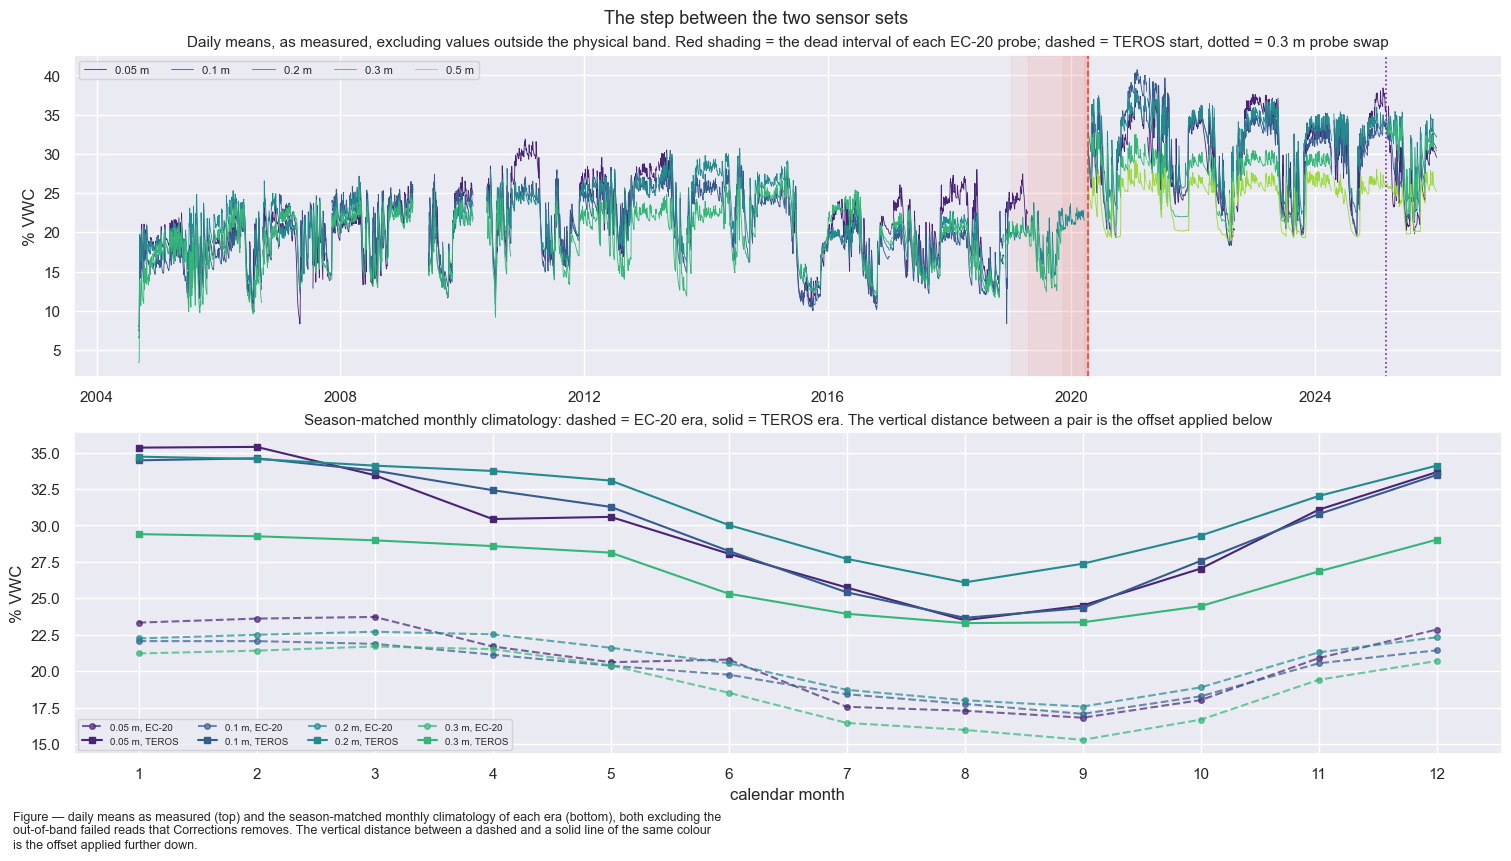

In [27]:
fig, axs = plt.subplots(nrows=2, figsize=(15, 8.5), dpi=100, layout='constrained')
fig.suptitle('The step between the two sensor sets', fontsize=13)

_colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(DEPTHS)))
for _c, d in zip(_colors, DEPTHS):
    # Band-masked, like STEPTAB and the climatology below. Plotted raw, the 0.1 m failed reads
    # near -29 % VWC stretch this axis across a range no soil moisture occupies and squash every
    # real series into the top third of the panel. They are removed for good in Corrections.
    _s = swc[field(d)]
    _daily = _s.where(_s.between(*SWC_PLAUSIBLE_PCT)).resample('1D').mean()
    axs[0].plot(_daily.index, _daily.values, lw=0.6, color=_c, label=f'{d} m')
_swap = pd.Timestamp(SENSOR_SWAP)
for d in MST_DEPTHS:
    axs[0].axvspan(mst[field(d)].last_valid_index(), diive_[field(d)].first_valid_index(),
                   color='#F44336', alpha=.06)
axs[0].axvline(diive_[field(DEPTHS[0])].first_valid_index(), color='#F44336', ls='--', lw=1.2)
axs[0].axvline(_swap, color='#7B1FA2', ls=':', lw=1.2)
axs[0].set_ylabel('% VWC')
axs[0].set_title('Daily means, as measured, excluding values outside the physical band. Red '
                 'shading = the dead interval of each EC-20 probe; dashed = TEROS start, '
                 'dotted = 0.3 m probe swap', fontsize=11)
axs[0].legend(fontsize=8, ncol=5)

for _c, d in zip(_colors, STEP_DEPTHS):
    e1, e2 = era_series(d, FLAG_EC20_MST), era_series(d, FLAG_TEROS_DIIVE)
    if e1.empty:
        continue
    axs[1].plot(range(1, 13), e1.groupby(e1.index.month).mean().reindex(range(1, 13)),
                marker='o', ms=4, ls='--', color=_c, alpha=.7, label=f'{d} m, EC-20')
    axs[1].plot(range(1, 13), e2.groupby(e2.index.month).mean().reindex(range(1, 13)),
                marker='s', ms=4, ls='-', color=_c, label=f'{d} m, TEROS')
axs[1].set_xticks(range(1, 13))
axs[1].set_xlabel('calendar month')
axs[1].set_ylabel('% VWC')
axs[1].set_title('Season-matched monthly climatology: dashed = EC-20 era, solid = TEROS era. '
                 'The vertical distance between a pair is the offset applied below', fontsize=11)
axs[1].legend(fontsize=7, ncol=4)
figcap(fig, 'daily means as measured (top) and the season-matched monthly climatology of each era '
            '(bottom), both excluding the out-of-band failed reads that Corrections removes. The '
            'vertical distance between a dashed and a solid line of the same colour is the offset '
            'applied further down.')

***

## ✴️ Corrections

Two defects are fixed here, and both come from one place: **the EC-20 era was screened once, by the
old MeteoScreeningTool, and never re-screened by diive.**

**1. Failed sensor reads stored as numbers.** The CR1000 firmware predates SDI-12 NaN support, so a
failed read produces not a gap but that sensor's calibration polynomial at zero response — a fixed
negative value per sensor. One mst depth carries a run of them at the very end of its life.
`notna()` does not mean "measured", and the missing-value flag cannot catch these; absolute limits
can. They are **removed, not clipped**: clipping to the physical minimum would turn a failed read
into a fabricated 0 % VWC, a worse lie than a gap because it looks like bone-dry soil.

A removed record becomes flag `0`, not a new "removed here" code, and that is deliberate — the
vocabulary says what *measured* a value, and a calibration polynomial at zero response never
measured anything.

**2. The FF-A / FF-B duplicate**, already handled at download and verified above.

Everything else leaves the measured values alone.

In [28]:
print("Removing values outside the physical band "
      f"{SWC_PLAUSIBLE_PCT[0]}..{SWC_PLAUSIBLE_PCT[1]} % VWC (removed, never clipped):\n")

_rows = []
for d in DEPTHS:
    f, fc = field(d), flagcol(d)
    bad = swc[f].notna() & ~swc[f].between(*SWC_PLAUSIBLE_PCT)
    n = int(bad.sum())
    if n:
        for _code in sorted(swc.loc[bad, fc].unique()):
            _m = bad & (swc[fc] == _code)
            _rows.append({'depth_m': float(d), 'flag': int(_code), 'era': ERA_NAMES[int(_code)],
                          'n_removed': int(_m.sum()), 'min': round(float(swc.loc[_m, f].min()), 3),
                          'max': round(float(swc.loc[_m, f].max()), 3),
                          'first': swc.index[_m][0], 'last': swc.index[_m][-1]})
        swc.loc[bad, f] = np.nan
        swc.loc[bad, fc] = FLAG_NOT_MEASURED
    print(f"  {f:<18} removed {n:>5,}")

REMOVED = pd.DataFrame(_rows)
if len(REMOVED):
    tabcap('every record removed for lying outside the physical band, by depth and era. All are '
           'failed SDI-12 reads frozen at a fixed negative constant in the mst era - never a '
           'measurement, so they become flag 0 rather than a "removed here" code.')
    display(REMOVED.set_index(['depth_m', 'flag']))
else:
    print("Nothing outside the band. Re-read this section before deleting it: the 0.1 m mst\n"
          "record is documented to carry ~690 negative records at the end of 2018.")

# The flag was demoted with the value, so the two still tell one story.
for d in DEPTHS:
    assert (swc[field(d)].notna() == swc[flagcol(d)].isin(MEASURED_FLAGS)).all(), \
        f"{field(d)}: flag and value disagree after the removal"
    assert swc[field(d)].dropna().between(*SWC_PLAUSIBLE_PCT).all(), \
        f"{field(d)}: a value survived outside the band"
print("\nFlag and value still agree at every depth, and nothing outside the band survives.")

Removing values outside the physical band 0.0..60.0 % VWC (removed, never clipped):

  SWC_FF1_0.05_1     removed     0
  SWC_FF1_0.1_1      removed   690
  SWC_FF1_0.2_1      removed     0
  SWC_FF1_0.3_1      removed     0
  SWC_FF1_0.5_1      removed     0
Table — every record removed for lying outside the physical band, by depth and era. All are failed
SDI-12 reads frozen at a fixed negative constant in the mst era - never a measurement, so they
become flag 0 rather than a "removed here" code.



,,era,n_removed,min,max,first,last
depth_m,flag,,,,,,
0.1,1,EC-20 / mst,690,-28.743,-4.99,2018-12-17 15:15:00,2018-12-31 23:45:00



Flag and value still agree at every depth, and nothing outside the band survives.


### What is *not* corrected, and why

The corrections notebooks `01`-`05` apply are each omitted by decision, not oversight. The 2012 rows
are the uncomfortable ones and are argued rather than waved away — starting with what the profile's
coverage actually did through those windows.

In [29]:
# The three 2012 site faults, on the corrected time axis of notebooks 01-05. Reported here, not
# applied: what the profile's coverage did through them is a fact this notebook can establish.
WINDOWS_2012 = [('2012-08-16', '2012-08-18', 'logger clock error, +15.5 h shift of one block'),
                ('2012-07-25', '2012-08-15', 'power supply failure'),
                ('2012-10-25', '2012-11-15', 'storm damage')]

for _a, _b, _why in WINDOWS_2012:
    _w = swc.loc[_a:_b]
    _cov = {d: f"{100 * _w[field(d)].notna().mean():.0f}%" for d in MST_DEPTHS}
    print(f"{_a} -> {_b}  ({_why})")
    print(f"   FF1 coverage: {_cov}")
print()
fieldbook_near('2012-08-17', days=3)

2012-08-16 -> 2012-08-18  (logger clock error, +15.5 h shift of one block)
   FF1 coverage: {'0.05': '100%', '0.1': '100%', '0.2': '100%', '0.3': '100%'}
2012-07-25 -> 2012-08-15  (power supply failure)
   FF1 coverage: {'0.05': '100%', '0.1': '100%', '0.2': '100%', '0.3': '100%'}
2012-10-25 -> 2012-11-15  (storm damage)
   FF1 coverage: {'0.05': '100%', '0.1': '100%', '0.2': '100%', '0.3': '100%'}

   2012-08-15 [FBA           ] 15.08.2012 (person 01) check for eddy data and the wireless connection dismounted the cable from tree F thermocoupple –> rearanged all the cables to the hut site. some of the poles were broken or loosen. installed the wireless device power disconnect at the forest floor station rearranged the cables from the soil water potetial sensors at the forest floor site and connect cables for the sdi12 serial connection via te
   2012-08-17 [FBA           ] 17.08.2012 (person 01, person 69, person 18, person 46) Ethernet Protect of phenocam replaced. Tried to adjust cam

| correction in `01`-`05` | applied here? | why |
|---|---|---|
| +15.5 h clock shift, Aug 2012 | **no — and this is an open question, not a clean no** | The shift is a *tower logger* fault. The FF1 profile is on the separate FF datalogger, and the fieldbook's own 2012 soil entry names the "FF Logger". But the entry that documents the clock error names only "the logger", and the profile's coverage through the window (above) neither confirms nor refutes a shared fault. Worse, the fault is **undetectable in this variable**: soil moisture has no diurnal cycle to align against, and there is no independent soil sensor anywhere. So sub-daily timestamps in Aug 2012 carry the same suspicion as the tower variables, and this is listed in the closing notes rather than silently resolved either way. |
| removal of the 2012 damaged periods | **no** | Same reasoning as notebook `08`: removing sound data because a *different* system failed would be superstition. Where the FF logger did share the fault, the coverage above already shows a gap; where it did not, the data are real. |
| nighttime zero-offset | **no** | Meaningless: soil moisture has no night. |
| unit harmonisation | **no** | Both data versions are tagged `%` with `offset = 0`, and the stored magnitudes agree with the tag at every depth. The differing `gain` tags are a property of each era's raw source, not of the stored values — checked above, and nothing is rescaled. |
| rescaling the pre-2020 era **in place** | **no** | It is shifted, but into the `_HOMOGENIZED` columns; the measured columns keep the measured values. |

: Each correction applied by notebooks `01`-`05`, and why it is or is not applied here. {#tbl-corrections}

::: {.callout-note title="The trap from notebook 03"}
Notebook `03` had a correction that wrote values into gaps and thereby relabelled 7,543 modelled
records as measured. The equivalent trap here would be an offset written onto a record that has no
measurement. It is closed structurally rather than by care: the offsets are added to
`SWC_FF1_<d>_1`, which is `NaN` in every gap, so `NaN + offset` stays `NaN` — and the export then
asserts that each `_HOMOGENIZED` column is non-null in exactly the records where its measured column
is. **The only correction in this notebook that touches the measured values removes them.**
:::

***

***

## 🧭 Is the EC-20 era internally homogeneous?

Everything above treats era 1 as one level to be lifted onto the TEROS era. This section tests
that, and the test was prompted by a reading of the overview figure: the record is visibly higher
before about 2015 than after, and the natural suspicion was the **January 2016 site renewal**,
which moved `TA`, `RH` and `PA` and which a June 2016 program change followed by breaking more than
half of `LW_IN`.

The renewal is not the cause, and the section says so with assertions rather than in prose, so the
question is not reopened every time someone notices the date. What is there instead is **one
discontinuity, on 25 June 2015**, dated to the half-hour and attributable to work on the
forest-floor logger's wiring — and, underneath it, a decade-long drift that cannot be corrected at
all. Nothing here changes an exported value.

::: {.callout-note title="Why this profile can be interrogated in a way the 2020 break cannot"}
The 2020 break is between two instruments that never overlapped, so its step can only be estimated
from climatology. Anything **inside** era 1 is different: the same four probes measured continuously
either side, so a step can be measured directly across a single half-hour with no weather in it at
all. That is the strongest form of evidence available anywhere in this notebook, and it is what
makes the 2016 result a genuine negative rather than an absence of looking.
:::


### The two covariates, and the programs

Two finished products of this folder are read as covariates — precipitation, to exclude rain, and
air temperature, to exclude snowmelt. Neither enters the product; they only decide which half-hours
the detector below is allowed to judge.


In [30]:
_prec_df = dv.load_parquet(filepath=PATH_PREC)
_ta_df = dv.load_parquet(filepath=PATH_TA)
# pd.read_parquet, not dv.load_parquet: the ensemble is daily and indexed on the MeteoSwiss 06-UTC
# precipitation day, so its index is not one of the three names TimestampSanitizer accepts and
# diive's loader refuses it. That refusal is correct - this is not a 30MIN middle-timestamp series
# and must not be treated as one.
PREC_REGIONAL = pd.read_parquet(PATH_PREC_REGIONAL)

# Pick the columns by shape rather than by name, and assert the choice is unique: a renamed column
# would otherwise be silently replaced by a neighbouring one that means something else.
_pcands = [c for c in _prec_df.columns if c.startswith('PREC') and c.endswith('_HOMOGENIZED')]
_tcands = [c for c in _ta_df.columns if c.startswith('TA') and 'HOMOGENIZED' in c]
assert len(_pcands) == 1, f"expected exactly one homogenised PREC column, found {_pcands}"
assert len(_tcands) == 1, f"expected exactly one homogenised TA column, found {_tcands}"

# The HOMOGENIZED columns of both, deliberately. Each crosses a break of its own - precipitation at
# 2018, air temperature at 2016 - and a detector covariate that steps at a date is a detector that
# can invent an event at that date.
PREC = _prec_df[_pcands[0]]
TA = _ta_df[_tcands[0]]
# require_data() is not used here: it reports a mean in % VWC, which neither of these is.
for _s, _n, _u in [(PREC, _pcands[0], 'mm'), (TA, _tcands[0], 'degC')]:
    if int(_s.notna().sum()) == 0:
        raise ValueError(f"{_n}: no data at all. Check the product file and the column name.")
    print(f"  {_n:<34} n={int(_s.notna().sum()):>7,}   {_s.first_valid_index()} -> "
          f"{_s.last_valid_index()}   mean {float(_s.mean()):6.2f} {_u}")

# Both products must be on the same index as this one, or every window below is off by something.
for _s, _n in [(PREC, _pcands[0]), (TA, _tcands[0])]:
    assert _s.index.name == full_index.name, (
        f"{_n}: index is named {_s.index.name!r}, not {full_index.name!r} - a product read here "
        f"must already be on TIMESTAMP_MID")
    _missing = full_index.difference(_s.index)
    assert _missing.empty, (f"{_n}: does not cover {len(_missing):,} of this product's timestamps "
                            f"({_missing[0]} ... {_missing[-1]})")
print("\nBoth covariates cover this product's whole index on the same timestamp convention.")

# The ensemble is daily and on the MeteoSwiss 06-UTC precipitation day, so it is NOT on this
# notebook's index and must not be reindexed onto it as if it were. It is used only through the
# padded day window inside `whole_profile_jumps`.
print(f"\nregional ensemble: {PREC_REGIONAL.shape[1]} stations, "
      f"{PREC_REGIONAL.index[0].date()} -> {PREC_REGIONAL.index[-1].date()}, "
      f"index '{PREC_REGIONAL.index.name}'")
assert PREC_REGIONAL.shape[1] >= 10, (
    f"the regional ensemble carries only {PREC_REGIONAL.shape[1]} station(s); the second rain "
    f"check is meant to be an ensemble, and a single station can itself be dry while rain falls")
_reg_cov = PREC_REGIONAL.loc[str(full_index[0].date()):str(full_index[-1].date())]
assert float(_reg_cov.notna().mean().mean()) > 0.98, (
    "the regional ensemble has gaps over this product's period, so it cannot serve as the rain "
    "check that covers the tower gauge's own outages")
print(f"ensemble coverage over this product's period: "
      f"{100 * float(_reg_cov.notna().mean().mean()):.2f} % of station-days")


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\08_METEO_PREC_GAPFILLED_2004-2025.parquet (0.042 seconds).

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\02_METEO_TA_GAPFILLED_2004-2025.parquet (0.014 seconds).

  PREC_TOT_T1_47_1_HOMOGENIZED       n=383,504   2004-01-01 00:15:00 -> 2025-12-31 23:45:00   mean   0.06 mm
  TA_T1_47_1_HOMOGENIZED_gfXG        n=385,728   2004-01-01 00:15:00 -> 2025-12-31 23:45:00   mean   9.59 degC



Both covariates cover this product's whole index on the same timestamp convention.

regional ensemble: 13 stations, 2004-01-01 -> 2025-12-31, index 'TIMESTAMP_MS_PRECIP_DAY'
ensemble coverage over this product's period: 99.87 % of station-days


### The January 2016 site renewal did not reach this profile

Three independent lines, and a structural reason that explains why they all come back negative.

The reason is that the renewal replaced the **tower** installation. This profile is on the
forest-floor datalogger, a different machine, and the tower program installed at the changeover
contains no soil-moisture instruction of any kind — its only SDI-12 measurement is the air
temperature and humidity probe at 47 m. This is the same argument notebook `08` makes for the rain
gauge, which was on neither logger.

The three data lines are then: the profile lost no records while the tower logger was being
replaced, where `05` and `06` both lose 20.6 days; no half-hour in the surrounding three weeks
carries a change larger than the record's own routine scatter; and the season-matched level does
not move across the date.


In [31]:
# The frame this whole section works on: era 1, one column per old depth, on the full index and
# AFTER the corrections above, so the failed-read constants are already gone.
ERA1 = pd.DataFrame({d: swc[field(d)].where(swc[flagcol(d)] == FLAG_EC20_MST) for d in MST_DEPTHS})
ERA2 = pd.DataFrame({d: swc[field(d)].where(swc[flagcol(d)].isin(
    [FLAG_TEROS_DIIVE, FLAG_TEROS_REPLACEMENT])) for d in DEPTHS})

# --- 1) what the tower program installed at the changeover actually measures ------------------
_tower_text = uncommented(Path(PROGRAM_TOWER_CR1000).read_text(encoding='latin-1'))
_tower_soil = re.findall(r'SWC|SoilM|EC-?20|Teros|Soil', _tower_text, flags=re.I)
_tower_sdi = re.findall(r'SDI12Recorder\s*\(\s*([A-Za-z_0-9]+)', _tower_text)
print(f"{Path(PROGRAM_TOWER_CR1000).name}")
print(f"  soil-moisture references in the live code: {len(_tower_soil)}")
print(f"  SDI-12 instructions:                       {_tower_sdi}")
assert len(_tower_soil) == 0, (
    "the tower CR1000 program contains a soil-moisture reference. The argument that the January "
    "2016 changeover cannot have touched this profile rests on it not doing so - re-read it.")

# --- 2) the outage that 05 and 06 both suffer is absent here ---------------------------------
_win = slice(pd.Timestamp(TOWER_ACQUISITION_CHANGE) - pd.Timedelta('2D'),
             pd.Timestamp(TOWER_ACQUISITION_CHANGE) + pd.Timedelta('4D'))
_cov = {d: int(ERA1.loc[_win, d].notna().sum()) for d in MST_DEPTHS}
_poss = len(ERA1.loc[_win])
print(f"\nrecords measured {TOWER_ACQUISITION_CHANGE} -2 d .. +4 d, of {_poss} possible: {_cov}")
assert all(v == _poss for v in _cov.values()), (
    f"this profile lost records while the tower logger was replaced ({_cov} of {_poss}). The "
    f"'no outage' line of the 2016 argument no longer holds")

# --- 3) no half-hour in the surrounding three weeks stands out from the record's own scatter --
_rows = []
for d in MST_DEPTHS:
    _all = ERA1[d].diff().abs()
    _here = ERA1[d].loc['2016-01-14':'2016-02-04'].diff().abs()
    _rows.append({'depth_m': float(d), 'max_abs_30min_change': float(_here.max()),
                  'when': _here.idxmax(), 'record_p99.9': float(_all.quantile(0.999)),
                  'record_max': float(_all.max())})
JAN2016 = pd.DataFrame(_rows).set_index('depth_m')
tabcap('the largest 30-minute change at each depth in the three weeks around the January 2016 '
       'tower changeover, against that depth\'s own distribution of 30-minute changes over the '
       'whole era. Every one is below the depth\'s routine p99.9, so nothing in the window is even '
       'unusual, let alone a step.')
display(JAN2016.round(3))
assert (JAN2016['max_abs_30min_change'] < JAN2016['record_p99.9']).all(), (
    "a half-hour around the January 2016 changeover changes by more than this depth's own p99.9 "
    "30-minute change. The 'no jump' line of the 2016 argument no longer holds")

print("\nThe January 2016 changeover replaced the tower installation. It left this profile with no\n"
      "outage, no jump, and - see the block table below - no level change. That is a negative\n"
      "result, and it is a result: without it the date gets re-proposed as the cause every time\n"
      "someone notices that three other tower variables step there.")


CH-LAE_iDL_T1_47_1.CR1
  soil-moisture references in the live code: 0
  SDI-12 instructions:                       ['TARH_T1_47_1']

records measured 2016-01-21 -2 d .. +4 d, of 288 possible: {'0.05': 288, '0.1': 288, '0.2': 288, '0.3': 288}
Table — the largest 30-minute change at each depth in the three weeks around the January 2016 tower
changeover, against that depth's own distribution of 30-minute changes over the whole era. Every one
is below the depth's routine p99.9, so nothing in the window is even unusual, let alone a step.



,max_abs_30min_change,when,record_p99.9,record_max
depth_m,,,,
0.05,0.655,2016-02-03 07:45:00,1.350,6.148
0.10,0.567,2016-02-03 08:15:00,1.590,20.266
0.20,0.961,2016-01-31 00:15:00,1.200,7.260
0.30,1.069,2016-01-31 00:45:00,1.273,5.430



The January 2016 changeover replaced the tower installation. It left this profile with no
outage, no jump, and - see the block table below - no level change. That is a negative
result, and it is a result: without it the date gets re-proposed as the cause every time
someone notices that three other tower variables step there.


### What the forest-floor programs say the EC-20 was

The two surviving forest-floor CR10X programs, of September 2004 and May 2006, convert every one of
the four soil-moisture channels the same way: a single-ended voltage excited at 2500 mV, multiplied
by `0.0695` with an offset of `-29.0`. That is the Decagon EC-20 factory calibration, and it fixes
two things this notebook needed and had been taking on trust.

First, it identifies the failed-read constant the *Corrections* section removes. A channel with no
response returns the conversion at zero volts, which is exactly `-29.0` % VWC — so those records
were never a measurement, and the section that removes rather than clips them is right to.

Second, and this is what the section below turns on, **the conversion is a multiplier and an
offset applied to a ratiometric voltage**. A resistance anywhere in that signal path acts as a
voltage divider and moves the level directly. That is the mechanism the fieldbook names three
weeks before the break.

The programs also carry a detail worth recording: each channel is followed by a test that sets a
negative reading to `0`. So in this era a **zero can be a failed read that the logger clipped**,
which absolute limits cannot catch and which is a different defect from the `-29.0` runs.

::: {.callout-warning title="What the programs do not cover"}
Both surviving programs are from the CR10X era, and by the time of the 2015 break the profile was
on a CR1000 (`CH-LAE_iDL_FF1_0_1`). **No forest-floor CR1000 program survives on disk.** So the
conversion is established at the beginning of the record and nowhere near the break, and the break
below cannot be read off a program at all — only out of the data and the maintenance record.
:::


In [32]:
_rows = []
for _names, _text in ff_programs().items():
    _c = ec20_constants(_text, _names)
    _mult, _off = next(iter(_c.values()))
    _rows.append({'program(s)': _names, 'soil_channels': len(_c),
                  'multiplier': _mult, 'offset': _off,
                  'clips_negative_to_zero': bool(re.search(r'Z Loc \[\s*SoilM_\d', _text))})
EC20_CONST = pd.DataFrame(_rows).set_index('program(s)')
tabcap('the conversion every forest-floor program applies to every soil-moisture channel. Both '
       'programs and all four channels agree, so no gain change is recorded anywhere in the era '
       'these two programs cover.')
display(EC20_CONST)

_pairs = {(r.multiplier, r.offset) for r in EC20_CONST.itertuples()}
assert len(_pairs) == 1, (
    f"the forest-floor programs disagree about the conversion: {_pairs}. Era 1 would then carry a "
    f"gain or offset change of its own, and the additive treatment below would be wrong")
EC20_MULT, EC20_OFFSET = next(iter(_pairs))
print(f"\none conversion across every program and channel: value = {EC20_MULT} * mV "
      f"{EC20_OFFSET:+}")

# The failed-read constant is not a number read off the data - it is this conversion at zero
# response, and it should match what Corrections actually removed.
print(f"the conversion at zero response is {EC20_OFFSET:+.1f} % VWC, which is what a channel that "
      f"stopped\nresponding returns instead of a gap.")
if len(REMOVED):
    _worst = float(REMOVED['min'].min())
    print(f"the most negative value Corrections removed was {_worst:.3f} % VWC")
    assert abs(_worst - EC20_OFFSET) < 1.0, (
        f"Corrections removed values down to {_worst:.2f} % VWC, but this conversion at zero "
        f"response is {EC20_OFFSET:+.1f}. The two should agree - if they do not, the removed "
        f"records are not the failed reads this explanation says they are")
    print("It agrees with the conversion, so those records are failed reads and not measurements.")

assert bool(EC20_CONST['clips_negative_to_zero'].all()), (
    "the programs no longer clip a negative soil-moisture reading to zero. The note about zeros "
    "possibly being clipped failed reads was derived from that clip - re-read it before repeating")


Table — the conversion every forest-floor program applies to every soil-moisture channel. Both
programs and all four channels agree, so no gain change is recorded anywhere in the era these two
programs cover.



,soil_channels,multiplier,offset,clips_negative_to_zero
program(s),,,,
LAEGEREN-FORESTFLOOR.20040903.CSI,4,0.0695,-29.0,True
"LAEGERN-FORESTFLOOR.20060502 (2).CSI, LAEGERN-FORESTFLOOR.20060502.CSI",4,0.0695,-29.0,True



one conversion across every program and channel: value = 0.0695 * mV -29.0
the conversion at zero response is -29.0 % VWC, which is what a channel that stopped
responding returns instead of a gap.
the most negative value Corrections removed was -28.743 % VWC
It agrees with the conversion, so those records are failed reads and not measurements.


### A detector for what a soil profile cannot do on its own

Water reaching 0.3 m passed 0.05 m hours earlier. So **every depth moving by the same sign inside a
single half-hour** is not the soil; it is the acquisition chain. That is the signature the detector
looks for, and it is measured only where the three hours either side are internally flat, so a
wet-up or a recession cannot register.

Getting this wrong once is instructive and the helper's docstring records it: an earlier version
fitted the pre-gap trend and extrapolated it across the gap, and its largest hits were all
**recession curvature** — fresh drainage after rain decelerates, so three days of it extrapolated
forward manufactures several % VWC of apparent step in a record that is continuous. Every one of
that version's top candidates dissolved on inspection of the half-hourly data.

Three covariates then remove everything that genuinely can move all depths together. **Rain at the
tower**, whose window has to be fully *measured* and not merely non-positive — the subsection after
next is about what that distinction cost. **Rain nearby**, from the thirteen-station regional daily
ensemble of `10_REFERENCE/`, which has no gap here where the tower gauge has several. And
**snowmelt**, which neither rain filter can see: the gauge is at 47 m and misses snow as it falls, so
without a temperature condition the detector returns a list of February and March dates that are all
meltwater and, tellingly, all positive.

The TEROS era is run through the same detector as a **negative control**. If the detector fired on
ordinary soil behaviour it would fire there too.


In [33]:
print("Whole-profile level jumps:\n")
JUMPS_ERA1 = whole_profile_jumps(ERA1, MST_DEPTHS, PREC, TA, PREC_REGIONAL, 'EC-20 era, whole era')
JUMPS_ERA2 = whole_profile_jumps(ERA2, DEPTHS, PREC, TA, PREC_REGIONAL,
                                 'TEROS era, whole era (negative control)')
JUMPS_FINE = whole_profile_jumps(ERA1.loc['2015-01-01':'2016-12-31'], MST_DEPTHS, PREC, TA,
                                 PREC_REGIONAL, 'EC-20 era, 2015-2016 only, sensitive pass',
                                 threshold=JUMP_THRESHOLD_FINE)

tabcap('every whole-profile level jump in the EC-20 era: the change at each depth, its mean, and '
       'how many depths the detector could judge. One event in fifteen and a half years, and the '
       'same detector finds none at all in the TEROS era.')
display(JUMPS_ERA1.round(2))

print(f"\nEC-20 era:  {len(JUMPS_ERA1)} event(s)")
print(f"TEROS era:  {len(JUMPS_ERA2)} event(s)   <- the negative control")
print(f"2015-2016 at {JUMP_THRESHOLD_FINE} % VWC: {len(JUMPS_FINE)} event(s)")

assert len(JUMPS_ERA1) == 1, (
    f"the detector finds {len(JUMPS_ERA1)} events in era 1, not 1. Everything this section "
    f"concludes rests on there being exactly one, so read the new one before proceeding:\n"
    f"{JUMPS_ERA1.round(2)}")

# The control has to come back empty, or the two events above are not evidence of anything.
assert JUMPS_ERA2.empty, (
    f"the detector fires {len(JUMPS_ERA2)} time(s) in the TEROS era. It is then detecting "
    f"something soil profiles do, and the EC-20 events are not attributable to the acquisition "
    f"chain:\n{JUMPS_ERA2.round(2)}")

# The sensitive pass over 2015-2016 exists to answer one question: is there anything at the
# 2015/2016 turn of the year, below the threshold the headline pass uses? There is not.
assert len(JUMPS_FINE) == 1, (
    f"the sensitive pass over 2015-2016 finds {len(JUMPS_FINE)} events, not 1. Something other "
    f"than the June 2015 break has appeared in those two years:\n{JUMPS_FINE.round(2)}")
assert pd.Timestamp(FF_WIRING_BREAK) in JUMPS_FINE.index, (
    f"the sensitive pass no longer finds {FF_WIRING_BREAK} - the break this section is about")
print(f"\nAt {JUMP_THRESHOLD_FINE} % VWC - a third of the headline threshold - the only whole-profile\n"
      f"jump anywhere in 2015 or 2016 is {FF_WIRING_BREAK}. Nothing sits at the turn of the year,\n"
      f"which is where a per-calendar-year processing artefact would sit, and nothing sits at the\n"
      f"January 2016 changeover.")


Whole-profile level jumps:



  EC-20 era, whole era                                   1 event(s) at or above 0.8 % VWC


  TEROS era, whole era (negative control)                no event at or above 0.8 % VWC
  EC-20 era, 2015-2016 only, sensitive pass              1 event(s) at or above 0.3 % VWC
Table — every whole-profile level jump in the EC-20 era: the change at each depth, its mean, and how
many depths the detector could judge. One event in fifteen and a half years, and the same detector
finds none at all in the TEROS era.



,0.05,0.1,0.2,0.3,mean_jump,n_depths
TIMESTAMP_MIDDLE,,,,,,
2015-06-25 08:45:00,-3.54,-4.73,-3.41,NaN,-3.89,3



EC-20 era:  1 event(s)
TEROS era:  0 event(s)   <- the negative control
2015-2016 at 0.3 % VWC: 1 event(s)

At 0.3 % VWC - a third of the headline threshold - the only whole-profile
jump anywhere in 2015 or 2016 is 2015-06-25 08:45. Nothing sits at the turn of the year,
which is where a per-calendar-year processing artefact would sit, and nothing sits at the
January 2016 changeover.


### The one break: 25 June 2015

Between `08:15` and `09:15` on 25 June 2015 every depth drops between 3.3 and 4.8 % VWC and stays
down. Three things make this a step and not weather:

- the three hours before it are flat to within hundredths of a per cent VWC, and so are the three
  hours after;
- no rain fell within a day either side, and the air had been above freezing for a fortnight, so
  there is neither infiltration nor meltwater;
- **0.3 m moves in the same hour as 0.05 m**, which infiltration cannot do.

The transition is not quite instantaneous, and the notebook does not pretend it is. At 0.3 m the
level starts moving one half-hour before the other three depths: the multiplexer reads the four
channels in sequence, and somebody was working on the wiring while it did. So an hour either side of
the detected timestamp is treated as the transition and excluded from both comparison windows. That
detail was found by a guard rather than by inspection — the first version of the cell below read the
earlier level up to `08:15`, caught the first half-hour of the disturbance at 0.3 m, and failed its
own flatness assertion. The tolerance was not widened.

The fieldbook, asked afterwards rather than used to find the date, has people on site that day
working on the forest-floor logger's wiring. Three weeks earlier it records the mechanism outright:
the plot's supply was replaced and its voltage raised, and the soil-moisture sensors' connectors
were found **loose**. For a ratiometric voltage measurement converted with a fixed multiplier and
offset, a resistance in the signal path is a voltage divider, and the level moves with it. That
also explains the smaller upward jumps in the record on 2 and 3 June, when the same connectors were
first disturbed.

::: {.callout-important title="This is measured, corroborated, and still not corrected here"}
The step is the best-determined quantity in this notebook — no weather in it, same probes either
side, dated to the half-hour. It is nevertheless **not applied**, because removing it alone would
imply that era 1 is otherwise one level, and the next subsection shows it is not. Correcting the
step while leaving a drift five times its size would produce a record that looks homogeneous and
is not, which is worse than one that admits it.
:::


In [34]:
BREAK = pd.Timestamp(FF_WIRING_BREAK)
_trans = pd.Timedelta(BREAK_TRANSITION)

# The step itself, between two SETTLED levels. Both windows stand clear of the transition: the
# earlier one ends an hour before the detected timestamp, because at 0.3 m the level starts moving
# a half-hour before the other three depths, and the later one starts beyond the short maintenance
# gap that follows. Neither window contains any part of the work itself.
_pre = ERA1.loc[BREAK - _trans - pd.Timedelta('2h30min'):BREAK - _trans]
_post = ERA1.loc[BREAK + pd.Timedelta('6h'):BREAK + pd.Timedelta('9h')]
_rows = []
for d in MST_DEPTHS:
    _rows.append({'depth_m': float(d), 'mean_3h_before': float(_pre[d].mean()),
                  'sd_3h_before': float(_pre[d].std()), 'mean_3h_after': float(_post[d].mean()),
                  'sd_3h_after': float(_post[d].std()),
                  'step': float(_post[d].mean() - _pre[d].mean())})
BREAK_STEP = pd.DataFrame(_rows).set_index('depth_m')
tabcap('the level three hours either side of the 25 June 2015 break. The scatter within each '
       'window is one to two orders of magnitude smaller than the step across it, which is what '
       'makes the step a step rather than a piece of a recession.')
display(BREAK_STEP.round(3))

BREAK_STEP_MEAN = float(BREAK_STEP['step'].mean())
print(f"\nmean step across the four depths: {BREAK_STEP_MEAN:+.2f} % VWC")
print(f"rain within a day either side:     "
      f"{float(PREC.loc[BREAK - pd.Timedelta('24h'):BREAK + pd.Timedelta('24h')].sum()):.2f} mm")
print(f"minimum air temperature, preceding {MELT_DAYS} d: "
      f"{float(TA.loc[BREAK - pd.Timedelta(days=MELT_DAYS):BREAK].min()):.1f} degC")

# Every depth must move the same way and by a comparable amount: a step in the shared signal path
# cannot move one depth and leave its neighbour.
assert (BREAK_STEP['step'] < 0).all(), "not every depth steps downward at the 2015 break"
assert BREAK_STEP['step'].max() - BREAK_STEP['step'].min() < abs(BREAK_STEP_MEAN), (
    "the four depths disagree about the size of the 2015 step by more than the step itself, which "
    "is not what a change in a shared signal path looks like")
# And the flatness claim the prose makes, asserted rather than described.
assert (BREAK_STEP[['sd_3h_before', 'sd_3h_after']].max().max() < JUMP_FLAT_SD), (
    f"a window either side of the break scatters by more than {JUMP_FLAT_SD} % VWC, so 'flat' is "
    f"the wrong word for it and the step is not cleanly separable from the soil's own movement")
# The markdown beside this cell, the closing notes and the homogenisation caveat all quote about
# -3.9 % VWC. A markdown cell cannot compute, so this is what stops those three going stale
# silently: it fails if the number they quote stops being the number this cell measures.
assert -4.5 < BREAK_STEP_MEAN < -3.3, (
    f"the step is now {BREAK_STEP_MEAN:+.2f} % VWC. Three markdown cells quote it as about -3.9 - "
    f"update them, rather than only widening this bound")

print("\nThe fieldbook, asked afterwards:")
fieldbook_near(BREAK.date(), days=1, maxchars=900)
print("\nAnd three weeks earlier, where the mechanism is named:")
fieldbook_near('2015-06-02', '2015-06-03', days=0, maxchars=900)


Table — the level three hours either side of the 25 June 2015 break. The scatter within each window
is one to two orders of magnitude smaller than the step across it, which is what makes the step a
step rather than a piece of a recession.



,mean_3h_before,sd_3h_before,mean_3h_after,sd_3h_after,step
depth_m,,,,,
0.05,24.044,0.020,20.160,0.088,-3.885
0.10,24.158,0.073,19.383,0.021,-4.775
0.20,24.689,0.019,21.087,0.032,-3.602
0.30,22.679,0.005,19.506,0.037,-3.173



mean step across the four depths: -3.86 % VWC
rain within a day either side:     0.00 mm
minimum air temperature, preceding 5 d: 9.0 degC

The fieldbook, asked afterwards:
   2015-06-25 [FBA           ] 25.06.2015 (person 14,person 01) De-Installed old powerbox (former University of Bern) on top platform and Installed new one Old defective Sonic (head) cable dismounted Cables to Unispec now installed in cable canal and out of the way since the last few work at the sapflow sensors we realised that the sensors have been connected in the wrong way at the logger. What was north was actually south and what was south was actually north. We tried to correct this mistake through the the next few tasks: Exchanged all remaining SapFlow sensors connection at the FF CR1000 logger. Exchanging the north and south sensors. This means on the same variablename is actually another but correct sensor. eg. on Sap2591_N150 was before the sensor from the south. Since now the north sensor is connected to th

#### An independent witness on the same station

Everything above establishes that the soil-moisture record steps, and the fieldbook says what was
being worked on. Neither settles the one question a user of this product should ask next: was this a
**station-wide** event — the supply, the enclosure, the logger's own reference — or was it confined
to the soil-moisture chain? The two have different consequences. A station-wide change would mean
every forest-floor variable of that era carries a break at this date; a change in the soil-moisture
wiring means only this one does.

**Soil temperature answers it.** It is measured at this same station, through the same enclosure and
the same power supply, by the five-sensor Campbell 107 stick of the early forest-floor profile. If
the supply or the logger reference had moved, it would have moved too.

The comparison needs one piece of care, and it is the same lesson the jump detector above already
carries. A departure from a trend fitted beforehand is **not** zero on an ordinary morning: soil
temperature at 0.05 m is warming through breakfast-time in June and the curve accelerates, so a
straight line under-predicts what follows by about +0.7 K on a perfectly typical day. Judged on size
alone it would look like a step. So the statistic is placed in the distribution of the *same*
statistic at the *same* clock time on every May-to-July morning of the record, and the identical
machinery is run on this notebook's own soil moisture, so the two are not held to different
standards.

::: {.callout-tip title="The result, and what it licenses"}
At the same half-hour, on the same station: **soil temperature sits in the middle of its own
distribution at every depth, and soil moisture sits in the extreme tail of its.** The event was
confined to the soil-moisture chain, which is exactly what the maintenance record implies when it
reports these probes' connectors loose three weeks earlier.

That is what turns the attribution above from a plausible reading of a fieldbook entry into a
measured result. It also says the forest-floor **soil temperature** product needs no correction at
this date, which is asserted from the other side in `10`.
:::


In [35]:
_ts_raw = dv.load_parquet(filepath=PATH_TS_RAW)
_missing = [c for c in TS_EARLY_CHANNELS if c not in _ts_raw.columns]
assert not _missing, (
    f"the screened soil-temperature download does not carry {_missing}. Without the early "
    f"forest-floor channels there is no witness on this station and the attribution above falls "
    f"back to the fieldbook alone")
assert _ts_raw.index.name == full_index.name, (
    f"the soil-temperature download is indexed on {_ts_raw.index.name!r}, not "
    f"{full_index.name!r} - the two records would not line up at the half-hour")
print(f"soil temperature, as screened: {_ts_raw.shape[0]:,} records, "
      f"{_ts_raw.index[0]:%Y-%m-%d} -> {_ts_raw.index[-1]:%Y-%m-%d}")
print(f"early forest-floor channels used: {TS_EARLY_CHANNELS}\n")

print(f"Departure at {FF_WIRING_BREAK}, against the same statistic on every May-July morning:\n")
print("  soil TEMPERATURE (K), same station")
_ts_dep = {c: departure_percentile(_ts_raw[c], BREAK, c) for c in TS_EARLY_CHANNELS}
print("\n  soil MOISTURE (% VWC), this notebook, identical machinery")
_swc_dep = {}
for d in MST_DEPTHS:
    _swc_dep[field(d)] = departure_percentile(ERA1[d], BREAK, field(d))

WITNESS = pd.DataFrame(
    [{'variable': 'TS', 'series': k, 'unit': 'K', 'departure': v[0], 'percentile': v[1],
      'n_null': v[2]} for k, v in _ts_dep.items()]
    + [{'variable': 'SWC', 'series': k, 'unit': '% VWC', 'departure': v[0], 'percentile': v[1],
        'n_null': v[2]} for k, v in _swc_dep.items()]).set_index(['variable', 'series'])
tabcap('the departure at the June 2015 rewiring, and where it sits among comparable mornings, for '
       'both variables of this station. Soil temperature is ordinary for the hour at every depth; '
       'soil moisture is in the tail at every depth. The soil-temperature departures are not small '
       '- they are simply what that hour does.')
display(WITNESS.round(3))

_lo, _hi = DEPARTURE_ORDINARY_PCT
_ts_pct = [v[1] for v in _ts_dep.values()]
_swc_pct = [v[1] for v in _swc_dep.values()]
print(f"\nsoil temperature percentiles: {[round(p, 1) for p in _ts_pct]}  <- the middle")
print(f"soil moisture percentiles:    {[round(p, 2) for p in _swc_pct]}  <- the tail")

assert all(_lo < p < _hi for p in _ts_pct), (
    f"soil temperature is no longer ordinary for the hour at the break (percentiles "
    f"{[round(p, 1) for p in _ts_pct]}). If it moved too, the event was station-wide and the "
    f"attribution to the soil-moisture wiring above must be rewritten, not kept")
assert all(p < 1.0 for p in _swc_pct), (
    f"soil moisture is no longer in the tail at the break (percentiles "
    f"{[round(p, 2) for p in _swc_pct]}); the contrast this subsection rests on has gone")
print("\nSame station, same half-hour, same statistic: one variable moved and the other did not.\n"
      "The break is in the soil-moisture chain, and the forest-floor soil-temperature product\n"
      "needs no correction at this date.")


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\TS_FF1_SCREENED_30MIN_MST_2004-2021.parquet (0.024 seconds).

soil temperature, as screened: 303,600 records, 2004-09-07 -> 2021-12-31
early forest-floor channels used: ['TS_PRF_FF1_0.05_1', 'TS_PRF_FF1_0.1_1', 'TS_PRF_FF1_0.15_1']

Departure at 2015-06-25 08:45, against the same statistic on every May-July morning:

  soil TEMPERATURE (K), same station


  TS_PRF_FF1_0.05_1            +0.784   null sd  0.514  min  -2.191  max  +4.144   percentile  57.1  (n=1,278)


  TS_PRF_FF1_0.1_1             +0.212   null sd  0.166  min  -0.590  max  +2.091   percentile  50.2  (n=1,278)


  TS_PRF_FF1_0.15_1            +0.073   null sd  0.073  min  -0.204  max  +1.655   percentile  57.0  (n=1,273)

  soil MOISTURE (% VWC), this notebook, identical machinery


...

  SWC_FF1_0.1_1                -4.480   null sd  0.508  min  -5.404  max  +6.647   percentile   0.2  (n=1,217)


  SWC_FF1_0.2_1                -3.346   null sd  0.377  min  -3.821  max  +5.704   percentile   0.1  (n=1,305)


  SWC_FF1_0.3_1                -2.996   null sd  0.385  min  -3.909  max  +4.968   percentile   0.2  (n=1,200)
Table — the departure at the June 2015 rewiring, and where it sits among comparable mornings, for
both variables of this station. Soil temperature is ordinary for the hour at every depth; soil
moisture is in the tail at every depth. The soil-temperature departures are not small - they are
simply what that hour does.



unit  departure  percentile  n_null
variable series                                                 
TS       TS_PRF_FF1_0.05_1      K      0.784      57.121    1278
         TS_PRF_FF1_0.1_1       K      0.212      50.235    1278
         TS_PRF_FF1_0.15_1      K      0.073      56.952    1273
SWC      SWC_FF1_0.05_1     % VWC     -3.475       0.201     993
         SWC_FF1_0.1_1      % VWC     -4.480       0.164    1217
         SWC_FF1_0.2_1      % VWC     -3.346       0.077    1305
         SWC_FF1_0.3_1      % VWC     -2.996       0.250    1200


soil temperature percentiles: [57.1, 50.2, 57.0]  <- the middle
soil moisture percentiles:    [0.2, 0.16, 0.08, 0.25]  <- the tail

Same station, same half-hour, same statistic: one variable moved and the other did not.
The break is in the soil-moisture chain, and the forest-floor soil-temperature product
needs no correction at this date.


### Why the rain filter has to require a *measured* dry window

The first version of the detector had two more events, and one of them is worth keeping in the
notebook because it shows how a rain filter fails.

At `20:45` on 29 May 2008 every depth rises 3 to 6 % VWC in one half-hour — the same simultaneity
that makes the 2015 event unattributable to infiltration. The tower gauge recorded `0` mm around it.
It was not dry. **The gauge was in its 24.6-day May–June 2008 outage**, the longest in the
precipitation product, so those records are `NaN`; the filter had been written with `fillna(0)`, and
a missing half-hour silently became a dry one.

The regional ensemble settles it. All thirteen MeteoSwiss stations within 21 km record rain on that
day, between 1 and 16 mm, and rain again the day after. The 2008 event is a wetting response, and
the apparent recovery over the following days is an ordinary recession.

Two changes followed, both in the helper. The tower rain window must be **fully measured**, so a
gap disqualifies a candidate instead of admitting it; and the **ensemble is consulted as a second,
independent check**, because it has no gap at this site where the tower gauge has several. The cell
below reproduces the old behaviour deliberately, via `naive_dry=True`, so the difference is on the
record rather than described.

::: {.callout-note title="What this costs, and what it buys"}
The stricter filter cannot judge any half-hour whose rain window the gauge did not measure, so it is
blind over parts of 2004-2014. It therefore does **not** establish that era 1 has only one
discontinuity; it establishes that only one is demonstrable. That is the weaker claim, and it is the
one the section makes.
:::


In [36]:
# The old behaviour, reproduced on purpose. `naive_dry=True` exists only for this comparison.
NAIVE = whole_profile_jumps(ERA1, MST_DEPTHS, PREC, TA, PREC_REGIONAL,
                            'EC-20 era, the FIRST version of the rain filter', naive_dry=True)
tabcap('what the first version of the rain filter admitted. Everything here that is not in the '
       'table above was admitted because the tower gauge did not measure the rain, not because no '
       'rain fell.')
display(NAIVE.round(2))

_spurious = NAIVE.index.difference(JUMPS_ERA1.index)
print(f"\nadmitted by the naive filter and rejected by the current one: "
      f"{[str(t) for t in _spurious]}")
assert len(_spurious) >= 1, (
    "the naive filter no longer admits anything the strict one rejects, so this section is "
    "demonstrating nothing. Either the products changed or the filters have converged - check "
    "which before deleting the section")

# Why each rejected candidate was rejected, from the two rain records side by side.
_rows = []
for _t in _spurious:
    _w = PREC.loc[_t - pd.Timedelta(hours=JUMP_DRY_HOURS):_t + pd.Timedelta(hours=JUMP_DRY_HOURS)]
    _rw = PREC_REGIONAL.loc[_t.normalize() - pd.Timedelta('1D'):_t.normalize() + pd.Timedelta('1D')]
    _rows.append({'candidate': _t, 'tower_records_in_window': int(len(_w)),
                  'tower_measured': int(_w.notna().sum()), 'tower_mm': float(_w.sum()),
                  'ensemble_stations_wet': int((_rw.max(axis=0) > 0.5).sum()),
                  'ensemble_max_mm': float(_rw.max(axis=None)),
                  'ensemble_median_mm': float(_rw.max(axis=0).median())})
WHY = pd.DataFrame(_rows).set_index('candidate')
tabcap('each rejected candidate, with what the tower gauge measured around it and what the '
       'thirteen regional stations recorded. The tower column shows the gauge was not measuring; '
       'the ensemble columns show it was raining.')
display(WHY.round(2))

assert (WHY['tower_measured'] < WHY['tower_records_in_window']).all(), (
    "a candidate was rejected although the tower gauge measured its whole rain window. Then the "
    "gap-versus-dry explanation this section gives is not the reason it was rejected - find the "
    "real one before repeating this")
assert (WHY['ensemble_stations_wet'] >= 5).all(), (
    "a rejected candidate has fewer than five wet regional stations, so calling it a wetting "
    "response is not supported by the ensemble")

_t8 = pd.Timestamp(FALSE_POSITIVE_2008)
print(f"\nThe worked case, {_t8:%d %B %Y}: the thirteen stations, in mm on the MeteoSwiss "
      f"precipitation day:")
display(PREC_REGIONAL.loc[_t8.normalize() - pd.Timedelta('1D'):
                          _t8.normalize() + pd.Timedelta('1D')].round(1))
print("\nThe gauge read nothing because it was not measuring. Every station nearby was wet. A rain\n"
      "filter that fills a gap with zero does not exclude rain - it excludes the record of it.")


  EC-20 era, the FIRST version of the rain filter        2 event(s) at or above 0.8 % VWC
Table — what the first version of the rain filter admitted. Everything here that is not in the table
above was admitted because the tower gauge did not measure the rain, not because no rain fell.



,0.05,0.1,0.2,0.3,mean_jump,n_depths
TIMESTAMP_MIDDLE,,,,,,
2008-05-29 20:45:00,3.05,6.07,5.12,6.11,5.09,4
2015-06-25 08:45:00,-3.54,-4.73,-3.41,NaN,-3.89,3



admitted by the naive filter and rejected by the current one: ['2008-05-29 20:45:00']
Table — each rejected candidate, with what the tower gauge measured around it and what the thirteen
regional stations recorded. The tower column shows the gauge was not measuring; the ensemble columns
show it was raining.



,tower_records_in_window,tower_measured,tower_mm,ensemble_stations_wet,ensemble_max_mm,ensemble_median_mm
candidate,,,,,,
2008-05-29 20:45:00,97,0,0.0,13,26.5,12.0



The worked case, 29 May 2008: the thirteen stations, in mm on the MeteoSwiss precipitation day:


,PREC_OED_MS_DAILY,PREC_DIT_MS_DAILY,PREC_KAI_MS_DAILY,PREC_PSI_MS_DAILY,PREC_REH_MS_DAILY,PREC_KLO_MS_DAILY,PREC_BUE_MS_DAILY,PREC_BEZ_MS_DAILY,PREC_WAG_MS_DAILY,PREC_OPF_MS_DAILY,PREC_UBB_MS_DAILY,PREC_SMA_MS_DAILY,PREC_LEI_MS_DAILY
TIMESTAMP_MS_PRECIP_DAY,,,,,,,,,,,,,
2008-05-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-05-29,12.8,16.0,3.0,4.8,11.9,1.1,0.0,8.7,14.3,1.5,6.1,8.3,7.7
2008-05-30,4.5,8.6,26.5,2.8,13.0,17.4,12.0,2.3,1.6,8.6,3.7,5.4,4.1



The gauge read nothing because it was not measuring. Every station nearby was wet. A rain
filter that fills a gap with zero does not exclude rain - it excludes the record of it.


### What cannot be corrected: the drift under the break

The step is not the whole story, and this is the part that decides what the notebook does about it.
Over the decade before the break the record drifts **upward** at every depth, at both ends of its
own range. Both ends matter: the wettest and the driest conditions of a year are set by the soil —
field capacity and residual water content — not by that year's weather, so a record whose driest
half-hour rises steadily by several % VWC per decade is not tracking the climate.

The table below puts the drift at roughly +0.5 to +1.2 % VWC per year, five to nine % VWC in total,
against annual precipitation that trends slightly **downward** over the same years. It is
consistent with what the GIN inventory says about the hardware: three of the four EC-20s are flagged
`DEFECTIVE`, and a probe that fails in 2019 was not sound in 2013.

**A drift has no date, so it has no boundary at which a correction could be applied.** Nothing
measured this plot's soil, so there is nothing to fit it against either, and correcting an
unattributed drift towards no reference is precisely what `01` declines to do for the tower
pyranometer and `03` for the PAR sensor. The season-matched difference across the break is
correspondingly larger than the step measured at the discontinuity — the difference is the drift,
plus a drier comparison period — and quoting the larger number as the step would be attributing the
drift to the wiring.


In [37]:
_rows = []
for d in MST_DEPTHS:
    _s = ERA1[d].loc[:BREAK].dropna()
    _g = _s.groupby(_s.index.year)
    # A year needs most of itself to define a percentile of that year's range: 8,000 records is
    # about 167 days. Without the threshold a year holding one wet month reports that month's
    # driest half-hour as its dry end, and the trend becomes a trend in coverage.
    _lo = _g.quantile(0.02).where(_g.size() > 8000).dropna()
    _hi = _g.quantile(0.98).where(_g.size() > 8000).dropna()
    _rows.append({'depth_m': float(d), 'years': len(_lo),
                  'dry_end_first': float(_lo.iloc[0]), 'dry_end_last': float(_lo.iloc[-1]),
                  'dry_end_pct_per_yr': float(np.polyfit(_lo.index, _lo.values, 1)[0]),
                  'wet_end_first': float(_hi.iloc[0]), 'wet_end_last': float(_hi.iloc[-1]),
                  'wet_end_pct_per_yr': float(np.polyfit(_hi.index, _hi.values, 1)[0])})
DRIFT = pd.DataFrame(_rows).set_index('depth_m')
tabcap('the annual 2nd and 98th percentile of each depth over the decade before the break, and '
       'their trends. Both ends rise at every depth, which is a change in what the probe reports '
       'rather than in what the weather did: the driest and wettest states of a year are soil '
       'properties.')
display(DRIFT.round(2))

_pa = PREC.loc['2005':'2014'].resample('YS').sum()
_ptrend = float(np.polyfit(_pa.index.year, _pa.values, 1)[0])
print(f"\nannual precipitation 2005-2014: {_pa.min():.0f} to {_pa.max():.0f} mm, "
      f"trend {_ptrend:+.1f} mm/yr")
print(f"drift of the dry end: {DRIFT['dry_end_pct_per_yr'].min():+.2f} to "
      f"{DRIFT['dry_end_pct_per_yr'].max():+.2f} % VWC/yr")
print(f"drift of the wet end: {DRIFT['wet_end_pct_per_yr'].min():+.2f} to "
      f"{DRIFT['wet_end_pct_per_yr'].max():+.2f} % VWC/yr")

# The two claims this subsection rests on.
assert (DRIFT['dry_end_pct_per_yr'] > 0).all() and (DRIFT['wet_end_pct_per_yr'] > 0).all(), (
    "the pre-break drift is no longer upward at both ends of the range at every depth - re-read "
    "this subsection before repeating its argument")
assert _ptrend <= 0, (
    f"annual precipitation trends {_ptrend:+.1f} mm/yr over the drift decade, i.e. upward. The "
    f"argument that the drift cannot be the weather needs the wetting trend it does not have")
# Same reason as the step's bound: the markdown quotes +0.5 to +1.2 % VWC per year.
_dmin = float(DRIFT[['dry_end_pct_per_yr', 'wet_end_pct_per_yr']].min().min())
_dmax = float(DRIFT[['dry_end_pct_per_yr', 'wet_end_pct_per_yr']].max().max())
assert 0.3 < _dmin and _dmax < 1.5, (
    f"the drift now spans {_dmin:+.2f} to {_dmax:+.2f} % VWC/yr. The markdown and the closing "
    f"notes quote +0.5 to +1.2 - update them rather than only widening this bound")

# And the point of the whole subsection: the drift is the larger of the two effects, so a step
# correction on its own would not make era 1 homogeneous.
_drift_total = float((DRIFT['dry_end_last'] - DRIFT['dry_end_first']).mean())
print(f"\ntotal drift of the dry end over the decade: {_drift_total:+.1f} % VWC, against a step of "
      f"{BREAK_STEP_MEAN:+.2f} % VWC.")
assert abs(_drift_total) > abs(BREAK_STEP_MEAN), (
    "the drift is no longer larger than the step. The reason given for not applying the step - "
    "that it would leave a larger uncorrected drift behind - would then no longer hold")


Table — the annual 2nd and 98th percentile of each depth over the decade before the break, and their
trends. Both ends rise at every depth, which is a change in what the probe reports rather than in
what the weather did: the driest and wettest states of a year are soil properties.



,years,dry_end_first,dry_end_last,dry_end_pct_per_yr,wet_end_first,wet_end_last,wet_end_pct_per_yr
depth_m,,,,,,,
0.05,9,12.21,20.75,1.08,21.84,30.35,1.23
0.10,11,11.98,18.26,0.61,19.22,26.81,0.72
0.20,11,15.34,21.12,0.68,23.35,28.79,0.64
0.30,11,10.33,20.30,0.68,20.73,27.96,0.45



annual precipitation 2005-2014: 744 to 1222 mm, trend -4.9 mm/yr
drift of the dry end: +0.61 to +1.08 % VWC/yr
drift of the wet end: +0.45 to +1.23 % VWC/yr

total drift of the dry end over the decade: +7.6 % VWC, against a step of -3.86 % VWC.


### Where the level change sits, and that it then holds

Twelve-month season-matched blocks are the clearest summary, and they are what settles the date.
Each block averages the calendar-month means it covers, so a block is not moved by which months it
happens to sample; the blocks are cut on 25 June so that the break falls exactly on a boundary.

The level drops between the block ending in June 2015 and the one beginning there, and then holds
across the following years despite annual rainfall between about 790 and 1010 mm. The block
containing the 2015 drought sits lowest, and recovers — which separates the two effects: the drought
is a transient on top of a step that is not.

The comparison is made on a **rectangle**, the same depths in every block compared, and the cell
asserts the rectangle has no hole. That is not bookkeeping: 0.05 m is dead across the 2013–2015
blocks and returns in June 2015, so a mean over whichever depths each block happens to carry would
change its composition at exactly the boundary under test, and would report a depth *arriving* as a
level change. 0.1 m then ends inside the final block, which is why the rectangle stops at June 2018.
The full table is shown anyway, because the excluded cells are informative in themselves.


In [38]:
_edges = [pd.Timestamp(f'{_y}-06-25') for _y in range(2011, 2020)]
_rows = []
for _a, _b in zip(_edges[:-1], _edges[1:]):
    _r = {'block': f'{_a:%Y-%m}..{_b:%Y-%m}'}
    for d in MST_DEPTHS:
        _x = ERA1[d].loc[_a:_b - pd.Timedelta('30min')].dropna()
        _g = _x.groupby(_x.index.month)
        # Season-matched: the block's level is the mean of its calendar-month means, so a block is
        # not moved by which months it happens to sample more heavily. A month needs 400 records
        # (about eight days) to count, and a block needs nine such months to report a level.
        _mo = _g.mean().where(_g.size() >= 400)
        _r[d] = float(_mo.mean()) if int(_mo.notna().sum()) >= 9 else np.nan
        _r[f'{d}_months'] = int(_mo.notna().sum())
    _r['prec_mm'] = float(PREC.loc[_a:_b - pd.Timedelta('30min')].sum())
    _rows.append(_r)
BLOCKS = pd.DataFrame(_rows).set_index('block')
tabcap('season-matched level of each twelve-month block either side of 25 June 2015, with the '
       'precipitation of the block. A depth is left blank where fewer than nine calendar months '
       'carry enough records to average, which is why 0.05 m is absent for its two dead years.')
display(BLOCKS[[*MST_DEPTHS, 'prec_mm']].round(2))

# The profile mean is taken on a RECTANGLE - the same depths in every block compared - and not over
# whatever each block happens to carry. This matters more than it looks: 0.05 m is dead across the
# 2013-2015 blocks and returns in June 2015, so a mean over the available depths would change its
# composition at exactly the boundary under test and report the arrival of a depth as a level
# change. 0.1 m then ends inside the final block. The rectangle is therefore the three deeper
# depths over the blocks up to June 2018: four before the break and three after.
BLOCK_DEPTHS = ['0.1', '0.2', '0.3']
BLOCK_SUBSET = [i for i in BLOCKS.index if i < '2018-06']
print(f"\nprofile mean on the rectangle {BLOCK_DEPTHS} m x {len(BLOCK_SUBSET)} blocks "
      f"({BLOCK_SUBSET[0]} .. {BLOCK_SUBSET[-1]})")
print(f"excluded: {[d for d in MST_DEPTHS if d not in BLOCK_DEPTHS]} m, and the blocks from "
      f"{[i for i in BLOCKS.index if i not in BLOCK_SUBSET]}")
assert BLOCKS.loc[BLOCK_SUBSET, BLOCK_DEPTHS].notna().all().all(), (
    f"the rectangle has a hole in it:\n"
    f"{BLOCKS.loc[BLOCK_SUBSET, BLOCK_DEPTHS].isna()}\nA mean over a changing set of depths "
    f"reports a depth arriving or leaving as a level change, so fix the rectangle rather than "
    f"letting the mean skip the gap")
_n_pre = sum(1 for i in BLOCK_SUBSET if i < '2015-06')
assert _n_pre >= 2 and len(BLOCK_SUBSET) - _n_pre >= 2, (
    f"the rectangle has {_n_pre} block(s) before the break and {len(BLOCK_SUBSET) - _n_pre} after; "
    f"two either side is the minimum for the comparison to mean anything")

# Where the change sits: the largest block-to-block move must be the one across the break.
_diff = BLOCKS.loc[BLOCK_SUBSET, BLOCK_DEPTHS].mean(axis=1).diff()
_biggest = _diff.abs().idxmax()
print(f"\nblock-to-block change of the profile mean:")
print(_diff.round(2).to_string())
print(f"\nlargest move: {_biggest} ({_diff[_biggest]:+.2f} % VWC)")
assert _biggest.startswith('2015-06'), (
    f"the largest block-to-block level change is now {_biggest}, not the block beginning at the "
    f"June 2015 break. The date this section attributes the change to no longer follows from the "
    f"blocks - re-derive it before repeating it")

# ... and that the level then holds. The post-break blocks must scatter far less than the move.
_post_blocks = BLOCKS.loc[[i for i in BLOCK_SUBSET if i >= '2015-06'], BLOCK_DEPTHS].mean(axis=1)
_spread = float(_post_blocks.max() - _post_blocks.min())
print(f"spread of the {len(_post_blocks)} post-break blocks: {_spread:.2f} % VWC, against a move "
      f"of {abs(_diff[_biggest]):.2f} % VWC")
assert _spread < abs(_diff[_biggest]), (
    "the blocks after the break scatter by more than the break moved the record, so the claim "
    "that the level holds after 2015 is not supported")


Table — season-matched level of each twelve-month block either side of 25 June 2015, with the
precipitation of the block. A depth is left blank where fewer than nine calendar months carry enough
records to average, which is why 0.05 m is absent for its two dead years.



,0.05,0.1,0.2,0.3,prec_mm
block,,,,,
2011-06..2012-06,22.72,22.26,22.49,19.73,907.6
2012-06..2013-06,25.70,24.69,24.74,20.80,1216.5
2013-06..2014-06,NaN,22.99,25.14,20.20,907.4
2014-06..2015-06,NaN,23.45,25.28,22.96,1082.4
2015-06..2016-06,17.53,16.36,17.32,18.79,1011.7
2016-06..2017-06,19.06,17.17,18.09,18.48,788.8
2017-06..2018-06,21.45,17.78,18.82,17.70,945.3
2018-06..2019-06,19.29,NaN,17.64,17.20,895.2



profile mean on the rectangle ['0.1', '0.2', '0.3'] m x 7 blocks (2011-06..2012-06 .. 2017-06..2018-06)
excluded: ['0.05'] m, and the blocks from ['2018-06..2019-06']

block-to-block change of the profile mean:
block
2011-06..2012-06     NaN
2012-06..2013-06    1.92
2013-06..2014-06   -0.64
2014-06..2015-06    1.12
2015-06..2016-06   -6.41
2016-06..2017-06    0.43
2017-06..2018-06    0.18

largest move: 2015-06..2016-06 (-6.41 % VWC)
spread of the 3 post-break blocks: 0.61 % VWC, against a move of 6.41 % VWC


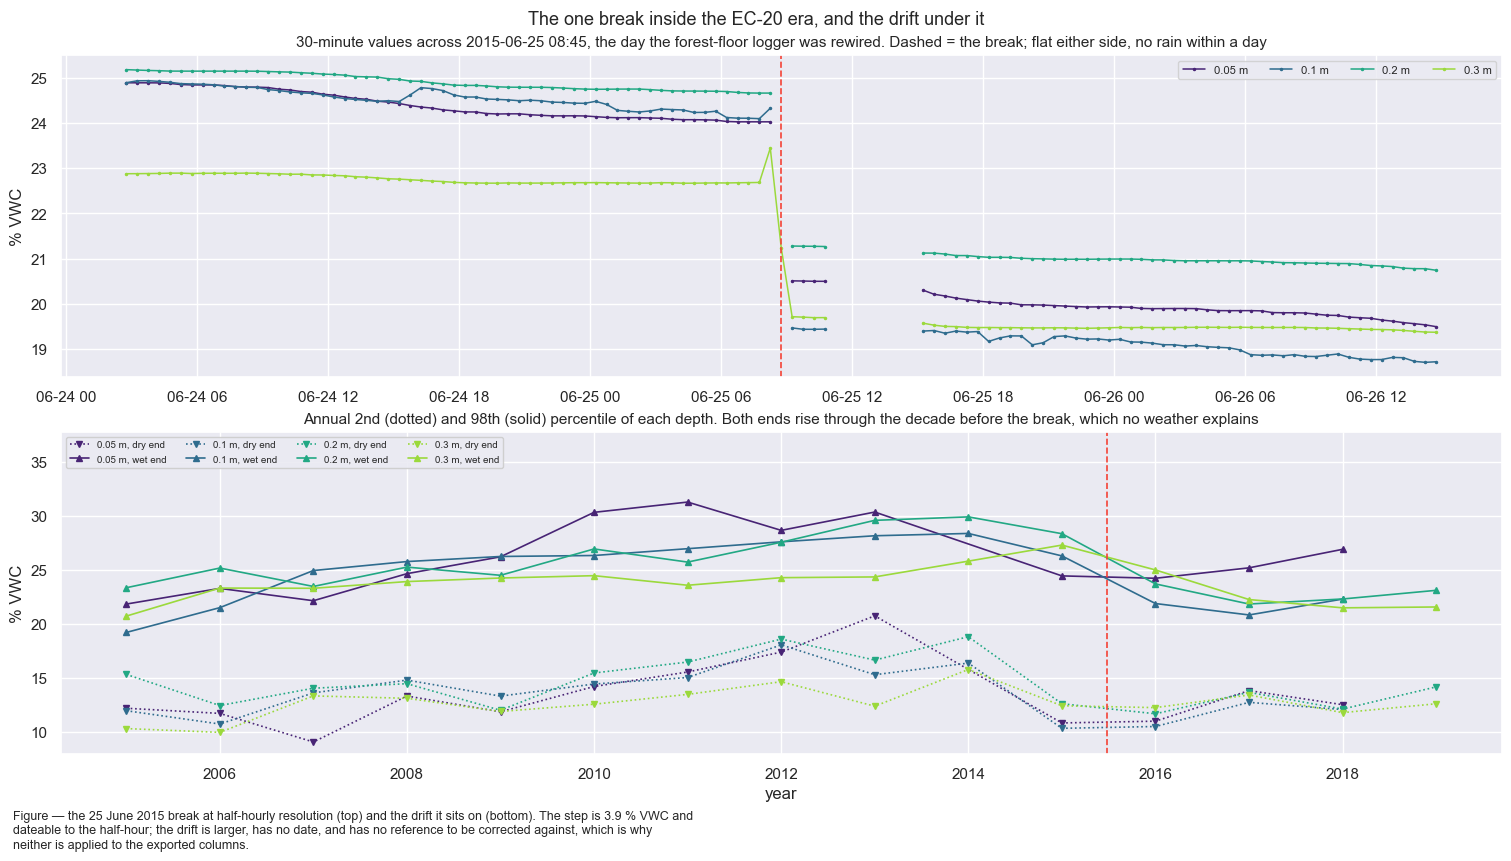

In [39]:
fig, axs = plt.subplots(nrows=2, figsize=(15, 8.5), dpi=100, layout='constrained')
fig.suptitle('The one break inside the EC-20 era, and the drift under it', fontsize=13)

_colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(MST_DEPTHS)))

# Top: the break at half-hourly resolution, which is the resolution the claim is made at. A daily
# panel cannot show this - it renders the step as one steep day among several.
_lo, _hi = BREAK - pd.Timedelta('30h'), BREAK + pd.Timedelta('30h')
for _c, d in zip(_colors, MST_DEPTHS):
    _s = ERA1[d].loc[_lo:_hi]
    axs[0].plot(_s.index, _s.values, lw=1.1, color=_c, marker='.', ms=3, label=f'{d} m')
axs[0].axvline(BREAK, color='#F44336', ls='--', lw=1.2)
axs[0].set_ylabel('% VWC')
axs[0].set_title(f'30-minute values across {FF_WIRING_BREAK}, the day the forest-floor logger was '
                 f'rewired. Dashed = the break; flat either side, no rain within a day',
                 fontsize=11)
axs[0].legend(fontsize=8, ncol=4)

# Bottom: the drift, at both ends of the range, with the break marked. One panel, because the
# argument is that the step is the smaller of the two features.
for _c, d in zip(_colors, MST_DEPTHS):
    _s = ERA1[d].dropna()
    _g = _s.groupby(_s.index.year)
    _lo_y = _g.quantile(0.02).where(_g.size() > 8000)
    _hi_y = _g.quantile(0.98).where(_g.size() > 8000)
    axs[1].plot(_lo_y.index, _lo_y.values, lw=1.2, ls=':', marker='v', ms=4, color=_c,
                label=f'{d} m, dry end')
    axs[1].plot(_hi_y.index, _hi_y.values, lw=1.2, ls='-', marker='^', ms=4, color=_c,
                label=f'{d} m, wet end')
axs[1].axvline(BREAK.year + BREAK.dayofyear / 365.25, color='#F44336', ls='--', lw=1.2)
axs[1].set_xlabel('year')
axs[1].set_ylabel('% VWC')
axs[1].set_title('Annual 2nd (dotted) and 98th (solid) percentile of each depth. Both ends rise '
                 'through the decade before the break, which no weather explains', fontsize=11)
# Headroom for the legend, which otherwise sits on the 2010-2011 wet-end peak - the highest point
# in the panel and part of what the panel is there to show.
_ylo, _yhi = axs[1].get_ylim()
axs[1].set_ylim(_ylo, _yhi + 0.22 * (_yhi - _ylo))
axs[1].legend(fontsize=7, ncol=4, loc='upper left', framealpha=0.9)
figcap(fig, f'the 25 June 2015 break at half-hourly resolution (top) and the drift it sits on '
            f'(bottom). The step is {abs(BREAK_STEP_MEAN):.1f} % VWC and dateable to the '
            f'half-hour; the drift is larger, has no date, and has no reference to be corrected '
            f'against, which is why neither is applied to the exported columns.')


### The era-1 numbers this notebook quotes, recomputed

Three figures about era 1 appear in the markdown of this notebook, and a markdown cell cannot
compute. They are re-derived here from the exported flags so that a re-run contradicts them loudly
instead of leaving them to be discovered by a reader.

One of the three was wrong when this section was written. The inter-era gap at 0.1 m was quoted as
**465 days**, which is the gap in the *raw* record; in the columns this notebook exports it is
**480 days**, because *Corrections* removes about 690 failed reads at the end of that probe's life
and so moves its last valid record about a fortnight earlier. Both numbers are true of different
objects, and the one worth quoting is the one describing the file.

The third is a claim that turned out to have no consequence, which is worth saying rather than
implying. The forest-floor programs clip a negative reading to `0`, so a zero in the raw era-1
record can be a failed read rather than dry soil — but the exported columns contain **no exact zeros
at all**, so nothing in the delivered file is affected by it.


In [40]:
# 1) the inter-era gap per depth, from the exported flags rather than from the pre-correction frames
_rows = []
for d in MST_DEPTHS:
    _e1 = swc[field(d)].where(swc[flagcol(d)] == FLAG_EC20_MST).dropna()
    _e2 = swc[field(d)].where(swc[flagcol(d)] == FLAG_TEROS_DIIVE).dropna()
    _rows.append({'depth_m': float(d), 'era1_last': _e1.index[-1], 'era2_first': _e2.index[0],
                  'gap_days_in_this_file': (_e2.index[0] - _e1.index[-1]).days})
GAPS_EXPORTED = pd.DataFrame(_rows).set_index('depth_m')
tabcap('the interval between the two sensor sets at each depth, measured on the exported columns. '
       'These are the numbers to quote about this product; the raw record gives a shorter gap at '
       'any depth where Corrections removed failed reads at the end of a probe\'s life.')
display(GAPS_EXPORTED)

_gmin, _gmax = int(GAPS_EXPORTED['gap_days_in_this_file'].min()), \
    int(GAPS_EXPORTED['gap_days_in_this_file'].max())
print(f"\ninter-era gap in this file: {_gmin} to {_gmax} days")
assert (_gmin, _gmax) == (22, 480), (
    f"the inter-era gaps are now {_gmin} to {_gmax} days. The markdown of this notebook quotes 22 "
    f"to 480 - update it, rather than only this assertion")

# 2) no exact zeros anywhere in the product, so the programs' negative-clip has no consequence here
_zeros = {d: int((swc[field(d)] == 0).sum()) for d in DEPTHS}
print(f"exact zeros per depth: {_zeros}")
assert sum(_zeros.values()) == 0, (
    f"the product now contains exact zeros ({_zeros}). Because the era-1 logger programs clip a "
    f"negative reading to 0, a zero here may be a failed read rather than dry soil - which the "
    f"closing notes currently say cannot arise in this file")

# 3) the season-matched 2020 step, which the notebook quotes as +8 to +11 % VWC
_steps = {}
for d in MST_DEPTHS:
    _e1 = era_series(d, FLAG_EC20_MST)
    _e2 = era_series(d, FLAG_TEROS_DIIVE)
    _m1, _m2 = _e1.groupby(_e1.index.month).mean(), _e2.groupby(_e2.index.month).mean()
    _c = _m1.index.intersection(_m2.index)
    _steps[d] = float((_m2[_c] - _m1[_c]).mean())
print(f"season-matched 2020 step: "
      f"{', '.join(f'{d} m {v:+.1f}' for d, v in _steps.items())} % VWC")
assert 7.4 <= min(_steps.values()) and max(_steps.values()) <= 11.0, (
    f"the 2020 step now spans {min(_steps.values()):+.1f} to {max(_steps.values()):+.1f} % VWC; "
    f"the notebook quotes '+8 to +11' in several places - update them")
print("The quoted '+8 to +11 % VWC' rounds a measured +7.6 to +10.7; the exact figures are above.")


Table — the interval between the two sensor sets at each depth, measured on the exported columns.
These are the numbers to quote about this product; the raw record gives a shorter gap at any depth
where Corrections removed failed reads at the end of a probe's life.



,era1_last,era2_first,gap_days_in_this_file
depth_m,,,
0.05,2019-04-12 23:45:00,2020-04-10 14:45:00,363
0.10,2018-12-17 14:45:00,2020-04-10 14:45:00,480
0.20,2020-03-18 23:45:00,2020-04-10 14:45:00,22
0.30,2019-11-08 23:45:00,2020-04-10 14:45:00,153



inter-era gap in this file: 22 to 480 days
exact zeros per depth: {'0.05': 0, '0.1': 0, '0.2': 0, '0.3': 0, '0.5': 0}
season-matched 2020 step: 0.05 m +9.3, 0.1 m +9.9, 0.2 m +10.7, 0.3 m +7.6 % VWC
The quoted '+8 to +11 % VWC' rounds a measured +7.6 to +10.7; the exact figures are above.


### What this section settles

::: {.callout-important title="Era 1 is not one level, and the exported columns do not pretend otherwise"}
**The January 2016 site renewal did nothing to this profile.** It replaced the tower installation;
this profile is on the forest-floor logger, the tower program measures no soil moisture, and the
data show no outage, no jump and no level change at the date. Asserted above, so the question does
not have to be reopened.

**Era 1 contains one demonstrable break, on 25 June 2015**, of about
`-3.9` % VWC at every depth, coinciding with work on the forest-floor logger's wiring
and with a fieldbook entry three weeks earlier that found the soil-moisture connectors loose. It is
the only whole-profile jump the detector finds in fifteen and a half years, the same detector finds
none in the TEROS era, and **soil temperature on the same station does not move at that half-hour**
- so the break is in the soil-moisture chain and not in the supply or the logger. *Demonstrable* rather than *only*: the rain filter cannot judge a
half-hour whose rain window the tower gauge did not measure, and before 2014 it did not always
measure.

**Underneath it is a decade-long upward drift roughly five times its size**, with no date and no
reference to correct it against.

So the `_HOMOGENIZED` columns lift era 1 onto the TEROS level as a **single** block, and that block
is internally inhomogeneous in two ways this section now measures. The caveat below is written
accordingly: assumption 2, that era 1 is internally homogeneous, is not an assumption any more. It
is known to be false, and its size is on the record.
:::


## ⚖️ Homogenising the pre-2020 era

::: {.callout-important title="This is the weakest thing in this notebook. Read it before using the columns."}
Notebook `08` homogenised one precipitation era onto another using an **independent gauge that
measured straight through the break**. That anchor is what made its factors defensible.

**Here there is no anchor at all.** The eras do not overlap by a single half-hour, no weather service
measures this plot's soil, and the other four depths all swap sensors on the same day, so they
cannot referee each other either. The offsets come from **climatology alone**: mean of era 2 in month
*m*, minus mean of era 1 in month *m*.

That carries three assumptions, none testable with the data in this product:

1. **That the two periods had the same monthly soil-moisture climate.** Any genuine climatic
   difference between 2004-2019 and 2020-2025 is absorbed into the offsets and re-issued as an
   instrument correction.
2. **That era 1 is internally homogeneous. It is not, and the section above measures how far
   from it.** Era 1 carries a dateable step of about -3.9 % VWC on 25 June 2015, when the
   forest-floor logger was rewired, and beneath that a drift of +0.5 to +1.2 % VWC per year at
   every depth through the decade before it - five to nine % VWC in total, at both the wet and the
   dry end of the range. The GIN inventory flags three of the four EC-20s `DEFECTIVE`, which is
   consistent with the drift. A per-month offset fitted on the whole of era 1 represents neither
   the step nor the drift: it splits the difference between two sub-eras and a decade of movement.
   This is the largest single reason not to read an absolute pre-2020 value out of a
   `_HOMOGENIZED` column.
3. **That the TEROS level is the right reference.** It is chosen for being modern, still running and
   diive-screened — not because anything establishes it as correct.

**Therefore:** the `_HOMOGENIZED` columns are for **continuity and trend work that has to cross
2020**. They are **not** an estimate of absolute soil water content before 2020, and not a
calibration. If your analysis lives inside one era, use the measured columns and ignore these.
:::

**At 0.3 m the third era is weaker still.** The replacement probe has only Mar-Dec 2025 — ten
calendar months of a single year — against a multi-year era-2 climatology, and it sits 40 cm down the
slope in different soil. Its own screening notebook measures the level step at about +3 % VWC against
the neighbouring depths and deliberately does not correct it. Here it *is* corrected, because the
point of the homogenised column is a continuous series. That makes 0.3 m the least trustworthy of the
four, and January and February 2025 have no season-matched estimate at all.

In [41]:
# A depth gets a homogenised column only if it carries MORE THAN ONE sensor era, re-derived from
# the flags after the corrections above. 0.5 m has a single era, so it gets none: exporting a copy
# of its measured column would invite someone to difference the two, get zero, and conclude the
# record is homogeneous - true for 0.5 m, false for every other depth.
HOMOG_DEPTHS = multi_era_depths()
SINGLE_ERA_DEPTHS = [d for d in DEPTHS if d not in HOMOG_DEPTHS]
print(f"homogenised columns for: {HOMOG_DEPTHS} m")
print(f"no homogenised column for: {SINGLE_ERA_DEPTHS} m (a single sensor era - nothing to shift)\n")

OFFSETS = {}     # {depth: {flag_code: (table, fallback)}}
for d in HOMOG_DEPTHS:
    ref = era_series(d, FLAG_TEROS_DIIVE)          # the reference level
    OFFSETS[d] = {}
    for _code in (FLAG_EC20_MST, FLAG_TEROS_REPLACEMENT):
        src = era_series(d, _code)
        if src.empty:
            continue
        OFFSETS[d][_code] = derive_monthly_offsets(
            src, ref, f'{field(d)}  era {_code} -> era {FLAG_TEROS_DIIVE}')

_tab = pd.DataFrame({f'{d} m  era {c}': OFFSETS[d][c][0]['offset']
                     for d in HOMOG_DEPTHS for c in OFFSETS[d]})
_tab.index.name = 'month'
print()
tabcap('the additive offset applied to each non-reference era, per calendar month. Era 1 is lifted '
       'onto the TEROS level; era 3, which reads high, is pushed down onto it.')
display(_tab.round(2))

homogenised columns for: ['0.05', '0.1', '0.2', '0.3'] m
no homogenised column for: ['0.5'] m (a single sensor era - nothing to shift)

  SWC_FF1_0.05_1  era 1 -> era 2               12/12 months fitted   offsets +6.21 .. +12.01   mean +9.30 % VWC
  SWC_FF1_0.1_1  era 1 -> era 2                12/12 months fitted   offsets +5.90 .. +12.55   mean +9.94 % VWC


  SWC_FF1_0.2_1  era 1 -> era 2                12/12 months fitted   offsets +8.08 .. +12.48   mean +10.66 % VWC
  SWC_FF1_0.3_1  era 1 -> era 2                12/12 months fitted   offsets +6.80 .. +8.32   mean +7.61 % VWC
  SWC_FF1_0.3_1  era 3 -> era 2                10/12 months fitted   offsets -4.26 .. -1.13   mean -3.11 % VWC

Table — the additive offset applied to each non-reference era, per calendar month. Era 1 is lifted
onto the TEROS level; era 3, which reads high, is pushed down onto it.



,0.05 m era 1,0.1 m era 1,0.2 m era 1,0.3 m era 1,0.3 m era 3
month,,,,,
1,12.01,12.41,12.48,8.19,-3.11
2,11.78,12.55,12.07,7.85,-3.11
3,9.73,11.89,11.40,7.28,-3.96
4,8.75,11.28,11.21,7.07,-3.96
5,9.97,10.90,11.47,7.74,-3.66
6,7.27,8.49,9.49,6.80,-4.26
7,8.19,7.00,8.99,7.49,-1.13
8,6.21,5.90,8.08,7.33,-1.48
9,7.70,7.26,9.80,8.06,-3.08


### The reference period is not the same at every depth

`derive_monthly_offsets` fits every era onto the **TEROS `FF1` era (flag `2`)**, and that era does
not cover the same years at every depth: at 0.05 / 0.1 / 0.2 m it runs from April 2020 to the end of
2025, but at 0.3 m it **ends at the April 2024 probe failure**, because everything from 2025-03-04
is flag `3`.

That follows from keeping the two TEROS probes apart, which is worth more than a common baseline —
folding the replacement into the level it is measured against would hide the 2025 step flag `3`
exists to expose. But it means the four `_HOMOGENIZED` columns are **not on one reference period**,
so a difference taken *between depths* across the break carries whatever 2024-2025 anomaly separates
the two baselines.

The cell below measures that, refitting the three full-length depths against a reference truncated to
0.3 m's window. Only the years sampled change between the two fits — the instrument pair is held
fixed — so whatever moves is the years alone, which is also this notebook's only handle on the
question left open in *The step is not the same in every month*. 0.3 m defines the truncation and
must therefore come back at exactly zero, which is what makes the other three numbers readable.
Nothing here is applied.

In [42]:
# The reference period actually used at each depth - read off the flags, not declared.
_rows = []
for d in HOMOG_DEPTHS:
    _ref = era_series(d, FLAG_TEROS_DIIVE)
    _rows.append({'depth_m': float(d), 'ref_first': _ref.index[0], 'ref_last': _ref.index[-1],
                  'ref_n': len(_ref),
                  'ref_years': round((_ref.index[-1] - _ref.index[0]).days / 365.25, 2)})
REFTAB = pd.DataFrame(_rows).set_index('depth_m')
tabcap('the reference era actually used at each depth. 0.3 m ends at the 2024 probe failure, so it '
       'is fitted against a shorter baseline than the other three.')
display(REFTAB)

REF_END_SHARED = REFTAB['ref_last'].min()          # the shortest reference window, i.e. 0.3 m's
print(f"one reference period at every depth: {REFTAB['ref_last'].nunique() == 1}")
print(f"shortest reference window ends {REF_END_SHARED} - every depth is refitted against that.\n")

# Refit against a reference truncated to the shortest window and compare. Quiet, because the table
# below is the result; NOTHING here is applied to the product.
_rows = []
for d in HOMOG_DEPTHS:
    _src = era_series(d, FLAG_EC20_MST)
    _ref_full = era_series(d, FLAG_TEROS_DIIVE)
    _t_full, _mean_full = derive_monthly_offsets(_src, _ref_full, d, verbose=False)
    _t_trunc, _mean_trunc = derive_monthly_offsets(_src, _ref_full.loc[:REF_END_SHARED], d,
                                                   verbose=False)
    _rows.append({'depth_m': float(d), 'mean_offset_full': _mean_full,
                  'mean_offset_truncated': _mean_trunc,
                  'mean_shift': _mean_trunc - _mean_full,
                  'max_abs_monthly_shift': float((_t_trunc['offset'] - _t_full['offset']).abs().max())})
BASELINE = pd.DataFrame(_rows).set_index('depth_m').round(3)
tabcap('how far each depth\'s offsets move when the reference is truncated to 0.3 m\'s window. '
       'This is the size of the cross-depth baseline difference the _HOMOGENIZED columns carry, '
       'and a lower bound on how much of a monthly offset is the years sampled rather than the '
       'instruments compared.')
display(BASELINE)

# The control: for the depth that DEFINES the shortest window the truncated reference is the full
# one, so its shift must be exactly zero. Found from the table rather than assumed to be 0.3 m - if
# a re-screening ever makes another depth the shortest, the control moves with it.
_ctrl = REFTAB.index[REFTAB['ref_last'] == REF_END_SHARED]
assert len(_ctrl) >= 1, "no depth defines the shortest reference window - REFTAB is inconsistent"
for _d in _ctrl:
    assert abs(float(BASELINE.loc[_d, 'mean_shift'])) < 1e-9, (
        f"{_d} m moved when its own reference was 'truncated' to its own end - the truncation is "
        f"not doing what this section says it does")

print(f"control: {list(_ctrl)} m define the shortest window and shift by exactly 0, as they must.")
print(f"Truncating the reference to {REF_END_SHARED.date()} moves a depth's mean offset by at most "
      f"{BASELINE['mean_shift'].abs().max():.2f} % VWC,\nand a single calendar month by at most "
      f"{BASELINE['max_abs_monthly_shift'].max():.2f} % VWC. Reported, not corrected: giving 0.3 m "
      f"the same\nwindow as the others means folding its 2025 replacement probe into the level it "
      f"is measured against.")

Table — the reference era actually used at each depth. 0.3 m ends at the 2024 probe failure, so it
is fitted against a shorter baseline than the other three.



,ref_first,ref_last,ref_n,ref_years
depth_m,,,,
0.05,2020-04-10 14:45:00,2025-12-31 23:45:00,94462,5.72
0.10,2020-04-10 14:45:00,2025-12-31 23:45:00,98539,5.72
0.20,2020-04-10 14:45:00,2025-12-31 23:45:00,98552,5.72
0.30,2020-04-10 14:45:00,2024-04-09 16:45:00,69152,4.00


one reference period at every depth: False
shortest reference window ends 2024-04-09 16:45:00 - every depth is refitted against that.



Table — how far each depth's offsets move when the reference is truncated to 0.3 m's window. This is
the size of the cross-depth baseline difference the _HOMOGENIZED columns carry, and a lower bound on
how much of a monthly offset is the years sampled rather than the instruments compared.



,mean_offset_full,mean_offset_truncated,mean_shift,max_abs_monthly_shift
depth_m,,,,
0.05,9.302,9.469,0.167,1.190
0.10,9.938,10.276,0.337,1.231
0.20,10.660,10.586,-0.074,0.869
0.30,7.614,7.614,0.000,0.000


control: [0.3] m define the shortest window and shift by exactly 0, as they must.
Truncating the reference to 2024-04-09 moves a depth's mean offset by at most 0.34 % VWC,
and a single calendar month by at most 1.23 % VWC. Reported, not corrected: giving 0.3 m the same
window as the others means folding its 2025 replacement probe into the level it is measured against.


In [43]:
# Applied to the measured column. A gap is NaN, and NaN + offset is NaN, so the offsets cannot
# turn a gap into a value - the structural version of notebook 03's lesson.
_months = full_index.month
for d in DEPTHS:
    if d not in HOMOG_DEPTHS:
        continue
    off = np.zeros(len(full_index))
    for _code, (_t, _) in OFFSETS[d].items():
        _mask = (swc[flagcol(d)] == _code).to_numpy()
        off = np.where(_mask, _t['offset'].reindex(_months).to_numpy(), off)
    swc[homogcol(d)] = swc[field(d)] + off
    _shifted = int(((swc[flagcol(d)].isin([FLAG_EC20_MST, FLAG_TEROS_REPLACEMENT]))
                    & swc[field(d)].notna()).sum())
    print(f"  {homogcol(d):<34} shifted {_shifted:>7,} records, "
          f"left {int((swc[flagcol(d)] == FLAG_TEROS_DIIVE).sum()):>7,} unchanged")

# Invariants. Each one is a way the homogenisation could quietly corrupt the product.
for d in HOMOG_DEPTHS:
    h, v, fl = swc[homogcol(d)], swc[field(d)], swc[flagcol(d)]
    assert h.isna().equals(v.isna()), f"{homogcol(d)}: changed which records are missing"
    _ref = fl == FLAG_TEROS_DIIVE
    assert ((h[_ref] - v[_ref]).abs() < 1e-9).all(), \
        f"{homogcol(d)}: the TEROS era was modified, but it IS the reference level"
    assert (h.dropna() >= 0).all() and (h.dropna() <= 100).all(), \
        f"{homogcol(d)}: a homogenised value left the physical range"
    _n_over = int((h.dropna() > SWC_PLAUSIBLE_PCT[1]).sum())
    if _n_over:
        print(f"  (!) {homogcol(d)}: {_n_over:,} homogenised values exceed "
              f"{SWC_PLAUSIBLE_PCT[1]} % VWC - a shifted estimate, not a measurement, so it is "
              f"kept and flagged here rather than clipped")
print("\nGaps untouched, the reference era untouched, every shifted value inside the physical range.")

  SWC_FF1_0.05_1_HOMOGENIZED         shifted 207,596 records, left  94,462 unchanged
  SWC_FF1_0.1_1_HOMOGENIZED          shifted 238,767 records, left  98,539 unchanged
  SWC_FF1_0.2_1_HOMOGENIZED          shifted 260,311 records, left  98,552 unchanged
  SWC_FF1_0.3_1_HOMOGENIZED          shifted 253,938 records, left  69,152 unchanged

Gaps untouched, the reference era untouched, every shifted value inside the physical range.


### Does it land where it should?

By construction the fitted months land exactly on the reference level, so agreeing with them proves
only that the arithmetic is right — worth proving, and all it proves. The honest check is the second
table: annual means before and after, and whether the residual step across 2020 has gone.

In [44]:
_rows = []
for d in HOMOG_DEPTHS:
    for _code in OFFSETS[d]:
        _src_h = swc[homogcol(d)].where(swc[flagcol(d)] == _code).dropna()
        _ref = era_series(d, FLAG_TEROS_DIIVE)
        _t = OFFSETS[d][_code][0]
        _fitted = _t.index[_t['fitted']]
        _a = _src_h.groupby(_src_h.index.month).mean().reindex(_fitted)
        _b = _ref.groupby(_ref.index.month).mean().reindex(_fitted)
        _rows.append({'depth_m': float(d), 'flag': _code, 'months_fitted': len(_fitted),
                      'max_abs_residual': float((_a - _b).abs().max())})
_landing = pd.DataFrame(_rows).set_index(['depth_m', 'flag'])
tabcap('residual between each homogenised era and the reference level, in the months its offsets '
       'were fitted on. Zero by construction - this checks the arithmetic and nothing else.')
display(_landing.round(9))
assert (_landing['max_abs_residual'] < 1e-6).all(), \
    "a homogenised era does not land on the reference level in its own fitted months"

_before = {}
for d in HOMOG_DEPTHS:
    _e1 = swc[field(d)].where(swc[flagcol(d)] == FLAG_EC20_MST).dropna()
    _e1h = swc[homogcol(d)].where(swc[flagcol(d)] == FLAG_EC20_MST).dropna()
    _before[f'{d} m'] = {'era1 measured': float(_e1.mean()),
                         'era1 homogenised': float(_e1h.mean()),
                         'era2 (reference)': float(era_series(d, FLAG_TEROS_DIIVE).mean())}
_land = pd.DataFrame(_before).T
_land['residual step'] = _land['era2 (reference)'] - _land['era1 homogenised']
tabcap('era means before and after homogenisation. The season-matched step is gone; what remains '
       'is the difference in which months each era actually sampled, which is real.')
display(_land.round(3))

# Loose on purpose. The residual is NOT expected to be zero: the two eras sample different months in
# different proportions - era 2 begins in mid-April 2020 and so under-weights one winter - and that
# difference is real, not an error in the offsets. The band only has to catch an offset applied with
# the wrong sign, to the wrong era, or in the wrong unit.
assert _land['residual step'].abs().max() < 2.0, \
    "the homogenised pre-2020 era does not sit anywhere near the TEROS level"

Table — residual between each homogenised era and the reference level, in the months its offsets
were fitted on. Zero by construction - this checks the arithmetic and nothing else.



months_fitted  max_abs_residual
depth_m flag                                 
0.05    1                12               0.0
0.10    1                12               0.0
0.20    1                12               0.0
0.30    1                12               0.0
        3                10               0.0

Table — era means before and after homogenisation. The season-matched step is gone; what remains is
the difference in which months each era actually sampled, which is real.



,era1 measured,era1 homogenised,era2 (reference),residual step
0.05 m,20.575,29.911,29.877,-0.034
0.1 m,19.995,29.861,29.773,-0.088
0.2 m,20.693,31.344,31.232,-0.112
0.3 m,18.920,26.549,26.714,0.165


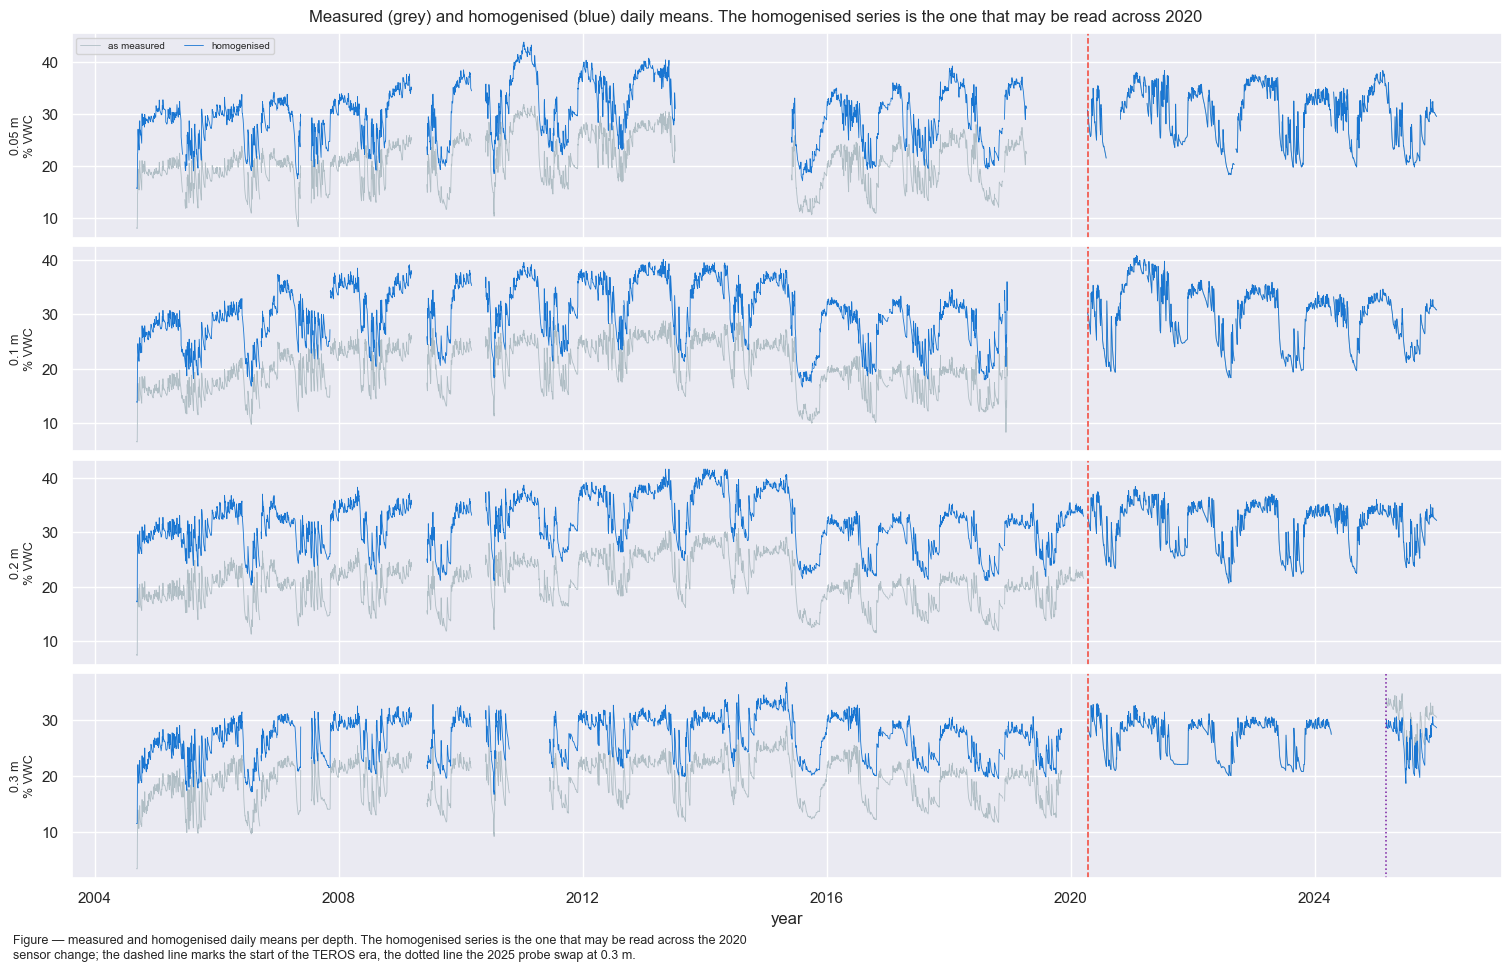

In [45]:
fig, axs = plt.subplots(nrows=len(HOMOG_DEPTHS), figsize=(15, 2.4 * len(HOMOG_DEPTHS)),
                        dpi=100, layout='constrained', sharex=True)
fig.suptitle('Measured (grey) and homogenised (blue) daily means. The homogenised series is the '
             'one that may be read across 2020', fontsize=12)
for _i, (ax, d) in enumerate(zip(np.atleast_1d(axs), HOMOG_DEPTHS)):
    _m = swc[field(d)].resample('1D').mean()
    _h = swc[homogcol(d)].resample('1D').mean()
    ax.plot(_m.index, _m.values, lw=0.6, color='#B0BEC5', label='as measured')
    ax.plot(_h.index, _h.values, lw=0.6, color='#1976D2', label='homogenised')
    ax.axvline(diive_[field(d)].first_valid_index(), color='#F44336', ls='--', lw=1.1)
    if d == SWAP_DEPTH:
        ax.axvline(pd.Timestamp(SENSOR_SWAP), color='#7B1FA2', ls=':', lw=1.1)
    ax.set_ylabel(f'{d} m\n% VWC', fontsize=9)
    if _i == 0:   # the panels share one vocabulary; four identical legends is noise
        ax.legend(fontsize=7, loc='upper left', ncol=2)
np.atleast_1d(axs)[-1].set_xlabel('year')
figcap(fig, 'measured and homogenised daily means per depth. The homogenised series is the one '
            'that may be read across the 2020 sensor change; the dashed line marks the start of '
            'the TEROS era, the dotted line the 2025 probe swap at 0.3 m.')

***

## 🚫 What is not filled, and why

**Nothing in this product is gap-filled**, and unlike notebook `08` — where the decision was made
against a measured alternative — here there is no alternative to decide against.

- **No external reference exists.** MeteoSwiss measures no soil moisture at this plot, at Lägern or
  at Ehrendingen, and there is no NABEL soil profile. The nearest thing is the other four depths of
  this same profile, which is what the `20_SCREENING/SWC` notebooks use as a cross-check — and which
  is useless as a *fill* source, because the depths swap sensors on the same day and share every
  power and logger fault.
- **The largest gaps are the inter-era gaps**, and filling them would be the worst thing this
  notebook could do. Interpolating a state variable across 363 days of a dead probe produces a
  smooth, plausible, entirely fabricated year — the failure mode soil moisture is most vulnerable
  to, because a wrong SWC series looks exactly like a right one.
- **Some era-1 gaps are explained, and the explanation makes filling them worse.** Both whole-station
  gaps longer than 60 days were a dead logger. A dead logger means no soil was measured, not that the soil
  did nothing.

The inventory below is what a downstream user needs in order to choose which periods to use.

In [46]:
_rows = []
for d in DEPTHS:
    s = swc[field(d)]
    _present = s.notna()
    # Runs of consecutive missing records, ignoring the period before the depth's own record starts.
    _first = s.first_valid_index()
    _m = ~_present.loc[_first:]
    _grp = (_m != _m.shift()).cumsum()[_m]
    _runs = _m.loc[_m].groupby(_grp).size() * 0.5 / 24  # records -> days
    _rows.append({'depth_m': float(d), 'record_starts': _first,
                  'n_measured': int(_present.sum()),
                  'coverage_since_start_%': round(100 * float(_present.loc[_first:].mean()), 2),
                  'n_gaps': int(len(_runs)),
                  'gaps_over_30d': int((_runs > 30).sum()),
                  'longest_gap_d': round(float(_runs.max()) if len(_runs) else 0.0, 1)})
GAPTAB = pd.DataFrame(_rows).set_index('depth_m')
tabcap('coverage and gap structure of each depth since its own record begins. The longest gap at '
       'four of the five depths is an inter-era gap, i.e. a dead probe rather than an outage.')
display(GAPTAB)

def missing_blocks(mask: pd.Series):
    """Contiguous runs of True in a boolean series, as (first, last, n_records)."""
    grp = (mask != mask.shift()).cumsum()
    return [(g.index[0], g.index[-1], len(g)) for _, g in mask[mask].groupby(grp[mask])]


print("The five longest gaps per depth, with the era on each side:\n")
for d in DEPTHS:
    s = swc[field(d)]
    _first = s.first_valid_index()
    _blocks = sorted(missing_blocks((~s.notna()).loc[_first:]), key=lambda t: -t[2])[:5]
    print(f"  {field(d)}")
    for _a, _b, _n in _blocks:
        _is_inter = (d in INTER_ERA_GAP) and (_a > mst[field(d)].last_valid_index()) and \
                    (_b < diive_[field(d)].first_valid_index())
        print(f"     {_a:%Y-%m-%d} -> {_b:%Y-%m-%d}   {_n * 0.5 / 24:6.1f} d"
              f"{'   <- the dead interval between the two sensor sets' if _is_inter else ''}")

Table — coverage and gap structure of each depth since its own record begins. The longest gap at
four of the five depths is an inter-era gap, i.e. a dead probe rather than an outage.



,record_starts,n_measured,coverage_since_start_%,n_gaps,gaps_over_30d,longest_gap_d
depth_m,,,,,,
0.05,2004-09-07 13:45:00,302058,80.83,100,6,695.1
0.10,2004-09-07 13:45:00,337306,90.26,105,3,480.0
0.20,2004-09-07 13:45:00,358863,96.03,108,2,92.9
0.30,2004-09-07 13:45:00,323090,86.46,70,6,328.9
0.50,2020-04-10 14:45:00,98588,98.21,31,0,14.3


The five longest gaps per depth, with the era on each side:

  SWC_FF1_0.05_1
     2013-07-08 -> 2015-06-03    695.1 d
     2019-04-13 -> 2020-04-10    363.6 d   <- the dead interval between the two sensor sets
     2009-03-10 -> 2009-06-11     92.9 d
     2020-08-01 -> 2020-10-23     84.0 d
     2010-03-06 -> 2010-05-28     82.9 d
  SWC_FF1_0.1_1
     2018-12-17 -> 2020-04-10    480.0 d
     2009-03-10 -> 2009-06-11     92.9 d
     2010-03-06 -> 2010-05-28     82.9 d
     2024-04-09 -> 2024-04-23     14.3 d
     2013-03-09 -> 2013-03-22     12.6 d
  SWC_FF1_0.2_1
     2009-03-10 -> 2009-06-11     92.9 d
     2010-03-06 -> 2010-05-28     82.9 d
     2020-03-19 -> 2020-04-10     22.6 d   <- the dead interval between the two sensor sets
     2024-04-09 -> 2024-04-23     14.3 d
     2013-03-09 -> 2013-03-22     12.6 d
  SWC_FF1_0.3_1
     2024-04-09 -> 2025-03-04    328.9 d
     2010-10-18 -> 2011-06-16    240.8 d
     2019-11-09 -> 2020-04-10    153.6 d   <- the dead interval between the

### The whole-station gaps of the EC-20 era, and what caused them

**Evidence first, fieldbook second.** The cell below scans the EC-20 era blind for periods where
**all four** depths are missing at once — a whole-station failure rather than one dead probe — and
only then asks the legacy record what happened there.

Both long ones come back with an answer that matches the data to the day: a remark of 23.07.2010
added to the 31.05.2009 entry, *"No forest floor logger data recorded from doy 69 to 162"*; and a
remark added to the 17.05.2010 entry recording that a fuse had slipped out at the forest-floor
station between 6 March and 28 May 2010, leaving the logger without power. DOY 69-162 of 2009 is
converted and asserted against the gap the scan found rather than taken on faith. Both are power
failures of a battery-run station — the failure mode the rest of the legacy record leads one to
expect — and both are remarks written a year or more after the fact, so the corroboration runs from
the data to the note, not the other way round.

In [47]:
# All four old depths missing at once, inside the era where all four were alive.
_mst_first = min(mst[field(d)].first_valid_index() for d in MST_DEPTHS)
_mst_last_shared = min(mst[field(d)].last_valid_index() for d in MST_DEPTHS)
_all_missing = pd.Series(True, index=full_index)
for d in MST_DEPTHS:
    _all_missing &= swc[field(d)].isna()
_all_missing = _all_missing.loc[_mst_first:_mst_last_shared]

SHARED_GAPS = [(a, b, n * 0.5 / 24) for a, b, n in missing_blocks(_all_missing) if n * 0.5 / 24 > 60]
print(f"whole-station gaps longer than 60 days, {_mst_first.date()} -> "
      f"{_mst_last_shared.date()} (all {len(MST_DEPTHS)} old depths missing at once):\n")

_LEGACY_CAUSE = r'Waldboden|forest floor|Sicherung|fuse|Strom|power|logger|doy'
EXPLAINED, UNEXPLAINED = [], []
for _a, _b, _d in SHARED_GAPS:
    print(f"  {_a:%Y-%m-%d} -> {_b:%Y-%m-%d}   {_d:.0f} days")
    _near = LEGACY[LEGACY['date'].between(_a - pd.Timedelta(days=30), _b + pd.Timedelta(days=30))]
    _cause = _near[_near['text'].str.contains(_LEGACY_CAUSE, case=False, na=False, regex=True)]
    if len(_cause):
        EXPLAINED.append((_a, _b, _d))
        for _, _r in _cause.iterrows():
            print(f"      legacy {_r['date']:%Y-%m-%d}: {_r['text'][:400]}")
    else:
        UNEXPLAINED.append((_a, _b, _d))
        print("      (no legacy sub-entry within +/-30 days)")

print(f"\nexplained: {len(EXPLAINED)} of {len(SHARED_GAPS)} whole-station gaps")
assert len(SHARED_GAPS) >= 2, ("the whole-station gaps this section explains are not in the data - "
                               "re-read the section before quoting it")
assert len(EXPLAINED) >= 2, ("the legacy record no longer explains any whole-station gap; either "
                             "the parse or the search pattern broke")

whole-station gaps longer than 60 days, 2004-09-07 -> 2018-12-31 (all 4 old depths missing at once):

  2009-03-10 -> 2009-06-11   93 days
      legacy 2009-02-25: 25.02.2009 (person 04) Li-8100 Automated Soil Chamber Restarted at 16:00 (MEWZ), Reset of powerground for Meteo station was necessary
      legacy 2009-05-31: 31.05.2009 (person 07) Hard-disk of EC-Computer broken down, restart: 1.06.2009 Remark (person 31 23.07.2010): No forest floor logger data recorded from doy 69 to 162.
  2010-03-06 -> 2010-05-28   83 days
      legacy 2010-02-10: 10.02.2010 (person 07 & person 11) neue Pumpen in Profileinhet fuer CO2-Profil eingebaut (lief die letzten Wochen vermutlich nicht check data); neue Referenzgasflasche angeschlossen (im Labor 237ppm mit Li-840 gemessen) Dendrometer 1 (von N.Ruehr) wieder angeschaltet (Stromversorgung war aus seit dem 20.01) neue Dendrometer (von R.Zweifel) wieder montiert an Fichte, neu eingestellt auf 50 mV, Dend
      legacy 2010-03-04: 04.03.2010 (person 07

In [48]:
# The DOY claim, converted and checked against the gap the scan found. This is the one place where
# the fieldbook makes a quantitative statement that the data can falsify, so it is not left as prose.
# Only doy ranges that are ABOUT the forest-floor logger: the legacy record uses day-of-year for
# other instruments too, and those are not claims about this station.
_doy_hits = LEGACY[
    LEGACY['text'].str.contains(r'doy\s*\d+\s*(?:to|bis|-|–)\s*\d+', case=False, na=False, regex=True)
    & LEGACY['text'].str.contains(r'forest floor|Waldboden|logger', case=False, na=False, regex=True)]
assert len(_doy_hits) > 0, "the doy remark about the forest-floor logger is not in the parsed record"

_confirmed, _unconfirmed = 0, []
for _, _r in _doy_hits.iterrows():
    _m = re.search(r'doy\s*(\d+)\s*(?:to|bis|-|–)\s*(\d+)', _r['text'], flags=re.I)
    _y = _r['date'].year
    _from = pd.Timestamp(year=_y, month=1, day=1) + pd.Timedelta(days=int(_m.group(1)) - 1)
    _to = pd.Timestamp(year=_y, month=1, day=1) + pd.Timedelta(days=int(_m.group(2)) - 1)
    _match = [(a, b, d) for a, b, d in SHARED_GAPS
              if abs((a - _from).days) <= 3 and abs((b - _to).days) <= 3]
    print(f"legacy {_r['date']:%Y-%m-%d}: doy {_m.group(1)}-{_m.group(2)} of {_y} "
          f"= {_from:%Y-%m-%d} -> {_to:%Y-%m-%d}")
    print(f"   whole-station gap found in the data: "
          f"{[(f'{a:%Y-%m-%d}', f'{b:%Y-%m-%d}', f'{d:.0f} d') for a, b, d in _match] or 'NONE'}")
    if _match:
        _confirmed += 1
    else:
        _unconfirmed.append((_r['date'].date(), _from.date(), _to.date()))

assert _confirmed > 0, ("no fieldbook claim about missing forest-floor data lines up with a gap in "
                        "the data - either the parse or the gap scan is wrong")
print(f"\n{_confirmed} fieldbook claim(s) confirmed by the data to within three days.")
if _unconfirmed:
    print(f"Claims that did NOT line up (worth reading before trusting them): {_unconfirmed}")
print(f"Whole-station gaps with no legacy explanation: "
      f"{[(f'{a:%Y-%m-%d}', f'{b:%Y-%m-%d}') for a, b, _ in UNEXPLAINED] or 'none'}")

legacy 2009-05-31: doy 69-162 of 2009 = 2009-03-10 -> 2009-06-11
   whole-station gap found in the data: [('2009-03-10', '2009-06-11', '93 d')]

1 fieldbook claim(s) confirmed by the data to within three days.
Whole-station gaps with no legacy explanation: none


***

## ➡️ Prepare dataframe for export

Columns are grouped **by depth** rather than by kind: value, homogenised twin, flag. A soil profile
is read one depth at a time, so a number's provenance is never more than two columns away from it.

In [49]:
EXPORT_COLS = []
for d in DEPTHS:
    EXPORT_COLS.append(field(d))
    if d in HOMOG_DEPTHS:
        EXPORT_COLS.append(homogcol(d))
    EXPORT_COLS.append(flagcol(d))

export_df = swc[EXPORT_COLS].copy()
for d in DEPTHS:
    export_df[flagcol(d)] = export_df[flagcol(d)].astype(int)
print(f"{len(EXPORT_COLS)} columns: {len(DEPTHS)} measured, {len(HOMOG_DEPTHS)} homogenised, "
      f"{len(DEPTHS)} flags")
tabcap('the exported frame: value, homogenised twin and source flag for each depth, grouped by '
       'depth so a value and its provenance stay adjacent.')
export_df

14 columns: 5 measured, 4 homogenised, 5 flags
Table — the exported frame: value, homogenised twin and source flag for each depth, grouped by depth
so a value and its provenance stay adjacent.



,SWC_FF1_0.05_1,SWC_FF1_0.05_1_HOMOGENIZED,FLAG_SWC_FF1_0.05_1_SOURCE,SWC_FF1_0.1_1,SWC_FF1_0.1_1_HOMOGENIZED,FLAG_SWC_FF1_0.1_1_SOURCE,SWC_FF1_0.2_1,SWC_FF1_0.2_1_HOMOGENIZED,FLAG_SWC_FF1_0.2_1_SOURCE,SWC_FF1_0.3_1,SWC_FF1_0.3_1_HOMOGENIZED,FLAG_SWC_FF1_0.3_1_SOURCE,SWC_FF1_0.5_1,FLAG_SWC_FF1_0.5_1_SOURCE
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,
2004-09-07 00:15:00,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,0
2004-09-07 00:45:00,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,0
2004-09-07 01:15:00,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,0
2004-09-07 01:45:00,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,0
2004-09-07 02:15:00,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 21:45:00,29.538065,29.538065,2,30.736580,30.736580,2,32.139789,32.139789,2,30.388568,28.508098,3,25.212793,2
2025-12-31 22:15:00,29.528240,29.528240,2,30.735927,30.735927,2,32.138521,32.138521,2,30.382575,28.502105,3,25.209556,2
2025-12-31 22:45:00,29.530094,29.530094,2,30.733229,30.733229,2,32.133453,32.133453,2,30.378484,28.498014,3,25.209057,2


Sanity checks. The product is **not** expected to be complete, so what is checked is that the index
is sound, that every value present is physically plausible % VWC, and that at every depth the flag,
the value and the homogenised column tell one story.

In [50]:
_lo, _hi = SWC_PLAUSIBLE_PCT

print(f"Records:          {len(export_df):,}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum())}\n")

# Index invariants.
assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "index not continuous 30MIN"
assert export_df.index.name == 'TIMESTAMP_MIDDLE', "the index is not named TIMESTAMP_MIDDLE"

_rows = []
for d in DEPTHS:
    v, fl = export_df[field(d)], export_df[flagcol(d)]
    # Flag and value tell one story.
    assert (v.notna() == fl.isin(MEASURED_FLAGS)).all(), \
        f"{field(d)}: a value without a flag, or a flag without a value"
    assert fl.isin(FLAG_SOURCE_LEGEND).all(), f"{flagcol(d)}: unknown flag code"
    assert fl.notna().all(), f"{flagcol(d)}: a record carries no flag"
    # Physical range.
    _vals = v.dropna()
    assert _vals.min() >= _lo and _vals.max() <= _hi, \
        f"{field(d)}: values outside {_lo}-{_hi} % VWC - possible unit or gain error"
    # The homogenised column exists exactly where its measured column does.
    if d in HOMOG_DEPTHS:
        assert export_df[homogcol(d)].notna().equals(v.notna()), \
            f"{homogcol(d)}: non-null in different records than {field(d)}"
    else:
        assert homogcol(d) not in export_df.columns, \
            f"{d} m has a single era and must not carry a homogenised column"
    _rows.append({'depth_m': float(d), 'measured': int(v.notna().sum()),
                  'coverage_%': round(100 * float(v.notna().mean()), 2),
                  'min': round(float(_vals.min()), 2), 'max': round(float(_vals.max()), 2),
                  'mean': round(float(_vals.mean()), 2),
                  'homogenised': d in HOMOG_DEPTHS})
tabcap('range and coverage of every exported value column. Coverage is against the full '
       '2004-2025 index, which is why 0.5 m reads low: it has no probe before 2020.')
display(pd.DataFrame(_rows).set_index('depth_m'))
print("All checks passed.\n")

_fc = pd.DataFrame({f'{d} m': export_df[flagcol(d)].value_counts() for d in DEPTHS}).fillna(0).astype(int)
_fc = _fc.sort_index()
_fc['meaning'] = [FLAG_SOURCE_LEGEND[i] for i in _fc.index]
tabcap('how many records each source flag holds at each depth.')
display(_fc)

Records:          373,728
Index:            2004-09-07 00:15:00 -> 2025-12-31 23:45:00
Duplicate index:  0
Index gaps:       0

Table — range and coverage of every exported value column. Coverage is against the full 2004-2025
index, which is why 0.5 m reads low: it has no probe before 2020.



,measured,coverage_%,min,max,mean,homogenised
depth_m,,,,,,
0.05,302058,80.82,7.70,39.71,23.48,True
0.10,337306,90.25,0.84,41.71,22.85,True
0.20,358863,96.02,7.32,39.03,23.59,True
0.30,323090,86.45,3.32,36.41,21.05,True
0.50,98588,26.38,18.88,31.75,24.12,False


All checks passed.



Table — how many records each source flag holds at each depth.



,0.05 m,0.1 m,0.2 m,0.3 m,0.5 m,meaning
0,71670,36422,14865,50638,275140,"0 = no measurement (gap, or before this depth'..."
1,207596,238767,260311,239424,0,"1 = EC-20 / M5 profile, MeteoScreeningTool scr..."
2,94462,98539,98552,69152,98588,2 = TEROS 12 FF1 profile installed 19 Mar 2020...
3,0,0,0,14514,0,"3 = TEROS 12 replacement probe, 40 cm downslop..."


### Per-year coverage, by sensor set

`n_1` / `n_2` / `n_3` count records of each sensor era. A year where two are non-zero is a year the
profile changed instrument, and its annual mean is not the mean of a measurement.

In [51]:
_rows = []
for d in DEPTHS:
    fl = export_df[flagcol(d)]
    _yr = fl.index.year
    # Vectorised per flag code: one boolean sum per code instead of a groupby-apply per code.
    _t = pd.DataFrame({f'n_{c}': (fl == c).groupby(_yr).sum() for c in MEASURED_FLAGS})
    _t['possible'] = fl.groupby(_yr).size()
    _t['coverage_%'] = (100 * _t[[f'n_{c}' for c in MEASURED_FLAGS]].sum(axis=1)
                        / _t['possible']).round(1)
    _t['mean_pct'] = export_df[field(d)].groupby(_yr).mean().round(2)
    _t['depth_m'] = float(d)
    _rows.append(_t.reset_index(names='year'))
YEARTAB = pd.concat(_rows).set_index(['depth_m', 'year'])
tabcap('records per year and sensor era, per depth. A year with two non-zero counts changed '
       'instrument mid-year, and its mean_pct mixes two sensor sets.')
display(YEARTAB)

_mixed = YEARTAB[(YEARTAB[[f'n_{c}' for c in MEASURED_FLAGS]] > 0).sum(axis=1) > 1]
print(f"years mixing two sensor sets (do not read their annual means): "
      f"{sorted(set(_mixed.index.get_level_values('year')))}")

Table — records per year and sensor era, per depth. A year with two non-zero counts changed
instrument mid-year, and its mean_pct mixes two sensor sets.



n_1    n_2  n_3  possible  coverage_%  mean_pct
depth_m year                                                   
0.05    2004   5541      0    0      5568        99.5     18.07
        2005  16894      0    0     17520        96.4     18.18
        2006  17067      0    0     17520        97.4     19.13
        2007  14366      0    0     17520        82.0     18.21
        2008  17566      0    0     17568       100.0     20.20
...             ...    ...  ...       ...         ...       ...
0.50    2021      0  17124    0     17520        97.7     24.33
        2022      0  17027    0     17520        97.2     24.23
        2023      0  17476    0     17520        99.7     23.75
        2024      0  16703    0     17568        95.1     24.68
        2025      0  17519    0     17520       100.0     24.33

[110 rows x 6 columns]

years mixing two sensor sets (do not read their annual means): [2020]


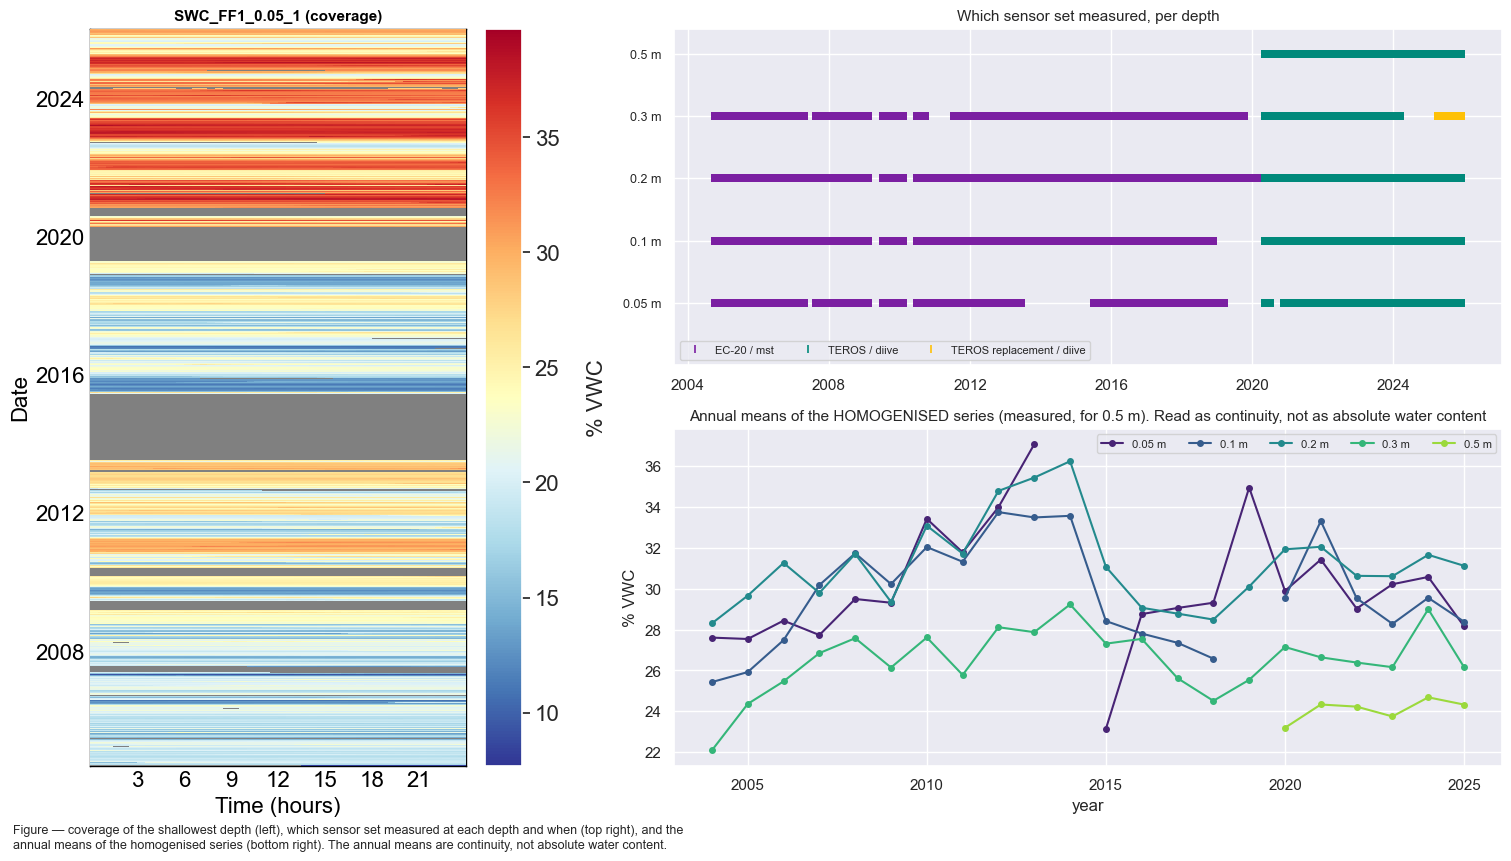

In [52]:
fig = plt.figure(figsize=(15, 8.5), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2.2], figure=fig)
ax_hm = fig.add_subplot(gs[:, 0])
ax_fl = fig.add_subplot(gs[0, 1])
ax_yr = fig.add_subplot(gs[1, 1])

dv.plotting.HeatmapDateTime(series=export_df[field(DEPTHS[0])]).plot(
    ax=ax_hm, cb_digits_after_comma=0, zlabel='% VWC',
    format_style=dv.plotting.FormatStyle(title=f'{field(DEPTHS[0])} (coverage)', title_fontsize=11))

for _i, d in enumerate(DEPTHS):
    _fl = export_df[flagcol(d)]
    for _code, _col in [(FLAG_EC20_MST, '#7B1FA2'), (FLAG_TEROS_DIIVE, '#00897B'),
                        (FLAG_TEROS_REPLACEMENT, '#FFC107')]:
        _ix = _fl.index[_fl == _code]
        if len(_ix):
            # mew is not decoration: "|" is drawn entirely from the marker EDGE, and
            # sns.set_theme() sets lines.markeredgewidth to 0, which renders this panel - and its
            # legend handles - completely blank. Any edge-only marker (| _ + x) needs it set.
            ax_fl.plot(_ix, np.full(len(_ix), _i), '|', color=_col, ms=6, mew=1.2,
                       label=ERA_NAMES[_code] if _i == 0 or _code == FLAG_TEROS_REPLACEMENT else None)
ax_fl.set_yticks(range(len(DEPTHS)))
ax_fl.set_yticklabels([f'{d} m' for d in DEPTHS], fontsize=9)
ax_fl.set_title('Which sensor set measured, per depth', fontsize=11)
# Room below the shallowest row for the legend, which otherwise sits on top of it.
ax_fl.set_ylim(-1.0, len(DEPTHS) - 0.6)
ax_fl.legend(fontsize=8, loc='lower left', ncol=3)

for _c, d in zip(plt.cm.viridis(np.linspace(0.1, 0.85, len(DEPTHS))), DEPTHS):
    _col = homogcol(d) if d in HOMOG_DEPTHS else field(d)
    _ann = export_df[_col].resample('YS').mean()
    ax_yr.plot(_ann.index.year, _ann.values, marker='o', ms=4, color=_c, label=f'{d} m')
ax_yr.set_xlabel('year')
ax_yr.set_ylabel('% VWC')
ax_yr.set_title('Annual means of the HOMOGENISED series (measured, for 0.5 m). Read as continuity, '
                'not as absolute water content', fontsize=11)
ax_yr.legend(fontsize=8, ncol=5)
figcap(fig, 'coverage of the shallowest depth (left), which sensor set measured at each depth and '
            'when (top right), and the annual means of the homogenised series (bottom right). The '
            'annual means are continuity, not absolute water content.')

***

## 💾 Save to file

In [53]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
# na_rep='' keeps a gap empty in the csv. Read back, a missing record must not become 0 % VWC -
# which is not "no data" but "bone dry soil", a value this soil never reaches.
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv", na_rep='')
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\09_METEO_SWC_FF1_2004-2025.parquet (0.210 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\09_METEO_SWC_FF1_2004-2025.parquet


### Verify the written file

Both files are read back and checked directly rather than trusting the in-memory frame. What must
survive the round trip is the **non-null count per column** and the **flags**; the csv trip is the
fragile one, because an empty field could come back as `0.0` and turn every gap into bone-dry soil.

In [54]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns ({len(_written.columns)}): {list(_written.columns)}")
print(f"index:   {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)\n")

assert list(_written.columns) == EXPORT_COLS, "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
for _c in EXPORT_COLS:
    assert int(_written[_c].notna().sum()) == int(export_df[_c].notna().sum()), \
        f"{_c}: non-null count changed on write - gaps may have become zeros"
for d in DEPTHS:
    assert _written[flagcol(d)].equals(export_df[flagcol(d)]), f"{flagcol(d)} changed on write"
    assert abs(float(_written[field(d)].sum()) - float(export_df[field(d)].sum())) < 1e-6, \
        f"{field(d)}: values changed on write"
    if d in HOMOG_DEPTHS:
        assert abs(float(_written[homogcol(d)].sum())
                   - float(export_df[homogcol(d)].sum())) < 1e-6, \
            f"{homogcol(d)}: values changed on write"
print("Written parquet verified.")

_csv = pd.read_csv(Path(OUTPATH) / f"{OUTNAME}.csv", index_col=0, parse_dates=True)
assert len(_csv) == len(export_df), "csv: record count changed"
assert list(_csv.columns) == EXPORT_COLS, "csv: columns changed"
for _c in EXPORT_COLS:
    assert int(_csv[_c].isna().sum()) == int(export_df[_c].isna().sum()), \
        f"csv: {_c} NaN count changed - gaps may have become zeros"
for d in DEPTHS:
    assert (_csv[flagcol(d)].astype(int) == export_df[flagcol(d)]).all(), \
        f"csv: {flagcol(d)} changed"
print("Written csv verified (gaps preserved as empty, flags unchanged).")

tabcap('measured records per year and depth, counted in the parquet file as read back from disk.')
display(pd.DataFrame({f'{d} m': _written[field(d)].groupby(_written.index.year).count()
                      for d in DEPTHS}).rename_axis('year'))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\09_METEO_SWC_FF1_2004-2025.parquet (0.027 seconds).

columns (14): ['SWC_FF1_0.05_1', 'SWC_FF1_0.05_1_HOMOGENIZED', 'FLAG_SWC_FF1_0.05_1_SOURCE', 'SWC_FF1_0.1_1', 'SWC_FF1_0.1_1_HOMOGENIZED', 'FLAG_SWC_FF1_0.1_1_SOURCE', 'SWC_FF1_0.2_1', 'SWC_FF1_0.2_1_HOMOGENIZED', 'FLAG_SWC_FF1_0.2_1_SOURCE', 'SWC_FF1_0.3_1', 'SWC_FF1_0.3_1_HOMOGENIZED', 'FLAG_SWC_FF1_0.3_1_SOURCE', 'SWC_FF1_0.5_1', 'FLAG_SWC_FF1_0.5_1_SOURCE']
index:   2004-09-07 00:15:00 -> 2025-12-31 23:45:00  (373,728 records)

Written parquet verified.


Written csv verified (gaps preserved as empty, flags unchanged).
Table — measured records per year and depth, counted in the parquet file as read back from disk.



,0.05 m,0.1 m,0.2 m,0.3 m,0.5 m
year,,,,,
2004,5541,5541,5541,5541,0
2005,16894,17518,17518,17518,0
2006,17067,17074,17065,17072,0
2007,14366,17265,17385,14366,0
2008,17566,17566,17566,17566,0
2009,13053,13050,13053,12556,0
2010,13496,13496,13475,9873,0
2011,17518,17518,17396,9529,0
2012,17234,17269,16941,17269,0


***

## ⚠️ Notes for downstream users

**Reading the columns**

- **Every depth's column name spans two instruments.** `SWC_FF1_<d>_1` is the EC-20 / M5 profile
  until 2018-2020 and the TEROS 12 `FF1` profile after 10 Apr 2020. The two **never overlap**, and
  between them the record steps up by roughly +8 to +11 % VWC, more in winter than in summer.
  `FLAG_SWC_FF1_<d>_1_SOURCE` says which: `1` EC-20, `2` TEROS, `3` the 0.3 m replacement probe.
  **Do not compute a trend, an anomaly or a drought index across 2020 from a measured column.**
- **`SWC_FF1_<d>_1_HOMOGENIZED` is what to use across 2020**, for 0.05 / 0.1 / 0.2 / 0.3 m: the
  pre-2020 era shifted onto the TEROS level by additive calendar-month offsets fitted on climatology
  alone, because nothing measured through the break. A **derived estimate** — good for continuity
  and trends, **not** an estimate of absolute soil water content before 2020.
- **The four `_HOMOGENIZED` columns are not on one reference period.** Each is shifted onto its own
  depth's TEROS era, and at 0.3 m that era ends at the April 2024 probe failure while elsewhere it
  runs to the end of 2025. Within a depth this changes nothing; differencing *between* depths across
  2020 carries the difference — refitting every depth against 0.3 m's shorter window moves a mean
  offset by up to 0.34 % VWC and a single calendar month by up to 1.23 % VWC. Reported rather than
  corrected, because a common baseline would fold the 2025 replacement probe into the level it is
  measured against.
- **0.5 m has no homogenised column, on purpose.** One sensor era, so nothing to homogenise, and a
  copy of the measured column would invite someone to difference the two, get zero and conclude the
  record is homogeneous.
- **Values are % VWC** everywhere, `offset = 0`, and **gaps are `NaN`, never `0`** — `0 % VWC` is
  bone-dry soil, which this profile never approaches, so the csv is written with `na_rep=''`. The two
  data versions carry different `gain` tags (`1` and `100`); that is **not** a factor-100 bug but a
  record of what each era's raw source needed. Nothing is rescaled, and the tag is checked against
  the stored magnitudes per depth and era.
- **Depths are not replicates.** Each is a single probe at one point in one profile. They share a
  logger, a power supply and an SDI-12 bus, so they fail together; they do not measure the same soil,
  and their disagreement is information rather than error.

**What is missing, and why**

- **The inter-era gaps are dead probes, not outages, and are not filled**, running from 22 days
  (0.2 m) to 480 days (0.1 m) in this file. (465 days is sometimes quoted for 0.1 m; that is the
  gap in the *raw* record, before the failed reads at the end of that probe's life are removed, and
  it is not the gap in the delivered column. Both are recomputed and asserted above.) Nothing here is gap-filled: no weather service measures this plot's
  soil, and interpolating a state variable across a year would produce a smooth, plausible, entirely
  fabricated record.
- **0.3 m has three eras and the measured column steps twice.** The original probe stopped
  communicating in April 2024 and, in failing, took the whole FF1 SDI-12 port down — which is why
  *every* depth has an April 2024 gap. **In this file its last value is `2024-04-09 16:45`** and the
  gap that follows is 328 days; two later dates circulate for the same event and describe other
  records (the raw record ran to `2024-04-11 01:46`, a 327-day dead period, and the fieldbook dates
  the unplugging to 23 Apr 2024). The replacement went in on 4 Mar 2025 **40 cm down the slope**, in
  different soil, reading about +3 % VWC higher relative to its neighbours; flag `3` marks it, the
  homogenised column removes the step and the measured column keeps it.
- **The pre-2020 era was screened once, by the old MeteoScreeningTool, and never re-screened.** This
  notebook removes what absolute limits can catch — failed SDI-12 reads stored as a fixed negative
  constant, which the forest-floor logger programs identify as the EC-20 conversion at zero
  response (`0.0695 * mV - 29.0`). It cannot catch what limits cannot see: a probe that stopped
  responding to rain while still reporting plausible values. The `20_SCREENING/SWC` notebooks run
  that test for the TEROS era; **no equivalent scrutiny exists for era 1**. One further property of
  the era-1 hardware is worth knowing and turns out to be harmless here: each soil channel in the
  forest-floor programs is followed by a test that sets a negative reading to `0`, so a zero in the
  *raw* era-1 record can be a clipped failed read rather than dry soil. The exported columns contain
  **no exact zeros at all**, which is asserted, so nothing in this file is affected.
- **Era 1 is not one level, which limits its `_HOMOGENIZED` columns further.** Two things sit inside
  it. A **step of about -3.9 % VWC on 2015-06-25**, between 08:15 and 09:15, at every depth at once:
  the forest-floor logger was rewired that morning, and three weeks earlier the maintenance record
  has the plot's power supply replaced and the soil-moisture connectors found loose. Soil
  temperature, measured at the same station through the same enclosure and supply, does **not** move
  at that half-hour, which places the break in the soil-moisture chain rather than in the station. And beneath it
  a **drift of +0.5 to +1.2 % VWC per year through 2005-2015** at both the wet and the dry end of
  each depth's range, while precipitation trends slightly downward. Neither is corrected: the step
  is measurable but removing it alone would leave a larger drift behind and a record that looks
  homogeneous without being it, and the drift has no date to correct at and no reference to correct
  against. **A level comparison inside era 1 across 25 June 2015 is not a comparison of
  measurements**, and an era-1 trend is dominated by the drift. One caveat on the step itself: the
  detector that establishes it can only judge half-hours whose rain window the tower gauge measured,
  so it shows that this break is the only demonstrable one rather than the only one.
- **The January 2016 site renewal did not affect this profile**, although it moved `TA`, `RH` and
  `PA` and although a June 2016 program change broke much of `LW_IN`. The renewal replaced the
  tower installation; this profile is on the forest-floor logger, whose record shows no outage, no
  jump and no level change at that date, and the tower program contains no soil-moisture
  instruction. The notebook asserts all three.
- **The site record before 2011 is real but invisible to a date filter.** 2006-2011 was pasted into
  GIN as a **single row** dated 2011-06-03 holding about a hundred dated sub-entries, so any notebook
  filtering the fieldbook on its `Date` column will wrongly conclude those years are undocumented.
  Parsing it explains two whole-station gaps of the EC-20 era as documented power failures — DOY
  69-162 of 2009 and 6 Mar - 28 May 2010, when a fuse slipped out and the battery-run forest-floor
  logger sat without power — both matching the data to within three days. **2004 and 2005 have no
  site record of any kind**, so statements about those two years rest on physical evidence alone.
- **FLUXNET's `SWC_F_MDS_1..4` splice these same two eras with the step passed straight through** and
  flat-fill some stretches at a constant. The source flag exists so this product cannot be used the
  same way by accident.

**Still open**

- **The August 2012 logger clock error.** `01`-`05` shift one block by +15.5 h. That is a *tower
  logger* fault; FF1 is on the FF datalogger and the fieldbook does not say whether both were
  resynchronised. The fault is **undetectable in soil moisture** — no diurnal cycle to align against,
  no independent soil sensor — so nothing is applied, and sub-daily timestamps in August 2012 carry
  the same suspicion as the tower variables.
- **What the seasonality of the step means.** The offsets run about +12 % VWC in midwinter against
  about +6 % in late summer: either a calibration-curve difference between EC-20 and TEROS that grows
  with water content, or genuinely different winters in the two periods. Climatology cannot separate
  them, and the homogenisation absorbs both. *The reference period is not the same at every depth*
  bounds the year-sampling part from below: shortening the reference era by 1.7 years, instruments
  unchanged, moves a monthly offset by up to 1.2 % VWC against a winter-summer contrast of about
  3.8 % VWC.
- **The 2012-04-25 entry**, *"Uploaded new Loggerprogramm 20120424 to FF Logger with corrected
  multipliers and offset"*, is the only candidate gain change in era 1 and names no channels. If it
  touched the soil channels, era 1 is not internally homogeneous and the per-month offset is fitted
  across two sub-eras.
- **The 2013-07 → 2015-06 absence at 0.05 m** (nearly two years, including all of 2014) has no
  explanation anywhere in the fieldbook, and unlike the 2009 and 2010 gaps it affects one depth only
  — a dead probe rather than a dead station. Why it was neither noticed nor replaced is not
  recorded.

***

## End of notebook.

In [55]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-30 15:06:18
Finished: 2026-07-30 15:07:22
Runtime:  00:01:03 (hh:mm:ss)
